In [ ]:
'''SIMPLE  =                    T                                                  
BITPIX  =                   16                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 1024   / number of columns                            
NAXIS2  =                 1024   / number of rows                               
BSCALE  =                  1.0   / PhysValue = BZERO + BSCALE * ArrayValue      
BZERO   =              32768.0   / PhysValue = BZERO + BSCALE * ArrayValue      
CCDSIZE = '[1:1024,1:1024] '     / CCD size                                     
CCDSUM  = '1 1 '                 / CCD binning factors                          
PIXSIZE1=                 24.0   / pixel size for axis 1 (um)                   
PIXSIZE2=                 24.0   / pixel size for axis 2 (um)                   
GAIN    =                  2.2   / CCD gain (e-/ADU)                            
RDNOISE =                 15.0   / Readout noise (e- RMS)                       
CAMTEM  =                -32.0   / camera temperature (degrees Celsius)         
EXPTIME =                 0.20   / exposure time - seconds                      
OBSERVAT= 'CASLEO '              / observatory of observation                   
TELESCOP= 'HSH '                 / telescope of observation                     
DATE-OBS= '2024-07-04 '          / date of observation (yyyy-mm-dd)             
TIME-OBS= '21:47:08.200 '        / time at the start of the observation         
UT      = '21:47:07.3 '          / universal time                               
ST      = '12:03:33.4 '          / sidereal time                                
HA      = '+01:10:04.3 '         / hour angle                                   
RA      = '10:53:29.0 '          / right ascension                              
DEC     = '-31:47:04.3 '         / declination                                  
EQUINOX =               2024.5   / epoch of ra y dec                            
MJD-OBS =         60495.907720   / modified Julian date of the observation      
ZD      =                 14.9   / zenith distance                              
AIRMASS =                 1.03   / airmass                                      
RA2000  = '10:52:19.5 '          / right ascension J2000                        
DEC2000 = '-31:39:14.0 '         / declination J2000                            
TRK_FRQ =                59.99   / tracking frequency (Hz)                      
HA_PRLD =                 495.   / HA preload current (mA)                      
DEC_PRLD=                 699.   / DEC preload current (mA)                     
IMAGETYP= 'flat '                / object, dark, zero, etc.                     
INSTRUME= 'Direct CCD '                                                         
OBSERVER= 'Varela-Mast '                                                        
COMMENT = ' '                                                                   
PROG-ID = 'HSH-2024A-03 '                                                       
FILTER  = '(3) V '               / Filter wheel                                 
FILTER1 = '(6) Free '            / Auxiliar Filter wheel  '''
import pandas as pd
import numpy as np
from datetime import time
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.coordinates import Angle



df = pd.read_csv('image_collection_original_with_counts.csv')

df['date-obs'] = pd.to_datetime(df['date-obs'])
df["night"] = df["night"].astype(str)
df["file_old"] = df["file"]
df["imgtyp_old"] = df["imagetyp"]
df["night_old"] = df["night"]
df["obj_old"] = df["object"]

df["wheel"] = "a"
df["wheel"] = df["wheel"].astype("object")
mask = df["filter"].notna()  
df.loc[mask, "wheel"] = df.loc[mask, "filter"]
mask = df["filter01"].notna()  
df.loc[mask, "wheel"] = df.loc[mask, "filter01"]

df["wheel_aux"] = "a"
df["wheel_aux"] = df["wheel_aux"].astype("object")
mask = df["filter1"].notna()  
df.loc[mask, "wheel_aux"] = df.loc[mask, "filter1"]
mask = df["filter02"].notna()  
df.loc[mask, "wheel_aux"] = df.loc[mask, "filter02"]

#drop duplicates (eliminados de aca y del CHE)
df = df[~(df["night"]=="20240209")]
to_remove = [
    ("20240314", "bias0009.fit"),
    ("20240314", "bias0010.fit"),
    ("20241102", "dark0001.fit"),
    ("20241206", "dark0001.fit"),
]
to_remove.extend(("20241123", f"flat_i{str(i).zfill(4)}.fit") for i in range(1, 25))
to_remove.extend(("20241123", f"flat_v{str(i).zfill(4)}.fit") for i in range(1, 22))
to_remove.extend(("20250608", f"flati{str(i).zfill(4)}.fit") for i in range(1, 11))
to_remove.extend(("20250618", f"flatv{str(i).zfill(4)}.fit") for i in range(1, 27))
to_remove.extend(("20250618", f"flati{str(i).zfill(4)}.fit") for i in range(1, 27))
to_remove.extend(("20241221", f"flatv{str(i).zfill(4)}.fit") for i in range(40, 74))


mask = df.apply(lambda row: (row["night"], row["file_old"]) in to_remove, axis=1)
df = df[~mask]


#  TIME FEATURES
# Definición de las variables temporales basadas en la bitácora real de CASLEO:

# is_twilight  → True cuando la imagen fue tomada durante el crepúsculo 
#                (período válido para tomar flats).
#                Incluye twilight vespertino (después del sunset hasta el inicio de la noche astronómica)
#                y twilight matutino (desde el fin de la noche astronómica hasta el sunrise).

# is_night     → True cuando la imagen fue tomada durante la noche astronómica real 
#                (desde el final del twilight vespertino -18° hasta el inicio del twilight matutino -18°).
#                En este período solo deben tomarse imágenes de ciencia, darks o bias.

# has_moon     → True si la Luna estaba por encima del horizonte en el momento de la observación.
#                Útil para detectar posible contaminación en flats y ciencia.
df["ha_hours"] = df["ha"].apply(lambda x: Angle(x, unit=u.hourangle).hour)

dt_utc = pd.to_datetime(
    df["date-obs"].dt.strftime("%Y-%m-%d") + " " + df["time-obs"],
    utc=True
)
dt_local = dt_utc.dt.tz_convert("America/Argentina/San_Juan")
df["time-local"] = dt_local.dt.time

#df["is_twilight"] = df["time-local"].apply(is_twilight)
#df["is_night"] = df["time-local"].apply(is_night)
# Cargar bitácora (una sola vez)
df_bit = pd.read_csv("bitacora_CASLEO.csv", skiprows=7, header=1)

df_bit = (
    df_bit
    .loc[:, ~df_bit.columns.str.contains('^Unnamed', na=False)]
    .dropna(how='all')
    .rename(columns={
        'Date': 'date',
        'Start flats': 'tw_eve',
        'Start': 'night_start',
        'End': 'night_end',
        'Start flats.1': 'tw_morn',
        'Rise': 'moon_rise',
        'Set': 'moon_set',
        'ILL%': 'moon_illum'
    })
)

df_bit['date'] = pd.to_datetime(df_bit['date'], format='%Y-%b-%d', errors='coerce')

for c in ['tw_eve', 'night_start', 'night_end', 'tw_morn', 'moon_rise', 'moon_set']:
    if c in df_bit.columns:
        df_bit[c] = pd.to_datetime(df_bit[c], format='%H:%M', errors='coerce').dt.time


def combine_dt_auto(date, t):
    if pd.isna(date) or pd.isna(t):
        return pd.NaT
    
    dt = pd.Timestamp.combine(date.date(), t)
    
    # madrugada → día siguiente
    if t < pd.to_datetime("12:00").time():
        dt += pd.Timedelta(days=1)
    
    return dt

for col in ['tw_eve', 'night_start', 'night_end', 'tw_morn', 'moon_rise', 'moon_set']:
    df_bit[col + '_dt'] = df_bit.apply(lambda r: combine_dt_auto(r['date'], r[col]), axis=1)


df["obs_dt"] = pd.to_datetime(
    df["date-obs"].astype(str) + " " + df["time-obs"].astype(str),
    errors="coerce"
)

df["date_only"] = (
    df["obs_dt"] - pd.to_timedelta((df["obs_dt"].dt.hour < 12).astype(int), unit="D")
).dt.date
df_bit["date_only"] = df_bit["date"].dt.date

df_bit = (
    df_bit
    .dropna(subset=["date_only"])
    .sort_values("night_start_dt")
    .groupby("date_only", as_index=False)
    .first()
)

df = df.merge(
    df_bit[[
        "date_only",
        "tw_eve_dt", "night_start_dt", "night_end_dt", "tw_morn_dt",
        "moon_rise_dt", "moon_set_dt", "moon_illum"
    ]],
    on="date_only",
    how="left"
)
# NO shift acá
# UTC → LOCAL NAIVE
df['obs_dt'] = pd.to_datetime(
    df["date-obs"].astype(str) + " " + df["time-obs"].astype(str),
    utc=True,
    errors="coerce"
).dt.tz_localize(None)   # opcional: lo deja naive pero sigue siendo UTC


df['is_night_tol'] = (
    (df['obs_dt'] >= df['night_start_dt'] - pd.Timedelta(minutes=30)) &
    (df['obs_dt'] <= df['night_end_dt'] + pd.Timedelta(minutes=45))
)
df['is_twilight_tol'] = (

    ((df['obs_dt'] > df['tw_eve_dt'] -  pd.Timedelta(minutes=30)) &
     (df['obs_dt'] <= df['night_start_dt'] - pd.Timedelta(minutes=30))) |
    
    ((df['obs_dt'] >= df['night_end_dt'] + pd.Timedelta(minutes=45)) &
     (df['obs_dt'] <= df['tw_morn_dt'] + pd.Timedelta(minutes=60)))
)


df['is_night'] = (
    (df['obs_dt'] >= df['night_start_dt'] - pd.Timedelta(minutes=10)) &
    (df['obs_dt'] <= df['night_end_dt'] + pd.Timedelta(minutes=10))
)
df['is_twilight'] = (

    ((df['obs_dt'] > df['tw_eve_dt'] -  pd.Timedelta(minutes=10)) &
     (df['obs_dt'] <= df['night_start_dt'] - pd.Timedelta(minutes=10))) |
    
    ((df['obs_dt'] >= df['night_end_dt'] + pd.Timedelta(minutes=10)) &
     (df['obs_dt'] <= df['tw_morn_dt'] + pd.Timedelta(minutes=10)))
)

df['has_moon'] = (
    (df['obs_dt'] >= df['moon_rise_dt']) &
    (df['obs_dt'] <= df['moon_set_dt'])
)

df['bright_moon'] = df['moon_illum']
print(df[['is_twilight', 'is_night', 'has_moon']].sum())

print("Overlap twilight-night:",
      (df['is_twilight'] & df['is_night']).sum())

# =====================================
# 2. FEATURES
# =====================================
df["file"] = df["file"].astype(str)

df["is_bias_exp"]  = df["exptime"] == 0
df["is_obj_exp"]  = df["exptime"] >= 50  #obj, dark y algunos flats

# filename
df["file_bias"] = df["file"].str.contains("bias", case=False, na=False)
df["file_dark"] = df["file"].str.contains("dark", case=False, na=False)
df["file_flat"] = df["file"].str.contains("flat", case=False, na=False)
df["file_obj"]  = df["file"].str.contains("ogle|gaia|toi|ngc|asas|obj", case=False, na=False)
df["file_set"]  = df["file"].str.contains("set|point|foc|coord|test", case=False, na=False)

# imagetyp humano
def update_imtyp(df):
    df["img_bias"] = df["imagetyp"] == "zero"
    df["img_dark"] = df["imagetyp"] == "dark"
    df["img_flat"] = df["imagetyp"] == "flat"
    df["img_obj"]  = df["imagetyp"] == "object"
    df["img_set"]  = df["imagetyp"] == "setpoint"

df["check_status"] = "unknown"

# UBICACION DE LA IMAGEN EN LA NOCHE (CORRECCION DE NOCHE)

dt_shift = df['obs_dt'] - pd.Timedelta(hours=3)
base_date = dt_shift.dt.normalize()
night_corrected_dt = base_date - pd.to_timedelta(
    (df['time-local'] < pd.to_datetime("12:00").time()).astype(int),
    unit="D"
)
df['night'] = night_corrected_dt.dt.strftime('%Y%m%d')
update_imtyp(df)

# MATCH CON CATÁLOGO DE OBJETOS

coords = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
mask_nan = np.isnan(coords.ra.deg) | np.isnan(coords.dec.deg)
df = df.loc[~mask_nan].copy()
#print("Filas con NaN reales:", mask_nan.sum())
#df_bad = df.loc[mask_nan, ["ra2000", "dec2000", "object", "imagetyp", "night", "ra", "dec", "wheel"]]
coords_clean = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
print("NaNs restantes en RA:", np.isnan(coords_clean.ra.deg).sum())
print("NaNs restantes en DEC:", np.isnan(coords_clean.dec.deg).sum())

CATALOG_PATH = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"
cat = pd.read_csv(CATALOG_PATH)

cat_coords = SkyCoord(
    ra=cat["ra_deg"].values * u.deg,
    dec=cat["dec_deg"].values * u.deg
)
img_coords = SkyCoord(
    df["ra2000"].astype(str).values,
    df["dec2000"].astype(str).values,
    unit=(u.hourangle, u.deg)
)
# CROSS-MATCH
# CROSS-MATCH
idx, sep2d, _ = img_coords.match_to_catalog_sky(cat_coords)


df["nearest_obj"] = cat.loc[idx, "objeto"].values
df["sep_arcsec"] = sep2d.arcsec
df["name_match"] = df["object"] == df["nearest_obj"]
# UMBRAL 

FOV_X = 572.5 # arcsec
FOV_Y = 572.8 # arcsec
R_FOV = np.sqrt(FOV_X**2 + FOV_Y**2) / 2 
POINTING_ERR = R_FOV 
OFFSET_bright_star   = R_FOV / 2
DELTA = POINTING_ERR + OFFSET_bright_star 
MAX_SEP = R_FOV + DELTA

print(f"R_FOV = {R_FOV:.2f} arcmin")
print(f"DELTA = {DELTA:.2f} arcmin")
print(f"MAX_SEP = {MAX_SEP:.1f} arcsec")
df["close_match"] = df["sep_arcsec"] < MAX_SEP


# CASOS CON NOMBRE INCORRECTO
wrong_name = df[(df["close_match"]) & (~df["name_match"]) & (df["imagetyp"] == "object")]
print("\nWRONG NAME + MATCH OBJECT:")
print(f"Total: {len(wrong_name)}")
# CASOS SIN OBJETO CERCANO
no_object = df[~df["close_match"] & (df["imagetyp"] == "object")]
print("\nNO MATCH OBJECT")
print(f"Total: {len(no_object)}")
# DOBLE CHECK ANTES DE CORREGIR
approve_changes = True
if len(wrong_name) > 0:    # Agrupar por nombre original y nearest_obj
    summary = (wrong_name
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
    print("\nResumen de cambios propuestos (agrupado por object -> nearest_obj):")
    if approve_changes == True:
        mask_fix = (df["close_match"]) & (~df["name_match"])
        df.loc[mask_fix, "object"] = df.loc[mask_fix, "nearest_obj"]
        print(f"\n✔️ Se corrigieron {mask_fix.sum()} nombres automáticamente")
    else: 
        print("\n❌ No se hicieron cambios. Revise los nombres manualmente.")

mark_wrong = True
if len(no_object) > 0:
    print("\n❗ Atención: hay imágenes sin un objeto cercano en el catálogo.")
    summary_noobj = (no_object
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
    print(no_object[["object", "ra2000", "dec2000", "sep_arcsec"]].object.value_counts())
    if mark_wrong:
        df.loc[no_object.index, "object"] = "NO_OBJECT"
 



# correccion automática
mask_bias = df["is_bias_exp"]
df.loc[mask_bias, "imagetyp"] = "zero"
df.loc[mask_bias,"check_status"] = "OK"
update_imtyp(df)
mask_short_dark = ~df["is_obj_exp"] & ~df["is_bias_exp"] & df["img_dark"]
df.loc[mask_short_dark, "imagetyp"] = "trash"
df.loc[mask_short_dark, "check_status"] = "trash: short dark"
update_imtyp(df)  
mask_short_flat = ~df["is_obj_exp"] & ~df["is_bias_exp"] & ~df["img_dark"] & df["is_twilight"] & (df["exptime"]<=5)
df.loc[mask_short_flat, "imagetyp"] = "flat"
df.loc[mask_short_flat,"check_status"] = "OK"
update_imtyp(df)
mask_large_flat = ~df["is_obj_exp"] & ~df["is_bias_exp"] & ~df["img_dark"] & df["is_twilight"] & ~(df["exptime"]<=5) & ~df["close_match"]
df.loc[mask_large_flat, "imagetyp"] = "trash"
df.loc[mask_large_flat,"check_status"] = "trash: long flat"
update_imtyp(df)
mask_large_flat = ~df["is_obj_exp"] & ~df["is_bias_exp"] & ~df["img_dark"] & df["is_twilight"] & ~(df["exptime"]<=5) & df["close_match"]
df.loc[mask_large_flat, "imagetyp"] = "trash"
df.loc[mask_large_flat,"check_status"] = "trash: early and short object or long flat"
update_imtyp(df)
mask_non_tw_flat = ~df["is_obj_exp"] & ~df["is_bias_exp"] & ~df["img_dark"] & ~df["is_twilight"] & (df["exptime"]<=5) & ~df["close_match"]
df.loc[mask_non_tw_flat, "imagetyp"] = "trash"
df.loc[mask_non_tw_flat, "check_status"] = "trash: flat in non-observable hours"
update_imtyp(df)
mask_non_tw_flat = ~df["is_obj_exp"] & ~df["is_bias_exp"] & ~df["img_dark"] & ~df["is_twilight"] & ~(df["exptime"]<=5) & ~df["close_match"]
df.loc[mask_non_tw_flat, "imagetyp"] = "trash"
df.loc[mask_non_tw_flat, "check_status"] = "trash"
update_imtyp(df)
mask_short_obj_tw = ~df["is_obj_exp"] & ~df["is_bias_exp"] & ~df["img_dark"] & ~df["is_twilight"] & df["close_match"]
df.loc[mask_short_obj_tw, "imagetyp"] = "trash"
df.loc[mask_short_obj_tw, "check_status"] = "trash: short object"
update_imtyp(df)
mask_dark = df["is_obj_exp"] & df["img_dark"]
df.loc[mask_dark, "imagetyp"] = "dark"
df.loc[mask_dark, "check_status"] = "OK"
update_imtyp(df)
mask_long_flat = df["is_obj_exp"] & ~df["img_dark"] & ~df["is_night"] & df["is_twilight"] & ~df["close_match"]
df.loc[mask_long_flat, "imagetyp"] = "trash"
df.loc[mask_long_flat, "check_status"] = "trash: long flat"
update_imtyp(df)
mask_objects_in_tw = df["is_obj_exp"] & ~df["img_dark"] & ~df["is_night"] & df["is_twilight"] & df["close_match"]
df.loc[mask_objects_in_tw, "check_status"] = "OK: early object "
df.loc[mask_objects_in_tw, "imagetyp"] = "object"
update_imtyp(df)
mask_non_observable = df["is_obj_exp"] & ~df["img_dark"] & ~df["is_night"] & ~df["is_twilight"]
df.loc[mask_non_observable, "imagetyp"] = "trash"
df.loc[mask_non_observable, "check_status"] = "trash: too early object"
update_imtyp(df)
mask_obj = df["is_obj_exp"] & ~df["img_dark"] & df["is_night"] & df["close_match"]
df.loc[mask_obj, "imagetyp"] = "object"
df.loc[mask_obj, "check_status"] = "OK"
update_imtyp(df)
mask_non_match_obj = df["is_obj_exp"] & ~df["img_dark"] & df["is_night"] & ~df["close_match"]
df.loc[mask_non_match_obj, "check_status"] = "trash: object without close match"
df.loc[mask_non_match_obj, "imagetyp"] = "trash"
update_imtyp(df)
#mask_long_flats = df["is_obj_exp"] & ~df["img_dark"] & ~df["is_night"] & (df["exptime"]>5)
#df.loc[mask_long_flats, "check_status"] = "trash: flat with exptime>5"
#df.loc[mask_long_flats, "imagetyp"] = "trash"
#update_imtyp(df)

# correccion manual
mask_tw_set = df["check_status"].isin(["trash: long flat", "trash: early and short object or long flat"])&df["file_set"]
df.loc[mask_tw_set, "imagetyp"] = "setpoint"
df.loc[mask_tw_set, "check_status"] = "setpoint: twilight setpoint"
update_imtyp(df)
mask_ng_set = ((df["check_status"] == "trash: short object")|(df["check_status"] == "trash"))&df["file_set"]
df.loc[mask_ng_set, "imagetyp"] = "setpoint"
df.loc[mask_ng_set, "check_status"] = "setpoint: night setpoint"
update_imtyp(df)

mask_short_dark = df["check_status"].isin(["trash: flat in non-twilight time", "trash: flat in non-observable hours"])&df["file_dark"]
df.loc[mask_short_dark, "imagetyp"] = "trash"
df.loc[mask_short_dark, "check_status"] = "trash: short dark"
update_imtyp(df)

mask_short_obj = df["check_status"].isin(["trash: flat in non-twilight time", "trash: flat in non-observable hours", "trash"])&df["file_obj"]
df.loc[mask_short_obj, "imagetyp"] = "trash"
df.loc[mask_short_obj, "check_status"] = "trash: short object"
update_imtyp(df)

mask_early_flats = df["check_status"].isin(["trash: flat in non-twilight time", "trash: flat in non-observable hours"])&df["is_twilight_tol"]
df.loc[mask_early_flats, "imagetyp"] = "flat"
df.loc[mask_early_flats, "check_status"] = "OK: early flat"
update_imtyp(df)

mask_long_set = ((df["check_status"] == "OK: early object")|(df["check_status"] == "trash: object without close match"))&df["file_set"]
df.loc[mask_long_set, "imagetyp"] = "setpoint"
df.loc[mask_long_set, "check_status"] = "setpoint: long setpoint"
update_imtyp(df)

mask_too_early_obj = (df["check_status"] == "OK: early object")&~df["is_night_tol"]
df.loc[mask_too_early_obj, "imagetyp"] = "trash"
df.loc[mask_too_early_obj, "check_status"] = "trash: too early object"
update_imtyp(df)

mask_short_dark = (df["check_status"] == "trash")&df["file_dark"]
df.loc[mask_short_dark, "imagetyp"] = "trash"
df.loc[mask_short_dark, "check_status"] = "trash: short dark"
update_imtyp(df)


mask_early_large_flat = (df["check_status"] == "trash")&df["file_flat"]
df.loc[mask_early_large_flat, "imagetyp"] = "trash"
df.loc[mask_early_large_flat, "check_status"] = "trash: early and long flat"
update_imtyp(df)


mask_early_short_object = df["check_status"].isin(["trash: flat with exptime>5", "trash: early and short object or long flat"])&df["file_obj"]
df.loc[mask_early_short_object, "imagetyp"] = "trash"
df.loc[mask_early_short_object, "check_status"] = "trash: early and short object"
update_imtyp(df)

mask_early_short_object = df["check_status"].isin(["trash: flat in non-twilight time"])&df["file_obj"]
df.loc[mask_early_short_object, "imagetyp"] = "trash"
df.loc[mask_early_short_object, "check_status"] = "trash: flat in non-observable hours"
update_imtyp(df)

mask_too_early_obj = (df["check_status"] == "trash: too early object")&df["file_dark"]
df.loc[mask_too_early_obj, "imagetyp"] = "trash"
df.loc[mask_too_early_obj, "check_status"] = "trash: short dark"
update_imtyp(df)

mask_filter = ~df["wheel"].isin(["(5) I", "(3) V"]) & ~df["imgtyp_old"].isin(["zero", "dark"])  & ~df["imagetyp"].isin(["zero", "dark"])
df.loc[mask_filter, "imagetyp"] = "trash"
df.loc[mask_filter,"check_status"] = "trash: non I or V filter"
update_imtyp(df)




def rename_files(df):
    df = df.copy()
    df = df.sort_values(["night", "date-obs", "time-obs", "file_old"]).reset_index(drop=True)
    df["filt"] = (
        df["wheel"]
        .fillna(df["wheel_aux"])
        .astype(str)
        .str[-1]
        .str.upper()
    )
    filt_map = { "V": "v","I": "i","B": "b","R": "r","E": "f"}
    df["filt"] = df["filt"].map(filt_map).fillna("x")
    df["seq"] = 0
    # bias → solo por night
    m = df["imagetyp"] == "zero"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night"])
        .cumcount() + 1
    )
    # dark → solo por night
    m = df["imagetyp"] == "dark"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night"])
        .cumcount() + 1
    )
    # flat → por night + filtro
    m = df["imagetyp"] == "flat"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night", "filt"])
        .cumcount() + 1
    )
    # object → por night + filtro
    m = df["imagetyp"] == "object"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night", "filt"])
        .cumcount() + 1
    )
    m = df["imagetyp"] == "trash"
    df.loc[m, "seq"] = (
        df[m]
        .groupby(["night", "filt"])
        .cumcount() + 1
    )
    n = df["seq"].astype(int).astype(str).str.zfill(4)
    df["file_new"] = df["file"]
    # bias
    m = df["imagetyp"] == "zero"
    df.loc[m, "file_new"] = "bias_" + n[m] + ".fit"
    # dark
    m = df["imagetyp"] == "dark"
    df.loc[m, "file_new"] = "dark_" + n[m] + ".fit"
    # flat
    m = df["imagetyp"] == "flat"
    df.loc[m, "file_new"] = "flat_" + df.loc[m, "filt"] + n[m] + ".fit"

    # object
    m = df["imagetyp"] == "object"
    obj = (
        df["object"]
        .fillna("unknown")
        .astype(str)
        .str.replace(" ", "_")
    )
    df.loc[m, "file_new"] = obj[m] + "_" + df.loc[m, "filt"] + n[m] + ".fit"
    # trash (no tocar estructura original)
    m = df["imagetyp"] == "trash"
    df.loc[m, "file_new"] = "trash_" + df["file_old"].str[:-5]+ "_" + n[m] + ".fit"
    
    dup = df[df.duplicated(subset=["night", "file_new"], keep=False)]
    if len(dup) > 0:
        print("ERROR: duplicados detectados:")
        print(dup[["night", "file_old", "file_new"]].head(20))
        raise ValueError("Duplicated filenames generated")

    df["file"] = df["file_new"]

    return df
df = rename_files(df)

# ADD SEASON (USANDO NIGHT)
seasons = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons["date"] = seasons["date"].dt.strftime('%Y%m%d')
season_map = seasons.set_index("date")["season"]
df["season"] = df["night"].map(season_map)

cols_drop = [
    "obs_dt", "date_only", "file_new",
    "is_bias_exp", "is_obj_exp",
    "file_bias", "file_dark", "file_flat", "file_obj", "file_set",
    "img_bias", "img_dark", "img_flat", "img_obj", "img_set",
    "name_match",
    "seq"
]

rename_map = {
    "file_old": "FIL_OLD",
    "imgtyp_old": "TYP_OLD",
    "night_old": "NGT_OLD",
    "time-local": "TIME_LOC",
    "tw_eve_dt": "TW_EVE",
    "night_start_dt": "NGT_STRT",
    "night_end_dt": "NGT_END",
    "tw_morn_dt": "TW_MORN",
    "moon_rise_dt": "MOON_RIS",
    "moon_set_dt": "MOON_SET",
    "moon_illum": "MOON_ILL",
    "is_night": "IS_NGT",
    "is_twilight": "IS_TWLT",
    "has_moon": "HAS_MOON",
    "bright_moon": "BR_MOON",
    "check_status": "IMG_TAG",
    "obj_old": "OBJ_OLD",
    "nearest_obj": "NEAR_OBJ",
    "sep_arcsec": "SEP_ARC",
    "close_match": "OBJ_MTCH",
    "wheel": "WHEEL",
    "wheel_aux": "WHEELAUX",
}

#df = df.drop(columns=cols_drop)
#df = df.rename(columns=rename_map)

df.to_csv("image_collection_clean.csv", index=False)

/tmp/ipykernel_2264288/1912563899.py:50: DtypeWarning: Columns (8,14,28,30,43,60,63,64,69,83,85,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('image_collection_original_with_counts.csv')


is_twilight     9078
is_night       23441
has_moon        8583
dtype: int64
Overlap twilight-night: 0


NaNs restantes en RA: 0
NaNs restantes en DEC: 0


R_FOV = 404.92 arcmin
DELTA = 607.39 arcmin
MAX_SEP = 1012.3 arcsec

WRONG NAME + MATCH OBJECT:
Total: 4699

NO MATCH OBJECT
Total: 1003

Resumen de cambios propuestos (agrupado por object -> nearest_obj):

✔️ Se corrigieron 5542 nombres automáticamente

❗ Atención: hay imágenes sin un objeto cercano en el catálogo.
object
skyflat               263
flat                  125
OGLE-2024-BLG-0592    103
Gaia24bsj              82
OGLE-2024-BLG-0674     74
Gaia24bsi              40
OGLE-2024-GD-0006      30
Test                   27
foco                   26
OGLE-2024-GD-0016      22
setpoint               16
BLG-0002.15.9          16
OGLE-2024-DG-0016      14
BLG-0034_16.1          14
OGLE-2025-BLG-0681     12
BLG-0009_16.4           8
ASASSN-24fs             7
OGLE2024DG0016          7
set                     6
Gaia24bsj_              6
Altair                  4
OGLE-2025-GD-0001       4
OGLE-2025-BLG-0675      4
focus                   4
OGLE-2024-DG-006        4
Set Point               3

AssertionError: 

In [421]:
df.check_status.value_counts()

check_status
OK                                            31224
trash: short object                             611
trash: long flat                                583
trash: flat in non-observable hours             554
trash: object without close match               419
OK: early object                                292
trash                                           123
trash: too early object                           7
trash: early and short object or long flat        7
Name: count, dtype: int64

In [417]:
df[df["exptime"].between(6,49)].imgtyp_old.value_counts()

imgtyp_old
flat      518
object    201
dark       20
Name: count, dtype: int64

In [301]:
mask_non_observable = ~df["is_obj_exp"] & ~df["img_dark"] & ~df["is_bias_exp"] & ~df["is_night"] & ~df["is_twilight"] & ~df["is_twilight_tol"]
df.loc[mask_non_observable]["file_old"]

13936    flats_pruebaf0001.fit
13937    flats_pruebai0003.fit
13938    flats_pruebav0002.fit
15037         caftestf0001.fit
21310            darkf0001.fit
Name: file_old, dtype: object

In [374]:
df[~(df["imagetyp"]=="setpoint")].file_set.value_counts()

file_set
False    33629
True        43
Name: count, dtype: int64

In [376]:
summary_main = (
    df
    .groupby(["imgtyp_old", "imagetyp", "check_status"])
    .agg(
        total = ("file", "count"),
        is_setpoint = ("file_set", "sum")
    )
)
summary_main

total  is_setpoint
imgtyp_old imagetyp check_status                                           
dark       dark     OK                                    2786            0
           trash    trash: short dark                       45            0
           zero     OK                                       5            0
flat       flat     OK                                    5362            0
                    OK: early flat                         423            0
           object   OK                                      26            0
                    OK: early object                         8            2
           setpoint setpoint: long setpoint                  4            4
           trash    trash: early and long flat              55            0
                    trash: flat in non-observable hours      1            0
                    trash: long flat                       466            0
                    trash: non I or V filter               163            0
                    trash: short dark                        1            0
                    trash: too early object                  1            0
object     flat     OK                                     235            6
                    OK: early flat                          11            0
           object   OK                                   18969           14
                    OK: early object                       284            1
           setpoint setpoint: long setpoint                 46           46
                    setpoint: night setpoint                68           68
                    setpoint: twilight setpoint             27           27
           trash    trash: early and short object            5            0
                    trash: long flat                        59            0
                    trash: non I or V filter               262           16
                    trash: object without close match      356            0
                    trash: short object                    560            0
                    trash: too early object                  5            0
zero       object   OK                                       2            0
           zero     OK                                    3585            7

In [381]:
df["check_status"].value_counts()

check_status
OK                                     30970
trash: short object                      560
trash: long flat                         525
OK: early flat                           434
trash: non I or V filter                 425
trash: object without close match        356
OK: early object                         292
setpoint: night setpoint                  68
trash: early and long flat                55
setpoint: long setpoint                   50
trash: short dark                         46
setpoint: twilight setpoint               27
trash: too early object                    6
trash: early and short object              5
trash: flat in non-observable hours        1
Name: count, dtype: int64

In [425]:
g = df[df["check_status"] == "trash: short object" ]

tabla = (
    g.assign(file_prefix=g["file_old"].str[:-9])
    .groupby([ "file_set", "file_flat", "file_obj", "file_dark", "file_prefix"])
    .agg(
        # conteo
        n_obs=("file_old", "size"),
       #file_mode=("file_old", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        
        # exptime percentiles
        exptime_p25=("exptime", lambda x: x.quantile(0.25)),
        exptime_p75=("exptime", lambda x: x.quantile(0.75)),

        # HA percentiles
        ha_p25=("ha_hours", lambda x: x.quantile(0.25)),
        ha_p75=("ha_hours", lambda x: x.quantile(0.75)),

        # counts
        counts_mean_p25=("counts_mean", lambda x: x.quantile(0.25)),
        counts_mean_p75=("counts_mean", lambda x: x.quantile(0.75)),
        # separación (si es relevante)
        sep_min=("sep_arcsec", "mean"),

        # categóricos
        imgtyp_mode=("imgtyp_old", lambda x: x.mode().iloc[0] if not x.mode().empty else None),

        # booleanos
        night_frac=("is_night", "mean"),
        twilight_frac=("is_twilight", "mean"),
        twilight_TOL_frac=("is_twilight_tol", "mean"),
        night_TOL_frac=("is_night_tol", "mean"),
        close_frac=("close_match", "mean")
    )
    #.reset_index()
)
tabla

n_obs  exptime_p25  \
file_set file_flat file_obj file_dark file_prefix                               
False    False     False    False     BLG-0010_14              7         10.0   
                   True     False     Gaia23dpn                1         20.0   
                                      Gaia24bsi                1         30.0   
                                      Gaia24bsj               66          5.0   
                                      OGLE-2024-BLG-0034     186          4.0   
                                      OGLE-2024-GD-0006       27         30.0   
                                      OGLE-2025-BLG-0397       1          2.0   
                                      OGLE-2025-BLG-0451       2         30.0   
                                      OGLE-2025-BLG-0675       1         30.0   
                                      OGLE-2025-BLG-1480       2          2.0   
                                      OGLE-2025-GD-0001      263          2.0   
                                      OGLE-BLG-2025-0618       1         20.0   
                                      obj2                     4         10.0   
                                      obj3                     1         20.0   
                                      obj3_field               2         20.0   
                                      obj4_field               1         20.0   
                                      obj5                     1         10.0   
                                      obj5_field               2         20.0   
                                      obj6_field               1         20.0   
                                      obj7_field               2         20.0   
True     False     False    False     coords2                  1         20.0   
                                      foco                     1         20.0   
                                      set                      1         20.0   
                                      set3                     1         10.0   
                                      setpoint                19         30.0   
                                      test                    13          4.0   
                   True     False     set_point_Gaia23cnu      3         30.0   

                                                           exptime_p75  \
file_set file_flat file_obj file_dark file_prefix                        
False    False     False    False     BLG-0010_14                 10.0   
                   True     False     Gaia23dpn                   20.0   
                                      Gaia24bsi                   30.0   
                                      Gaia24bsj                    5.0   
                                      OGLE-2024-BLG-0034           4.0   
                                      OGLE-2024-GD-0006           30.0   
                                      OGLE-2025-BLG-0397           2.0   
                                      OGLE-2025-BLG-0451          30.0   
                                      OGLE-2025-BLG-0675          30.0   
                                      OGLE-2025-BLG-1480           2.0   
                                      OGLE-2025-GD-0001            2.0   
                                      OGLE-BLG-2025-0618          20.0   
                                      obj2                        10.0   
                                      obj3                        20.0   
                                      obj3_field                  20.0   
                                      obj4_field                  20.0   
                                      obj5                        10.0   
                                      obj5_field                  20.0   
                                      obj6_field                  20.0   
                                      obj7_field                  20.0   
True     False     False    False     coords2                     20.0   
       

In [403]:
g = df[df["imgtyp_old"].str.lower() == "flat"].drop_duplicates(
    subset=["exptime", "file_old"]
)

paths = (
    g.groupby("exptime")
    .head(2)
    .apply(lambda x: f"{x['night_old']}/{x['file_old']}", axis=1)
)
paths.to_csv("flats_to_download.txt", index=False, header=False)

In [ ]:
#20251018/OGLE-2025-BLG-1480v0001.fit
df[(df["exptime"]==&(df["imgtyp_old"]=="flat")][["file_old", "imgtyp_old", "exptime"]]

,file_old,imgtyp_old,exptime
30337,flati0012.fit,flat,0.01
30338,flati0013.fit,flat,0.01
30339,flati0014.fit,flat,0.01
30340,flati0015.fit,flat,0.01
30341,flati0016.fit,flat,0.01
...,...,...,...
30404,OGLE-2025-BLG-0675i0003.fit,flat,120.00
30405,OGLE-2025-BLG-0675i0004.fit,flat,120.00
30406,OGLE-2025-BLG-0675i0005.fit,flat,120.00
30407,OGLE-2025-BLG-0675i0006.fit,flat,120.00


In [ ]:
g = df[(df["check_status"] == "trash: long flat")]

g[["file_old", "date-obs", "ha_hours", "is_night", "is_twilight", "is_twilight_tol", "imgtyp_old", "object", "sep_arcsec",
                                                        "nearest_obj", "exptime", "counts_mean"]]

tabla = (
    g.assign(file_prefix=g["file_old"].str[:-9])
    .groupby(["file_prefix", "imgtyp_old", "imagetyp"])
    .agg(
        n_obs=("file_old", "size"),
        exptime_p25=("exptime", lambda x: x.quantile(0.25)),
        exptime_p75=("exptime", lambda x: x.quantile(0.75)),
                # booleanos
        night=("is_night", "mean"),
        twilight=("is_twilight", "mean"),
        twilight_TOL=("is_twilight_tol", "mean"),
        night_TOL=("is_night_tol", "mean"),
        close_match=("close_match", "mean")
    ).round(1)
)
tabla


n_obs  exptime_p25  exptime_p75  night  \
file_prefix       imgtyp_old imagetyp                                           
OGLE              object     trash         1         10.0         10.0    0.0   
OGLE-2024-DG-006_ object     trash         4         60.0         60.0    0.0   
OGLE-2024-GD-0006 object     trash         5        180.0        180.0    0.0   
OGLE2024DG0016    object     trash         7         90.0         90.0    0.0   
fla               flat       trash         1        180.0        180.0    0.0   
flat              flat       trash       236          8.0         20.0    0.0   
                  object     trash        13          9.0         15.0    0.0   
flat2-            flat       trash        14          9.8         15.0    0.0   
flat_             flat       trash       175          7.0         10.0    0.0   
flats             flat       trash        40         10.0         10.5    0.0   
obj7              object     trash         9         90.0         90.0    0.0   
sflat             object     trash        20          5.5          8.0    0.0   

                                       twilight  twilight_TOL  night_TOL  \
file_prefix       imgtyp_old imagetyp                                      
OGLE              object     trash          1.0           1.0        0.0   
OGLE-2024-DG-006_ object     trash          1.0           0.0        1.0   
OGLE-2024-GD-0006 object     trash          1.0           0.0        1.0   
OGLE2024DG0016    object     trash          1.0           0.0        1.0   
fla               flat       trash          1.0           1.0        0.0   
flat              flat       trash          1.0           1.0        0.0   
                  object     trash          1.0           1.0        0.0   
flat2-            flat       trash          1.0           1.0        0.0   
flat_             flat       trash          1.0           1.0        0.0   
flats             flat       trash          1.0           1.0        0.0   
obj7              object     trash          1.0           0.0        1.0   
sflat             object     trash          1.0           1.0        0.0   

                                       close_match  
file_prefix       imgtyp_old imagetyp               
OGLE              object     trash             0.0  
OGLE-2024-DG-006_ object     trash             0.0  
OGLE-2024-GD-0006 object     trash             0.0  
OGLE2024DG0016    object     trash             0.0  
fla               flat       trash             0.0  
flat              flat       trash             0.0  
                  object     trash             0.0  
flat2-            flat       trash             0.0  
flat_             flat       trash             0.0  
flats             flat       trash             0.0  
obj7              object     trash             0.0  
sflat             object     trash             0.0

In [380]:
g = df

tabla = (
    g.groupby([  "imgtyp_old", "imagetyp", "check_status"])
    .agg(
        # conteo
        n_obs=("file_old", "size"),
        file_mode=("file_old", lambda x: x.mode().iloc[0][:-5] if not x.mode().empty else None),
        #imgtyp_mode=("imgtyp_old", lambda x: x.mode().iloc[0][:3] if not x.mode().empty else None),

        # exptime percentiles
        exptime_p25=("exptime", lambda x: x.quantile(0.25)),
        exptime_p75=("exptime", lambda x: x.quantile(0.75)),

        # HA percentiles
        ha_p25=("ha_hours", lambda x: x.quantile(0.25)),
        ha_p75=("ha_hours", lambda x: x.quantile(0.75)),

        # counts
        counts_mean_p25=("counts_mean", lambda x: x.quantile(0.25)),
        counts_mean_p75=("counts_mean", lambda x: x.quantile(0.75)),


        # booleanos
        twilight=("is_twilight", "mean"),
        twilight_TOL=("is_twilight_tol", "mean"),
        night=("is_night", "mean"),
        night_TOL=("is_night_tol", "mean"),
        close_obj=("close_match", "mean"),
        
        file_set=("file_set", "mean"),
        file_flat=("file_flat", "mean"),
        file_obj=("file_obj", "mean"),
        file_dark=("file_dark", "mean")
    )
   # .reset_index()
    .round(2)
)
tabla

n_obs  \
imgtyp_old imagetyp check_status                                 
dark       dark     OK                                    2786   
           trash    trash: short dark                       45   
           zero     OK                                       5   
flat       flat     OK                                    5362   
                    OK: early flat                         423   
           object   OK                                      26   
                    OK: early object                         8   
           setpoint setpoint: long setpoint                  4   
           trash    trash: early and long flat              55   
                    trash: flat in non-observable hours      1   
                    trash: long flat                       466   
                    trash: non I or V filter               163   
                    trash: short dark                        1   
                    trash: too early object                  1   
object     flat     OK                                     235   
                    OK: early flat                          11   
           object   OK                                   18969   
                    OK: early object                       284   
           setpoint setpoint: long setpoint                 46   
                    setpoint: night setpoint                68   
                    setpoint: twilight setpoint             27   
           trash    trash: early and short object            5   
                    trash: long flat                        59   
                    trash: non I or V filter               262   
                    trash: object without close match      356   
                    trash: short object                    560   
                    trash: too early object                  5   
zero       object   OK                                       2   
           zero     OK                                    3585   

                                                                      file_mode  \
imgtyp_old imagetyp check_status                                                  
dark       dark     OK                                                  dark000   
           trash    trash: short dark                                   Dark000   
           zero     OK                                                 flats000   
flat       flat     OK                                                 flatv000   
                    OK: early flat                                     flati000   
           object   OK                                   OGLE-2025-BLG-0675i000   
                    OK: early object                     OGLE-2025-BLG-1480v000   
           setpoint setpoint: long setpoint                       set_pointi000   
           trash    trash: early and long flat                       flat2_i000   
                    trash: flat in non-observable hours        flats_pruebai000   
                    trash: long flat                                   flatv000   
                    trash: non I or V filter                           flatr000   
                    trash: short dark                                   dark000   
                    trash: too early object                             flat000   
object     flat     OK                                                 flati000   
                    OK: early flat                                  sflatNDi000   
           object   OK                                   OGLE-2025-BLG-0675i000   
                    OK: early object                             Gaia24bsi_i001   
           setpoint setpoint: long setpoint                        setpointi000   
                    setpoint: night setpoint                       setpointv000   
                    setpoint: twilight setpoint                        focov000   
           trash    trash: early and short object        OGLE-2025-BLG-0397i001   
                  

In [298]:
FOV_X = 9.26  # arcmin
FOV_Y = 9.26  # arcmin
R_FOV = np.sqrt(FOV_X**2 + FOV_Y**2) / 2 # arcmin
POINTING_ERR = R_FOV / 3
OFFSET   = R_FOV / 3
SAFETY_FACTOR       = 2
DELTA = POINTING_ERR + OFFSET 
R_MATCH_ARCMIN = R_FOV + DELTA
MAX_SEP_2 = R_MATCH_ARCMIN * 60 *SAFETY_FACTOR# arcsec
files2 = df[(df["exptime"]>50)&(df["sep_arcsec"]<MAX_SEP_2)][["file_old", "date-obs", "imgtyp_old", "object", "sep_arcsec", "nearest_obj", "exptime"]]
files1 = df[(df["exptime"]>50)&(df["sep_arcsec"]<MAX_SEP)][["file_old", "date-obs",  "imgtyp_old", "object", "sep_arcsec","nearest_obj", "exptime"]]

In [299]:
MAX_SEP, MAX_SEP_2

(np.float64(1012.3117803448698), np.float64(1309.561758757486))

In [268]:
mask = ~files2["file_old"].isin(files1["file_old"])
diff = files2[mask]
diff["date-obs"].value_counts()
diff

,file_old,date-obs,imgtyp_old,object,sep_arcsec,nearest_obj,exptime
2408,obj7v0007.fit,2024-03-20,object,NO_OBJECT,1219.449451,OGLE-2024-BLG-0002,90.0
2409,obj7i0008.fit,2024-03-20,object,NO_OBJECT,1219.449451,OGLE-2024-BLG-0002,90.0
2410,obj7v0009.fit,2024-03-20,object,NO_OBJECT,1220.849389,OGLE-2024-BLG-0002,90.0
2411,obj7i0010.fit,2024-03-20,object,NO_OBJECT,1222.249328,OGLE-2024-BLG-0002,90.0
2412,obj7v0011.fit,2024-03-20,object,NO_OBJECT,1222.249328,OGLE-2024-BLG-0002,90.0
2413,obj7i0012.fit,2024-03-20,object,NO_OBJECT,1223.649267,OGLE-2024-BLG-0002,90.0
2414,obj7v0013.fit,2024-03-20,object,NO_OBJECT,1225.049207,OGLE-2024-BLG-0002,90.0
2415,obj7i0014.fit,2024-03-20,object,NO_OBJECT,1222.249328,OGLE-2024-BLG-0002,90.0
2416,obj7v0015.fit,2024-03-20,object,NO_OBJECT,1223.649267,OGLE-2024-BLG-0002,90.0
15272,ASASSN-24fsv0010.fit,2024-11-05,object,NO_OBJECT,1219.661628,ASASSN-24fs,60.0


In [300]:
mask = ~files2["file_old"].isin(files1["file_old"])
diff = files2[mask]
diff["date-obs"].value_counts()
diff

,file_old,date-obs,imgtyp_old,object,sep_arcsec,nearest_obj,exptime
2327,obj1f0001.fit,2024-03-20,object,NO_OBJECT,1148.444014,M83,300.0
2361,obj4v0005.fit,2024-03-20,object,NO_OBJECT,1201.313501,OGLE-2024-BLG-0009,180.0
2362,obj4i0006.fit,2024-03-20,object,NO_OBJECT,1202.568166,OGLE-2024-BLG-0009,180.0
2387,obj6v0011.fit,2024-03-20,object,NO_OBJECT,1096.740993,OGLE-2024-BLG-0034,180.0
2388,obj6i0012.fit,2024-03-20,object,NO_OBJECT,1097.903438,OGLE-2024-BLG-0034,180.0
...,...,...,...,...,...,...,...
9532,OGLE-20244-DG-0016_v0013.fit,2024-07-16,object,NO_OBJECT,1013.121572,OGLE-2024-DG-0016,60.0
9533,OGLE-20244-DG-0016_i0014.fit,2024-07-16,object,NO_OBJECT,1016.093161,OGLE-2024-DG-0016,60.0
14342,ASASSN-24fs-setpointi0001.fit,2024-09-13,object,NO_OBJECT,1213.074809,ASASSN-24fs,60.0
15272,ASASSN-24fsv0010.fit,2024-11-05,object,NO_OBJECT,1219.661628,ASASSN-24fs,60.0


In [272]:
# Corrección de nombres de objetos
summary.groupby(["nearest_obj", "object"])["count"].sum().reset_index().sort_values("count", ascending=False).head(50)
#summary_noobj.groupby(["nearest_obj", "object"])["count"].sum().reset_index().sort_values("count", ascending=False).head(50)

,nearest_obj,object,count
37,OGLE-2024-BLG-0605,OGLE-BLG-0605,503
41,OGLE-2024-BLG-0669,OGLE-BLG-0669,481
8,Gaia24bsj,Gaia24bsi,242
31,OGLE-2024-BLG-0592,OGLE-BLG-0592,208
4,Gaia24bsi,Gaia24bsi_,197
0,ASASSN-24fs,ASASSN24fs,193
9,Gaia24bsj,Gaia24bsj_,148
48,OGLE-2024-BLG-0674,OGLE2024-BLG-0674,146
61,OGLE-2024-GD-0006,OGLE-2024-DG-0006,142
42,OGLE-2024-BLG-0669,OGLE2-024-BLG-0669,141


In [318]:
df[df["imagetyp"]=="zero"].counts_median.describe()

count    3590.000000
mean      106.307799
std         1.764869
min        98.000000
25%       105.000000
50%       106.000000
75%       107.000000
max       115.000000
Name: counts_median, dtype: float64

In [293]:
import pandas as pd
import numpy as np

EXPTIMES = [60, 120, 180, 300]
N_PER_EXPTIME = 40
N_BIAS = 60
TEMP_TOL = 0.5

# -------------------------
# FILTROS
# -------------------------
df_dark = df[df["imgtyp_old"].str.lower() == "dark"].copy()
df_bias = df[df["imgtyp_old"].str.lower().isin(["bias", "zero"])].copy()

# -------------------------
# TEMPERATURA OBJETIVO
# -------------------------
# usamos la más común (moda)
temp_target = -20.0 #df_dark["camtem"].round(1).mode()[0]
print(f"Temperatura objetivo: {temp_target} °C")

# filtrar por temperatura
df_dark = df_dark[np.abs(df_dark["camtem"] - temp_target) < TEMP_TOL]
df_bias = df_bias[np.abs(df_bias["camtem"] - temp_target) < TEMP_TOL]

print(f"Darks disponibles tras filtro: {len(df_dark)}")
print(f"Bias disponibles tras filtro: {len(df_bias)}")

# -------------------------
# SELECCIÓN BALANCEADA DARKS
# -------------------------
selected_darks = []

for t in EXPTIMES:
    subset = df_dark[df_dark["exptime"] == t]
    
    print(f"{t}s disponibles: {len(subset)}")
    
    if len(subset) < N_PER_EXPTIME:
        print(f"⚠️ pocos darks para {t}s")
        continue
    
    selected = subset.sample(N_PER_EXPTIME, random_state=42)
    selected_darks.append(selected)

df_darks_final = pd.concat(selected_darks)

# -------------------------
# SELECCIÓN BIAS
# -------------------------
if len(df_bias) < N_BIAS:
    print("⚠️ pocos bias")
    df_bias_final = df_bias
else:
    df_bias_final = df_bias.sample(N_BIAS, random_state=42)

# -------------------------
# FINAL
# -------------------------
df_final = pd.concat([df_darks_final, df_bias_final])

print(f"\nTotal seleccionados: {len(df_final)}")
df_final.file_old

Temperatura objetivo: -20.0 °C
Darks disponibles tras filtro: 241
Bias disponibles tras filtro: 261
60s disponibles: 0
⚠️ pocos darks para 60s
120s disponibles: 75
180s disponibles: 26
⚠️ pocos darks para 180s
300s disponibles: 0
⚠️ pocos darks para 300s

Total seleccionados: 100


23779              dark0005.fit
31012             darks0004.fit
23785              dark0011.fit
23775              dark0001.fit
25399    dark_20_grados0016.fit
                  ...          
22580              bias0006.fit
23383              bias0001.fit
31597          bias_fin0010.fit
23766              bias0012.fit
31464              bias0007.fit
Name: file_old, Length: 100, dtype: object

In [295]:
import pandas as pd
import numpy as np

EXPTIME_MIN_COUNT = 20
TEMP_TOL = 0.5

REMOTE_BASE = "/path/cluster"
LOCAL_PATH = "./data_download"
USER = "usuario"
HOST = "host"

df_dark = df[df["imagetyp"].str.lower() == "dark"].copy()
df_bias = df[df["imagetyp"].str.lower().isin(["bias", "zero"])].copy()

temps = sorted(df_dark["camtem"].round(0).unique())

selected_rows = []

for T in temps:
    print(f"\n=== Temperatura {T}°C ===")
    
    d = df_dark[np.abs(df_dark["camtem"] - T) < TEMP_TOL]
    b = df_bias[np.abs(df_bias["camtem"] - T) < TEMP_TOL]
    
    print(f"Darks: {len(d)} | Bias: {len(b)}")
    
    # agrupar por exptime
    counts = d["exptime"].value_counts()
    
    valid_exptimes = counts[counts >= EXPTIME_MIN_COUNT].index.tolist()
    
    print("Exptimes válidos:", valid_exptimes)
    
    # seleccionar hasta 40 por exptime
    for t in valid_exptimes:
        subset = d[d["exptime"] == t]
        selected_rows.append(subset.sample(min(40, len(subset)), random_state=42))
    
    # bias
    if len(b) > 0:
        selected_rows.append(b.sample(min(40, len(b)), random_state=42))

df_final = pd.concat(selected_rows)

print(f"\nTotal a descargar: {len(df_final)}")


=== Temperatura -51.0°C ===
Darks: 15 | Bias: 11
Exptimes válidos: []

=== Temperatura -50.0°C ===
Darks: 43 | Bias: 40
Exptimes válidos: [300.0]

=== Temperatura -49.0°C ===
Darks: 32 | Bias: 19
Exptimes válidos: [60.0]

=== Temperatura -48.0°C ===
Darks: 19 | Bias: 8
Exptimes válidos: []

=== Temperatura -47.0°C ===
Darks: 26 | Bias: 12
Exptimes válidos: [60.0]

=== Temperatura -46.0°C ===
Darks: 15 | Bias: 20
Exptimes válidos: []

=== Temperatura -45.0°C ===
Darks: 17 | Bias: 20
Exptimes válidos: []

=== Temperatura -44.0°C ===
Darks: 77 | Bias: 127
Exptimes válidos: [60.0, 90.0]

=== Temperatura -43.0°C ===
Darks: 40 | Bias: 23
Exptimes válidos: [60.0]

=== Temperatura -42.0°C ===
Darks: 62 | Bias: 20
Exptimes válidos: [60.0, 90.0]

=== Temperatura -41.0°C ===
Darks: 75 | Bias: 58
Exptimes válidos: [120.0, 60.0]

=== Temperatura -40.0°C ===
Darks: 57 | Bias: 29
Exptimes válidos: [60.0]

=== Temperatura -39.0°C ===
Darks: 79 | Bias: 104
Exptimes válidos: [300.0, 120.0]

=== Tempera

In [296]:
def scp_cmd(row):
    remote = f"{REMOTE_BASE}/{row['night_old']}/{row['file_old']}"
    local = f"{LOCAL_PATH}/{row['night_old']}"
    return f"mkdir -p {local} && scp {USER}@{HOST}:{remote} {local}/"

cmds = df_final.apply(scp_cmd, axis=1)

with open("download.sh", "w") as f:
    f.write("\n".join(cmds))

print("bash download.sh")

bash download.sh


In [287]:
df_dark = df[df["imgtyp_old"].str.lower() == "dark"].copy()
df_dark["camtem"].value_counts()

camtem
-5.0     335
-20.0    241
-33.0    171
-37.0    147
-30.0    145
-29.0    140
-28.0    130
-35.0    123
-10.0    120
-38.0    120
-34.0    106
-31.0     96
-27.0     94
-32.0     82
-39.0     79
-44.0     77
-41.0     75
-42.0     62
-40.0     57
-36.0     52
-26.0     45
-50.0     43
-43.0     40
-15.0     40
 0.0      40
-25.0     39
-49.0     32
-47.0     26
-48.0     19
-45.0     17
-46.0     15
-51.0     15
-22.0     11
-19.0      1
-23.0      1
Name: count, dtype: int64

### Modificaciones en el CHE

In [2]:
main_path = "/share/storage3/rubin/microlensing/CASLEO/HSH/"
to_move = df[df["NGT_OLD"] != df["night"]].copy()
to_move["temp_file"]= "temp_" + to_move["FIL_OLD"]
to_move["cmd"] = (
    "mv "
    + main_path + to_move["NGT_OLD"] + "/" + to_move["FIL_OLD"]
    + " "
    + main_path + to_move["night"] + "/" + to_move["temp_file"]
)
to_move["cmd"].to_csv("move_commands.sh", index=False, header=False)
to_move[["NGT_OLD", "night", "date-obs", "time-obs", "FIL_OLD", "file", "TYP_OLD", "imagetyp", "temp_file"]].iloc[50:100]

,NGT_OLD,night,date-obs,time-obs,FIL_OLD,file,TYP_OLD,imagetyp,temp_file
11110,20240827b,20240827,2024-08-28,02:27:47.423,OGLE2024-BLG-0669v0014.fit,OGLE-2024-BLG-0669_v0014.fit,object,object,temp_OGLE2024-BLG-0669v0014.fit
11111,20240827b,20240827,2024-08-28,02:28:55.372,OGLE2024-BLG-0669v0015.fit,OGLE-2024-BLG-0669_v0015.fit,object,object,temp_OGLE2024-BLG-0669v0015.fit
11112,20240827b,20240827,2024-08-28,02:30:03.322,OGLE2024-BLG-0669v0016.fit,OGLE-2024-BLG-0669_v0016.fit,object,object,temp_OGLE2024-BLG-0669v0016.fit
11113,20240827b,20240827,2024-08-28,02:31:11.279,OGLE2024-BLG-0669v0017.fit,OGLE-2024-BLG-0669_v0017.fit,object,object,temp_OGLE2024-BLG-0669v0017.fit
11114,20240827b,20240827,2024-08-28,02:32:19.228,OGLE2024-BLG-0669v0018.fit,OGLE-2024-BLG-0669_v0018.fit,object,object,temp_OGLE2024-BLG-0669v0018.fit
11115,20240827b,20240827,2024-08-28,02:33:27.118,OGLE2024-BLG-0669v0019.fit,OGLE-2024-BLG-0669_v0019.fit,object,object,temp_OGLE2024-BLG-0669v0019.fit
11116,20240827b,20240827,2024-08-28,02:37:47.984,OGLE2024-BLG-0669v0020.fit,OGLE-2024-BLG-0669_v0020.fit,object,object,temp_OGLE2024-BLG-0669v0020.fit
11117,20240827b,20240827,2024-08-28,02:38:55.921,OGLE2024-BLG-0669v0021.fit,OGLE-2024-BLG-0669_v0021.fit,object,object,temp_OGLE2024-BLG-0669v0021.fit
11118,20240827b,20240827,2024-08-28,02:40:03.876,OGLE2024-BLG-0669v0022.fit,OGLE-2024-BLG-0669_v0022.fit,object,object,temp_OGLE2024-BLG-0669v0022.fit
11119,20240827b,20240827,2024-08-28,02:41:11.829,OGLE2024-BLG-0669v0023.fit,OGLE-2024-BLG-0669_v0023.fit,object,object,temp_OGLE2024-BLG-0669v0023.fit


In [3]:
df["current_name"] = np.where(
    df["NGT_OLD"] != df["night"],
    "temp_" + df["FIL_OLD"],
    df["FIL_OLD"]
)

mask = df["current_name"] != df["file"]

df_rename = df[mask].copy()

df_rename["cmd"] = (
    "mv -n "
    + main_path + df_rename["night"] + "/" + df_rename["current_name"]
    + " "
    + main_path + df_rename["night"] + "/" + df_rename["file"]
)

df_rename["cmd"].to_csv("rename_commands.sh", index=False, header=False)
assert not df.duplicated(subset=["night", "file"]).any()
len(to_move), len(df_rename)

(150, 30377)

In [306]:
# --- BASE ---
cols = [("flat","(3) V"), ("flat","(5) I"), ("object","(3) V"), ("object","(5) I")]

df_filt = df[df["wheel"].isin(["(3) V", "(5) I"])]

tab_fw = pd.crosstab(
    df_filt["night"],
    [df_filt["imagetyp"], df_filt["wheel"]]
).reindex(columns=cols, fill_value=0)

tab_other = (
    df[df["imagetyp"].isin(["zero","dark"])]
    .groupby(["night","imagetyp"])
    .size()
    .unstack(fill_value=0)
)

tab = pd.concat([tab_fw, tab_other], axis=1).fillna(0)

# --- APLANAR COLUMNAS ---
def clean_col(c):
    if isinstance(c, tuple):
        typ, w = c
        filt = "V" if "V" in w else "I"
        return f"{typ}_{filt}"
    return c

tab.columns = [clean_col(c) for c in tab.columns]

# --- FLAGS ---
tab["flag_fV"] = (tab["flat_V"] < 10) & (tab["object_V"] > 0)
tab["flag_fI"] = (tab["flat_I"] < 10) & (tab["object_I"] > 0)
tab["flag_d"] = (tab["dark"] < 10) & ((tab["object_V"]+tab["object_I"]) > 0)
tab["flag_b"] = (tab["zero"] < 10) & ((tab["object_V"]+tab["object_I"]) > 0)

MAX_DAYS = 30

def nearest_good_day(flag_series):
    good = flag_series[~flag_series].index

    def find_nearest(d):
        if not flag_series.loc[d]:
            return pd.NaT
        if len(good)==0:
            return pd.NaT
        nearest = good[np.argmin(np.abs(good - d))]
        return nearest if abs((nearest - d).days) <= MAX_DAYS else pd.NaT

    return flag_series.index.to_series().apply(find_nearest)

tab.index = pd.to_datetime(tab.index).date
tab = tab.sort_index()

for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    tab[f"nearest_{col}"] = nearest_good_day(tab[col])
    
for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    nearest_col = f"nearest_{col}"
    dist_col = f"delta_days_{col}"
    
    tab[dist_col] = (
        pd.to_datetime(tab[nearest_col]) - pd.to_datetime(tab.index)
    ).dt.days
cols = []
tables = []
raw = tab
for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    dist_col = f"delta_days_{col}"
    
    vc = tab[dist_col].value_counts().sort_index()
    vc.name = col  # nombre de la fila
    
    tables.append(vc)

# Combinar en una sola tabla
res = pd.concat(tables, axis=1).T.fillna(0).astype(int)

# --- FILA RESUMEN (<10) ---
summary = (tab.select_dtypes(include=[np.number]) < 10).sum()
summary["flag_fV"] = tab["flag_fV"].sum()
summary["flag_fI"] = tab["flag_fI"].sum()
summary["flag_d"] = tab["flag_d"].sum()
summary["flag_b"] = tab["flag_b"].sum()

summary.name = "nights<10"

summary2 = (tab.select_dtypes(include=[np.number]) == 0).sum()

summary2.name = "nights==0"



tab = pd.concat([tab, summary.to_frame().T, summary2.to_frame().T])

tab.to_csv("nights_images_count.csv",index_label="night")

In [307]:
rows = []

for col in ["flag_fV","flag_fI","flag_d","flag_b"]:
    nearest_col = f"nearest_{col}"
    dist_col = f"delta_days_{col}"
    
    tmp = raw.loc[raw[col]].copy()  # solo donde flag=True
    
    df_tmp = pd.DataFrame({
        "night": tmp.index,
        "flag": col,
        "copy_from": tmp[nearest_col],
        "delta_days": tmp[dist_col]
    })
    
    rows.append(df_tmp)

actions = pd.concat(rows, ignore_index=True)
actions.to_csv("actions_copy_calib_images.csv", index=False)

In [311]:
tab[~tab["nearest_flag_fI"].isna()]

,flat_V,flat_I,object_V,object_I,dark,zero,flag_fV,flag_fI,flag_d,flag_b,nearest_flag_fV,nearest_flag_fI,nearest_flag_d,nearest_flag_b,delta_days_flag_fV,delta_days_flag_fI,delta_days_flag_d,delta_days_flag_b
2024-03-09,20,8,14,17,10.0,20.0,False,True,False,False,NaT,2024-03-08,NaT,NaT,NaN,-1.0,NaN,NaN
2024-03-17,7,8,33,33,10.0,20.0,True,True,False,False,2024-03-16,2024-03-16,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-03-18,13,4,62,62,20.0,40.0,False,True,False,False,NaT,2024-03-19,NaT,NaT,NaN,1.0,NaN,NaN
2024-06-27,21,7,0,1,0.0,0.0,False,True,True,True,NaT,2024-06-28,2024-06-28,2024-06-28,NaN,1.0,1.0,1.0
2024-07-03,0,2,83,223,20.0,15.0,True,True,False,False,2024-07-02,2024-07-02,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-07-05,5,7,62,298,30.0,20.0,True,True,False,False,2024-07-04,2024-07-04,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-07-09,0,0,0,2,20.0,40.0,False,True,False,False,NaT,2024-07-08,NaT,NaT,NaN,-1.0,NaN,NaN
2024-07-11,2,8,47,301,0.0,20.0,True,True,True,False,2024-07-10,2024-07-10,2024-07-10,NaT,-1.0,-1.0,-1.0,NaN
2024-07-13,0,0,69,301,20.0,20.0,True,True,False,False,2024-07-12,2024-07-12,NaT,NaT,-1.0,-1.0,NaN,NaN
2024-08-25,0,0,46,46,20.0,40.0,True,True,False,False,2024-08-24,2024-08-24,NaT,NaT,-1.0,-1.0,NaN,NaN


### Plots Resumen

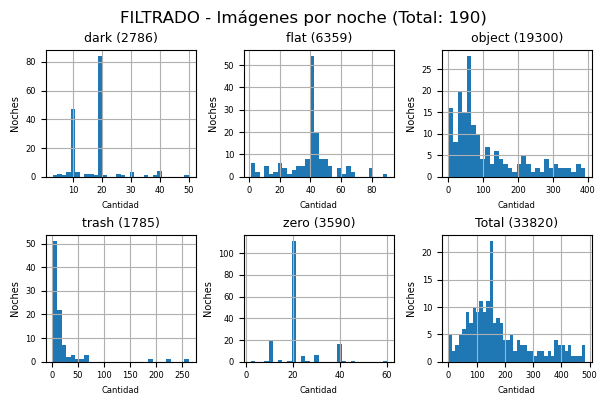

In [197]:
import matplotlib.pyplot as plt

imagetypes = sorted(df["imagetyp"].unique())
n = len(imagetypes)

fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()

for ax, imagetyp in zip(axes, imagetypes):
    df[df["imagetyp"] == imagetyp].groupby("night").size().hist(ax=ax, bins=30)
    tot = len(df[df["imagetyp"] == imagetyp])
    ax.set_title(f"{imagetyp} ({tot})", fontsize=9)
    ax.set_xlabel("Cantidad", fontsize=6)
    ax.set_ylabel("Noches", fontsize=7)
    
    ax.tick_params(axis='both', labelsize=6)
    
ax = axes[-1]
df.night.value_counts().hist(ax=ax, bins=40)
tot = len(df)
ax.set_title(f"Total ({tot})", fontsize=9)
ax.set_xlabel("Cantidad", fontsize=6)
ax.set_ylabel("Noches", fontsize=7)

ax.tick_params(axis='both', labelsize=6)

# Ajuste fino del espacio horizontal
plt.subplots_adjust(wspace=0.2)  # prueba valores más chicos: 0.1, 0.05
plt.suptitle(f"FILTRADO - Imágenes por noche (Total: {len(df.night.unique())})")
plt.tight_layout(pad=0.5)
plt.show()

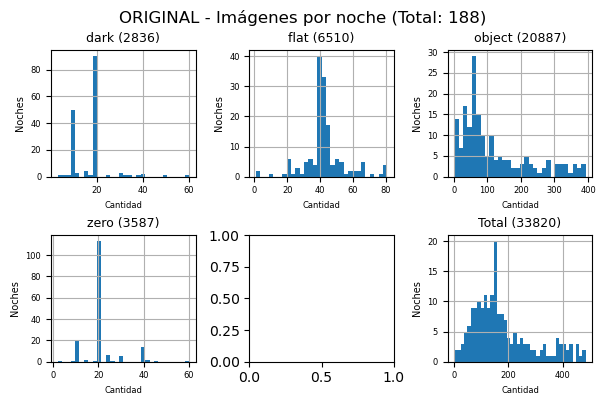

In [467]:
import matplotlib.pyplot as plt

imagetypes = sorted(df["imgtyp_old"].unique())
n = len(imagetypes)

fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()

for ax, imagetyp in zip(axes, imagetypes):
    df[df["imgtyp_old"] == imagetyp].groupby("night_old").size().hist(ax=ax, bins=30)
    tot = len(df[df["imgtyp_old"] == imagetyp])
    ax.set_title(f"{imagetyp} ({tot})", fontsize=9)
    ax.set_xlabel("Cantidad", fontsize=6)
    ax.set_ylabel("Noches", fontsize=7)
    
    ax.tick_params(axis='both', labelsize=6)
    
ax = axes[-1]
df.night_old.value_counts().hist(ax=ax, bins=40)
tot = len(df)
ax.set_title(f"Total ({tot})", fontsize=9)
ax.set_xlabel("Cantidad", fontsize=6)
ax.set_ylabel("Noches", fontsize=7)

ax.tick_params(axis='both', labelsize=6)

# Ajuste fino del espacio horizontal
plt.subplots_adjust(wspace=0.2)  # prueba valores más chicos: 0.1, 0.05
plt.suptitle(f"ORIGINAL - Imágenes por noche (Total: {len(df.night_old.unique())})")
plt.tight_layout(pad=0.5)
plt.show()

In [178]:
table = (
    df.groupby("imagetyp")
    .agg(
        N=("exptime", "count"),
        exp_min=("exptime", "min"),
        exp_median=("exptime", "median"),
        exp_mean=("exptime", "mean"),
        exp_max=("exptime", "max"),
        exp_std=("exptime", "std")
    )
    .round(2)
    .reset_index()
)

print(table.to_latex(index=False))
table

\begin{tabular}{lrrrrrr}
\toprule
imagetyp & N & exp_min & exp_median & exp_mean & exp_max & exp_std \\
\midrule
dark & 2786 & 60.000000 & 120.000000 & 167.070000 & 600.000000 & 97.080000 \\
flat & 6359 & 0.010000 & 0.300000 & 0.710000 & 5.000000 & 1.020000 \\
object & 19552 & 50.000000 & 90.000000 & 118.670000 & 600.000000 & 75.110000 \\
trash & 1533 & 0.150000 & 8.000000 & 27.260000 & 300.000000 & 51.130000 \\
zero & 3590 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}



,imagetyp,N,exp_min,exp_median,exp_mean,exp_max,exp_std
0,dark,2786,60.00,120.0,167.07,600.0,97.08
1,flat,6359,0.01,0.3,0.71,5.0,1.02
2,object,19552,50.00,90.0,118.67,600.0,75.11
3,trash,1533,0.15,8.0,27.26,300.0,51.13
4,zero,3590,0.00,0.0,0.00,0.0,0.00


In [179]:
table = (
    df.groupby("imgtyp_old")
    .agg(
        N=("exptime", "count"),
        exp_min=("exptime", "min"),
        exp_median=("exptime", "median"),
        exp_mean=("exptime", "mean"),
        exp_max=("exptime", "max"),
        exp_std=("exptime", "std")
    )
    .round(2)
    .reset_index()
)

print(table.to_latex(index=False))
table

\begin{tabular}{lrrrrrr}
\toprule
imgtyp_old & N & exp_min & exp_median & exp_mean & exp_max & exp_std \\
\midrule
dark & 2836 & 0.000000 & 120.000000 & 164.350000 & 600.000000 & 98.360000 \\
flat & 6510 & 0.010000 & 0.300000 & 2.460000 & 180.000000 & 10.610000 \\
object & 20887 & 0.100000 & 90.000000 & 112.490000 & 600.000000 & 77.560000 \\
zero & 3587 & 0.000000 & 0.000000 & 0.100000 & 180.000000 & 4.250000 \\
\bottomrule
\end{tabular}



,imgtyp_old,N,exp_min,exp_median,exp_mean,exp_max,exp_std
0,dark,2836,0.00,120.0,164.35,600.0,98.36
1,flat,6510,0.01,0.3,2.46,180.0,10.61
2,object,20887,0.10,90.0,112.49,600.0,77.56
3,zero,3587,0.00,0.0,0.10,180.0,4.25


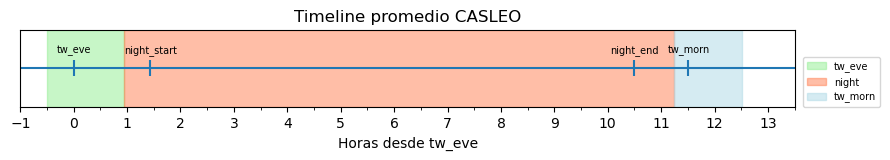

In [512]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Asegurar datetime
cols = ['tw_eve_dt', 'night_start_dt', 'night_end_dt', 'tw_morn_dt']
dfb = df_bit.dropna(subset=cols).copy()

# Convertir a segundos relativos a tw_eve
dfb['t0'] = dfb['tw_eve_dt']

for c in cols:
    dfb[c + '_rel'] = (dfb[c] - dfb['t0']).dt.total_seconds() / 3600.0  # horas

# Promedios
mean_offsets = {
    c: dfb[c + '_rel'].mean()
    for c in cols
}

# eje base (horas desde tw_eve)
t_tw_eve = 0
t_night_start = mean_offsets['night_start_dt']
t_night_end = mean_offsets['night_end_dt']
t_tw_morn = mean_offsets['tw_morn_dt']
# offsets en horas
m20 = 20/60
m30 = 30/60
m45 = 45/60
m60 = 60/60
'''

df['is_night'] = (
    (df['obs_dt'] >= df['night_start_dt'] - pd.Timedelta(minutes=30)) &
    (df['obs_dt'] <= df['night_end_dt'] + pd.Timedelta(minutes=45))
)
df['is_twilight'] = (

    ((df['obs_dt'] > df['tw_eve_dt'] -  pd.Timedelta(minutes=30)) &
     (df['obs_dt'] <= df['night_start_dt'] - pd.Timedelta(minutes=30))) |
    
    ((df['obs_dt'] >= df['night_end_dt'] + pd.Timedelta(minutes=45)) &
     (df['obs_dt'] <= df['tw_morn_dt'] + pd.Timedelta(minutes=60)))
)
'''

# NIGHT
night_start_eff = t_night_start - m30
night_end_eff   = t_night_end + m45

# TWILIGHT (dos bloques)
tw1_start = t_tw_eve - m30
tw1_end   = t_night_start - m30

tw2_start = t_night_end + m45
tw2_end   = t_tw_morn + m60

fig, ax = plt.subplots(figsize=(10, 1))

# Línea base
ax.hlines(0, -1, t_tw_morn + 2)

# Marcas principales
points = {
    "tw_eve": t_tw_eve,
    "night_start": t_night_start,
    "night_end": t_night_end,
    "tw_morn": t_tw_morn
}

for label, x in points.items():
    ax.vlines(x, -0.1, 0.1)
    ax.text(x, 0.2, label, ha='center', fontsize=7)

# Regiones
ax.axvspan(tw1_start, tw1_end, color="lightgreen", label = "tw_eve", alpha=0.5)   # twilight evening
ax.axvspan(night_start_eff, night_end_eff, color="coral", label="night", alpha=0.5)  # night
ax.axvspan(tw2_start, tw2_end, color="lightblue",label = "tw_morn", alpha=0.5)   # twilight morning
ax.legend(loc=(1.01, 0), fontsize=7)
# Labels
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.set_xlim(-1, t_tw_morn + 2)
ax.set_xlabel("Horas desde tw_eve")
ax.set_title("Timeline promedio CASLEO")
from matplotlib.ticker import MultipleLocator
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
plt.show()

In [242]:
df["check_status"].value_counts()

check_status
OK                                                                32014
trash: flat in non-twilight time or short and non night object      732
trash: flats with large exposure                                    602
trash: object without close match                                   450
OK: not in night object, but close                                   21
trash: object in non-observable hours                                 1
Name: count, dtype: int64

In [532]:
fn = df.groupby(["night", "imagetyp"]).size()
flats_per_night = (
    fn.xs("flat", level="imagetyp")  # seleccionar flats
)
all_nights = df["night"].unique()

flats_per_night = flats_per_night.reindex(all_nights, fill_value=0)
nights_wo_flats = flats_per_night[flats_per_night==0]
nights_w_flats = flats_per_night[flats_per_night!=0]
n_wo = len(nights_wo_flats)
n_w = len(nights_w_flats)
mean_w = nights_w_flats.mean()

print(f"Noches sin flats: {n_wo}")
print(f"Noches con flats: {n_w}")
print(f"Promedio de flats por noche (solo noches con flats): {mean_w:.2f}")

flats_per_night = flats_per_night.reindex(all_nights, fill_value=0)
nights_wo_flats = flats_per_night[flats_per_night<20]
nights_w_flats = flats_per_night[flats_per_night>=20]
n_wo = len(nights_wo_flats)
n_w = len(nights_w_flats)
mean_w = nights_w_flats.mean()
print("menos de 20 flats")
print(f"Noches sin flats: {n_wo}")
print(f"Noches con flats: {n_w}")
print(f"Promedio de flats por noche (solo noches con flats): {mean_w:.2f}")


Noches sin flats: 30
Noches con flats: 160
Promedio de flats por noche (solo noches con flats): 39.74
menos de 20 flats
Noches sin flats: 47
Noches con flats: 143
Promedio de flats por noche (solo noches con flats): 43.48


In [118]:
total_nights = len(df.night.unique())
df.groupby(["imagetyp", "wheel"]).size().unstack(fill_value=0).reset_index()

wheel,imagetyp,(1) Free,(2) B,(3) V,(4) R,(5) I
0,dark,60,19,1379,0,1328
1,flat,75,112,2995,145,3032
2,object,6,0,7505,1,12040
3,trash,75,0,647,11,800
4,zero,78,59,1438,20,1995


#### Flats analysis

Text(0.5, 1.0, 'Distribución de exptime por noche (stacked)')

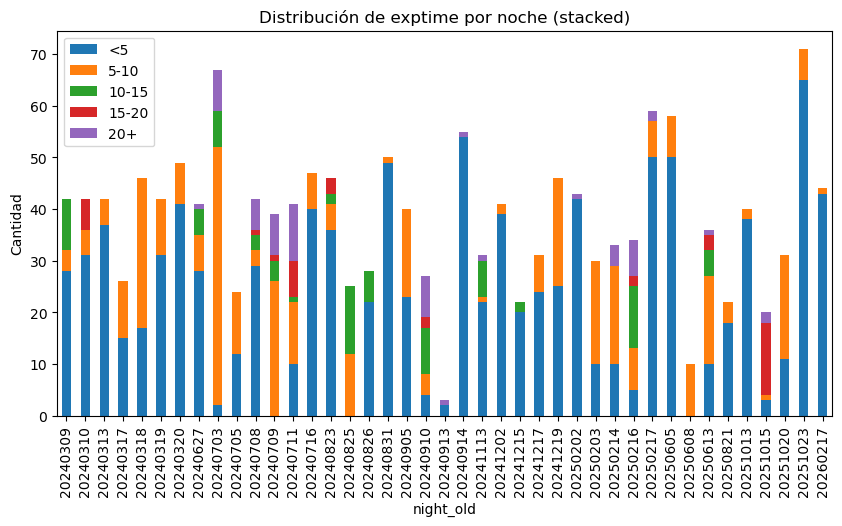

In [445]:
f = (
    df[(df["imagetyp"] == "flat")&(df["wheel"].isin(["(3) V", "(5) I"]))]
    .groupby("night_old")["exptime"]
    .agg(
        ok = lambda x: (x <= 5).sum(),
        f5  = lambda x: (x > 5).sum(),
        f10 = lambda x: (x > 10).sum(),
        f15 = lambda x: (x > 15).sum(),
        f20 = lambda x: (x > 20).sum(),
        max = lambda x: x.max()
    )
)

f = f.loc[ f[["f5", "f10", "f15", "f20"]].sum(axis=1) > 0 ]
stacked = f.copy()
stacked["<5"] = stacked["ok"]
stacked["5-10"]  = stacked["f5"]  - stacked["f10"]
stacked["10-15"] = stacked["f10"] - stacked["f15"]
stacked["15-20"] = stacked["f15"] - stacked["f20"]
stacked["20+"]   = stacked["f20"]

stacked = stacked[["<5", "5-10", "10-15", "15-20", "20+"]]
ax = stacked.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

ax.set_xlabel("night_old")
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de exptime por noche (stacked)")

In [418]:
f[f.ok<20]

,ok,f5,f10,f15,f20,max
night_old,,,,,,
20240317,15,11,0,0,0,8.0
20240318,17,29,0,0,0,10.0
20240703,2,65,15,8,8,35.0
20240705,12,12,0,0,0,6.0
20240709,0,39,13,9,8,50.0
20240711,10,31,19,18,11,60.0
20240825,0,25,13,0,0,15.0
20240910,4,23,19,10,8,35.0
20240913,2,1,1,1,1,120.0


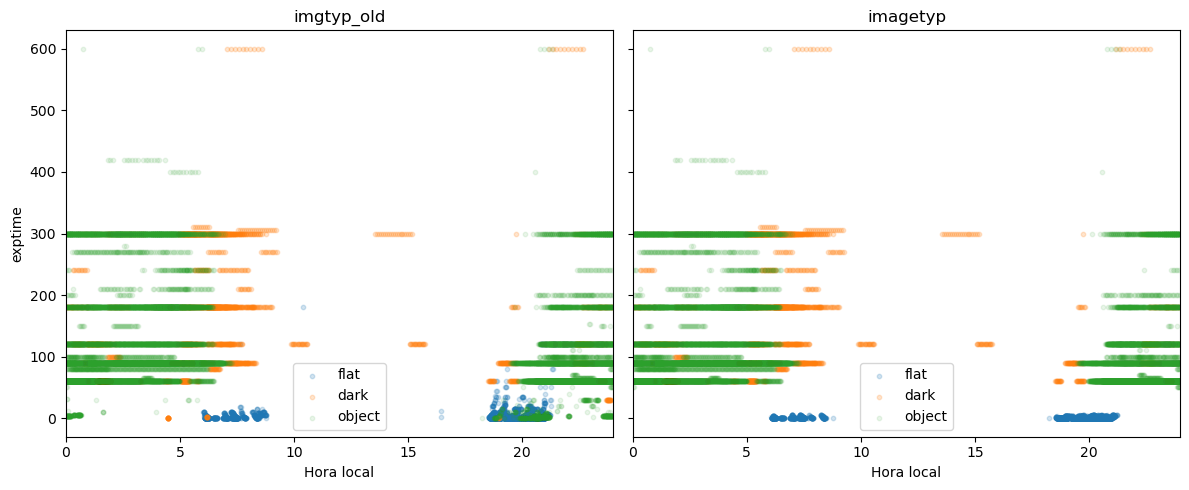

In [132]:
fig, axs = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for ax, col in zip(axs, ["imgtyp_old", "imagetyp"]):
    
    for typ, alpha in zip(["flat", "dark", "object"], [0.2, 0.2, 0.1]):
        d = df[(df[col] == typ) & (df["wheel"].isin(["(3) V", "(5) I"]))].copy()
        
        d["hour"] = d["time-local"].apply(lambda t: t.hour + t.minute/60 + t.second/3600)
        
        ax.scatter(d["hour"], d["exptime"], s=10, alpha=alpha, label=typ)
    
    ax.set_xlabel("Hora local")
    ax.set_xlim(0, 24)
    ax.set_title(col)
    ax.legend()

axs[0].set_ylabel("exptime")

plt.tight_layout()

In [133]:
count = (
    df.groupby(["imagetyp", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
count

wheel,(1) Free,(2) B,(3) V,(4) R,(5) I
imagetyp,,,,,
dark,60,19,1379,0,1328
flat,75,112,2995,145,3032
object,6,0,7505,1,12040
trash,75,0,647,11,800
zero,78,59,1438,20,1995


In [167]:
count = (
      df[df["object"].str.contains("0034")&~df["object"].isna()&(df["imagetyp"]=="object")]
      .groupby(["night", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
count

wheel,(3) V,(5) I
night,,
2024-03-14,3,3
2024-03-19,7,7
2025-06-03,50,46
2025-06-05,39,36
2025-06-07,0,22
2025-06-08,16,28
2025-06-14,10,9
2025-06-16,15,14
2025-06-18,32,30


In [166]:
df[df["object"].str.contains("0034")&(df["night"]=="2025-06-16")][["file", "exptime", "file_old"]]

,file,exptime,file_old
26632,OGLE-2024-BLG-0034_v0015.fit,120,OGLE-2024-BLG-0034v0002.fit
26633,OGLE-2024-BLG-0034_v0016.fit,120,OGLE-2024-BLG-0034v0003.fit
26631,OGLE-2024-BLG-0034_v0014.fit,120,OGLE-2024-BLG-0034v0001.fit
26634,OGLE-2024-BLG-0034_v0017.fit,120,OGLE-2024-BLG-0034v0004.fit
26619,trash_OGLE-2024-BLG-0034i0189.fit,4,OGLE-2024-BLG-0034i0189.fit
...,...,...,...
26489,trash_OGLE-2024-BLG-0034i0059.fit,4,OGLE-2024-BLG-0034i0059.fit
26494,trash_OGLE-2024-BLG-0034i0064.fit,4,OGLE-2024-BLG-0034i0064.fit
26495,trash_OGLE-2024-BLG-0034i0065.fit,4,OGLE-2024-BLG-0034i0065.fit
26496,trash_OGLE-2024-BLG-0034i0066.fit,4,OGLE-2024-BLG-0034i0066.fit


In [ ]:
sky_cols = ['ra2000', 'dec2000', 'ra', 'dec']
detector_cols = [
    "gain", "rdnoise", "camtem", "detector", "adcrate"
]
datetime_cols = [
    "date", "date-obs", "time-obs", "ut", "mjd-obs", "st"
]
pointing_cols = [
    "ra", "dec", "ra2000", "dec2000", "equinox",
    "ha", "zd", "airmass"
]
telescope_cols = [
    "observat", "telescop", "dome-az", "optele"
]
obs_set_cols = [ "filter", "filter1", "filter01", "filter02",
    "imagetyp", "exptime", 
]
#filter_cols = [ "filter", "filter1", "filter01", "filter02"]
filter_cols = ["wheel", "wheel_aux"]
for col in obs_set_cols:
    print(df[col].value_counts())

filter
(5) I       12148
(3) V        8344
(1) Free      116
(4) R         116
(2) B          99
Name: count, dtype: int64
filter1
(6) Free       20811
(4) H-Alpha       10
(5) ND213B         2
Name: count, dtype: int64
filter01
(5) I       7287
(3) V       5818
(1) Free     180
(2) B         91
(4) R         61
Name: count, dtype: int64
filter02
(6) Free       12298
(2) Blind        865
(3) Blind        193
(5) ND213B        41
(4) H-Alpha       20
(1) U             20
Name: count, dtype: int64
imagetyp
object    20628
flat       7167
zero       3609
dark       2856
Name: count, dtype: int64
exptime
60.00     7059
90.00     5883
0.00      3612
120.00    3060
180.00    2760
          ... 
45.00        1
0.23         1
3.80         1
61.00        1
11.00        1
Name: count, Length: 112, dtype: int64


In [149]:
import os
os.listdir()

['season_nights_without_science.csv',
 'actions_copy_calib_images.csv',
 'rename_commands.sh',
 'analyze_image_collection.ipynb',
 'image_classification_criteria.csv',
 'season_HSH-2024A-03_band_V.png',
 'non_season_nights_with_science.csv',
 'nights_images_count.csv',
 'image_collection_clean.csv',
 'season_HSH-2024B-05_band_V.png',
 'season_HSH-2025B-03_band_I.png',
 'season_HSH-2025A-05_band_V.png',
 'season_2026A_band_I.png',
 'season_HSH-2025A-05_band_I.png',
 'image_collection_original.csv',
 'bitacora_CASLEO.csv',
 'season_HSH-2024B-05_band_I.png',
 'move_commands.sh',
 'season_2026A_band_V.png',
 'season_HSH-2025B-03_band_V.png',
 'hsh_seasons_calendar.csv',
 'season_HSH-2024A-03_band_I.png']

#### Sky map

-72.81730555555555 21.513833333333334
0.02333333333333333 359.64833333333326


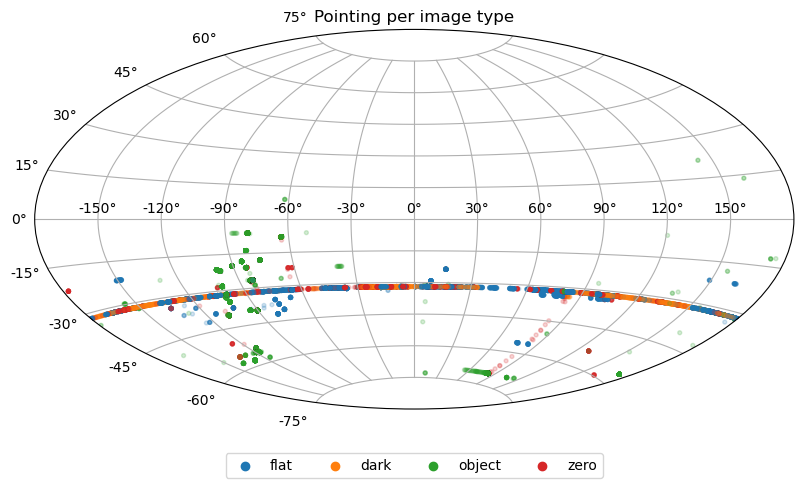

In [150]:
from astropy.coordinates import SkyCoord
import astropy.units as u


coords = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

print(coords.dec.deg.min(), coords.dec.deg.max())  # debería estar entre ~-90 y +60
print(coords.ra.deg.min(), coords.ra.deg.max())    # RA entre 0 y 360°

import matplotlib.pyplot as plt
import numpy as np

# Obtener categorías únicas
types = df['imagetyp'].unique()

# Definir un colormap discreto
cmap = plt.get_cmap('tab10')  # bueno para <=10 categorías
colors = {t: cmap(i) for i, t in enumerate(types)}

# Crear array de colores alineado con los puntos
point_colors = df['imagetyp'].map(colors)

# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

sc = ax.scatter(ra_rad, dec_rad, 
                c=point_colors,
                alpha=0.2, 
                s=8)

ax.grid(True)
ax.set_title("Pointing per image type")
ax.invert_xaxis()

# Crear leyenda manual
for t in types:
    ax.scatter([], [], c=[colors[t]], label=t)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
          ncol=min(len(types), 4))

plt.tight_layout()
plt.show()

-70.14630555555556 -6.077166666666667
78.22208333333332 297.01041666666663


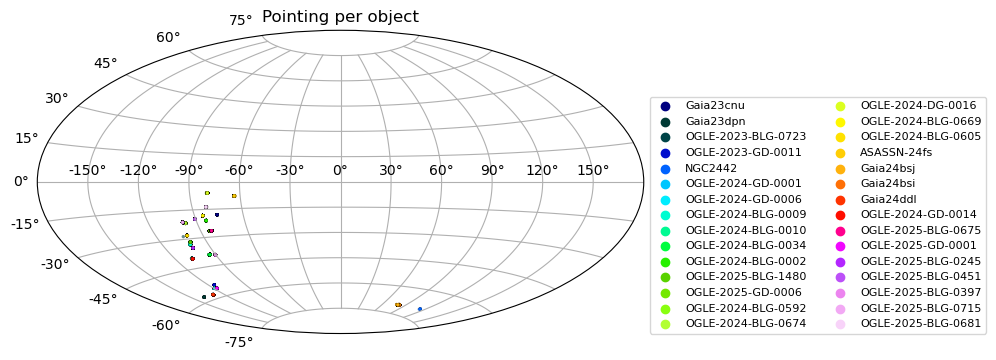

In [44]:
from astropy.coordinates import SkyCoord
import astropy.units as u


df_object = df[df["imagetyp"] == "object"]
df_object = df_object[df_object['object'] != "NO_OBJECT"].copy()
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

print(coords.dec.deg.min(), coords.dec.deg.max())  # debería estar entre ~-90 y +60
print(coords.ra.deg.min(), coords.ra.deg.max())    # RA entre 0 y 360°

import matplotlib.pyplot as plt
import numpy as np

# Obtener categorías únicas
types = df_object['object'].unique()


#cmap = plt.get_cmap('tab10')
#colors = {t: cmap(i) for i, t in enumerate(types)}
#point_colors = df_object['object'].map(colors)

N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = df_object['object'].map(colors)


# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

sc = ax.scatter(ra_rad, dec_rad, 
                marker=".",
                c=point_colors,
                alpha=0.6, 
                edgecolor="black",
                linewidths=0.1,
                s=20)

ax.grid(True)
ax.set_title("Pointing per object")
ax.invert_xaxis()

# Crear leyenda manual
for t in types:
    ax.scatter([], [], c=[colors[t]], label=t)

ax.legend(loc=(1.01,0), ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

Dec min/max hemisferio sur: -70.14630555555556 -6.077166666666667
RA min/max hemisferio sur: 78.22208333333332 297.01041666666663


/tmp/ipykernel_59583/1395061380.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


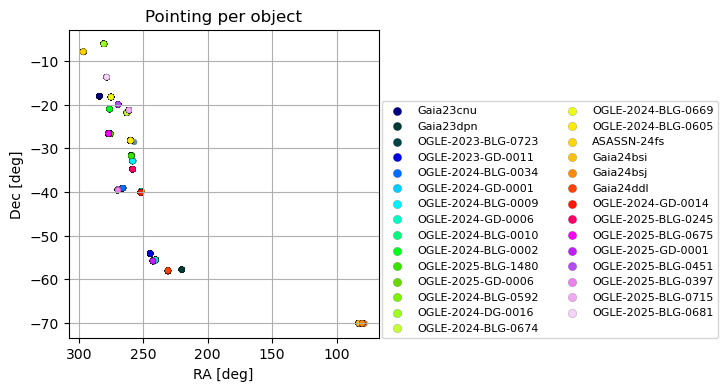

In [156]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# Filtrar objetos válidos
df_object = df[df["imagetyp"] == "object"].copy()
df_object = df_object[df_object['object'] != "NO_OBJECT"]

# Coordenadas
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))

# Solo hemisferio sur
mask_south = coords.dec.deg <= 0
ra_south = coords.ra.deg[mask_south]
dec_south = coords.dec.deg[mask_south]
objects_south = df_object['object'][mask_south]

print("Dec min/max hemisferio sur:", dec_south.min(), dec_south.max())
print("RA min/max hemisferio sur:", ra_south.min(), ra_south.max())

# Colores
types = objects_south.unique()
N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = objects_south.map(colors)

# Plot cartesiano
fig, ax = plt.subplots(figsize=(4,4))
sc = ax.scatter(
    ra_south, dec_south,
    c=point_colors,
    edgecolor="black",
    linewidths=0.1,
    alpha=0.6,
    s=18,
    #marker="."
)

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Pointing per object")
ax.invert_xaxis()  # opcional: RA decreciente
ax.grid(True)

# Leyenda
for t in types:
    ax.scatter([], [], c=[colors[t]], edgecolor="black", linewidths=0.1, label=t)
ax.legend(loc=(1.01,0), fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


/tmp/ipykernel_12173/1776295315.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_object = df_object[(df["object"].str.startswith("Gaia"))|(df["object"].str.startswith("OGLE"))


Dec min/max hemisferio sur: -70.14630555555556 -6.077166666666667
RA min/max hemisferio sur: 79.48499999999999 296.6395833333333


/tmp/ipykernel_12173/1776295315.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


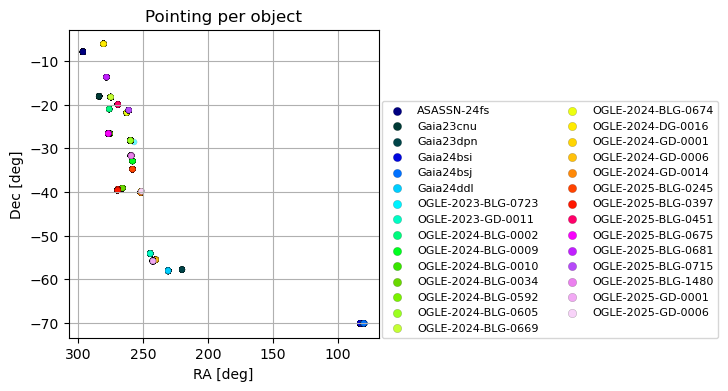

In [248]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# Filtrar objetos válidos
df_object = df[df["imagetyp"] == "object"].copy()
df_object = df_object[(df["object"].str.startswith("Gaia"))|(df["object"].str.startswith("OGLE"))
                      |(df["object"].str.startswith("ASASSN"))].sort_values("object")

# Coordenadas
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))

# Solo hemisferio sur
mask_south = coords.dec.deg <= 0
ra_south = coords.ra.deg[mask_south]
dec_south = coords.dec.deg[mask_south]
objects_south = df_object['object'][mask_south]

print("Dec min/max hemisferio sur:", dec_south.min(), dec_south.max())
print("RA min/max hemisferio sur:", ra_south.min(), ra_south.max())

# Colores
types = objects_south.unique()
N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = objects_south.map(colors)

# Plot cartesiano
fig, ax = plt.subplots(figsize=(4,4))
sc = ax.scatter(
    ra_south, dec_south,
    c=point_colors,
    edgecolor="black",
    linewidths=0.1,
    alpha=0.6,
    s=18,
    #marker="."
)

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Pointing per object")
ax.invert_xaxis()  # opcional: RA decreciente
ax.grid(True)

# Leyenda
for t in types:
    ax.scatter([], [], c=[colors[t]], edgecolor="black", linewidths=0.1, label=t)
ax.legend(loc=(1.01,0), fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


### Metadata

In [ ]:
import os
import json
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u


data_dir = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/microlensing_data"
csv_file = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"

df_csv = pd.read_csv(csv_file)
objetos_existentes = {obj: idx for idx, obj in enumerate(df_csv['objeto'])}
for fname in os.listdir(data_dir):
    if fname.endswith(".json"):
        path = os.path.join(data_dir, fname)
        with open(path, "r") as f:
            data = json.load(f)
        objeto = fname.split("_")[0]   
        ra_str = data["RA"]
        dec_str = data["Dec"]
        coord = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg))
        ra_deg = coord.ra.deg
        dec_deg = coord.dec.deg
        if objeto not in objetos_existentes:
            # Agregar objeto nuevo
            df_csv = pd.concat([
                df_csv,
                pd.DataFrame({
                    "objeto": [objeto],
                    "ra_deg": [ra_deg],
                    "dec_deg": [dec_deg],
                    "ra_ecu": [ra_str],
                    "dec_ecu": [dec_str]
                })
            ], ignore_index=True)

df_csv.to_csv(csv_file, index=False)
print("objetos.csv actualizado con todos los targets de microlensing_data")


objetos.csv actualizado con todos los targets de microlensing_data


#### Seasons file

In [612]:
import pandas as pd
from datetime import datetime
# CREAR DATASETSS
rows = []

def add_range(season, start, end, program="HSH"):
    dates = pd.date_range(start, end, freq="D")
    for d in dates:
        rows.append({
            "season": season,
            "date": d,
            "program": program
        })

# =========================
# HSH-2024A-03 (40 noches)
# =========================
add_range("HSH-2024A-03", "2024-03-01", "2024-03-20")
add_range("HSH-2024A-03", "2024-06-27", "2024-07-16")

# =========================
# HSH-2024B-05 (60 noches)
# =========================
add_range("HSH-2024B-05", "2024-08-23", "2024-09-12")
add_range("HSH-2024B-05", "2024-11-02", "2024-11-06")
add_range("HSH-2024B-05", "2024-11-10", "2024-11-13")
add_range("HSH-2024B-05", "2024-11-17", "2024-11-25")
add_range("HSH-2024B-05", "2024-11-30", "2024-12-11")
add_range("HSH-2024B-05", "2024-12-15", "2024-12-23")  # incluyendo dic/23 observado

# =========================
# HSH-2025A-05 (40 noches)
# =========================
add_range("HSH-2025A-05", "2025-02-01", "2025-02-12")
add_range("HSH-2025A-05", "2025-02-14", "2025-02-20")
add_range("HSH-2025A-05", "2025-06-01", "2025-06-21")

# =========================
# HSH-2025B-03  (56 noches)
# =========================
add_range("HSH-2025B-03", "2025-08-20", "2025-08-27")
add_range("HSH-2025B-03", "2025-09-15", "2025-09-30")
add_range("HSH-2025B-03", "2025-10-13", "2025-10-24")
add_range("HSH-2025B-03", "2025-10-26", "2025-10-30")
add_range("HSH-2025B-03", "2025-11-18", "2025-11-22")
add_range("HSH-2025B-03", "2025-12-17", "2025-12-21")
add_range("HSH-2025B-03", "2026-01-12", "2026-01-16")

# =========================
# HSH-2025B-03 en 2026A
# =========================
add_range("2026A", "2026-02-09", "2026-02-17", program="HSH")
add_range("2026A", "2026-02-24", "2026-02-28", program="HSH")

add_range("2026A", "2026-07-08", "2026-07-09", program="HSH")
add_range("2026A", "2026-07-10", "2026-07-10", program="HSH")
add_range("2026A", "2026-07-11", "2026-07-12", program="HSH")
add_range("2026A", "2026-07-13", "2026-07-13", program="HSH")
add_range("2026A", "2026-07-14", "2026-07-16", program="HSH")
add_range("2026A", "2026-07-17", "2026-07-17", program="HSH")
add_range("2026A", "2026-07-18", "2026-07-21", program="HSH")
# Crear DataFrame
seasons_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

# Guardar CSV
seasons_df.to_csv("hsh_seasons_calendar.csv", index=False)

print(seasons_df.season.value_counts())
print("Total noches:", len(seasons_df))


season
HSH-2024B-05    60
HSH-2025B-03    56
HSH-2024A-03    40
HSH-2025A-05    40
2026A           28
Name: count, dtype: int64
Total noches: 224


In [ ]:
import pandas as pd
# AGREGAR NUEVAS SEASONS
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# 2️⃣ Crear lista temporal para nuevos rangos
new_rows = []

def add_range(season, start, end, program="HSH"):
    dates = pd.date_range(start, end, freq="D")
    for d in dates:
        new_rows.append({
            "season": season,
            "date": d,
            "program": program
        })

# add_range("HSH-2025B-03", "2026-02-09", "2026-02-17", program="HSH-PLP")

new_df = pd.DataFrame(new_rows)
seasons_df = (
    pd.concat([seasons_df, new_df])
      .drop_duplicates(subset=["season", "date", "program"])
      .sort_values("date")
      .reset_index(drop=True)
)

# 5️⃣ Guardar nuevamente
seasons_df.to_csv("hsh_seasons_calendar.csv", index=False)

print("Total noches actualizado:", len(seasons_df))

Total noches actualizado: 224


### Todas las observaciones

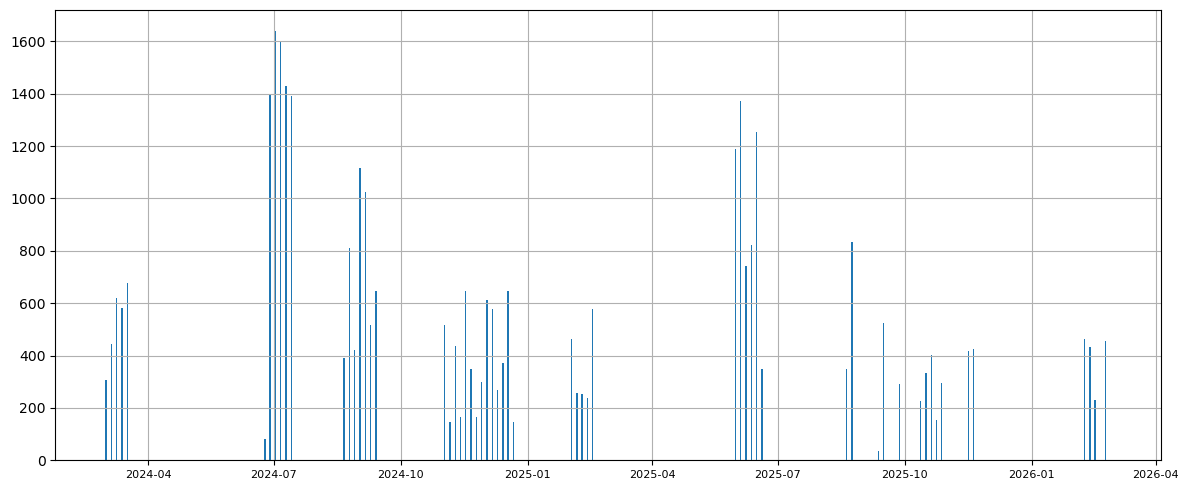

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
plt.figure(figsize=(12,5))
df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")
ax = df["night"].hist(bins=len(df["night"].value_counts().keys()), width=1)
#ax1 = ax.twinx()
#ax1.plot(df["night"], df["airmass"], "rs", markersize=1)

ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()


Plotting season: HSH-2024A-03


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


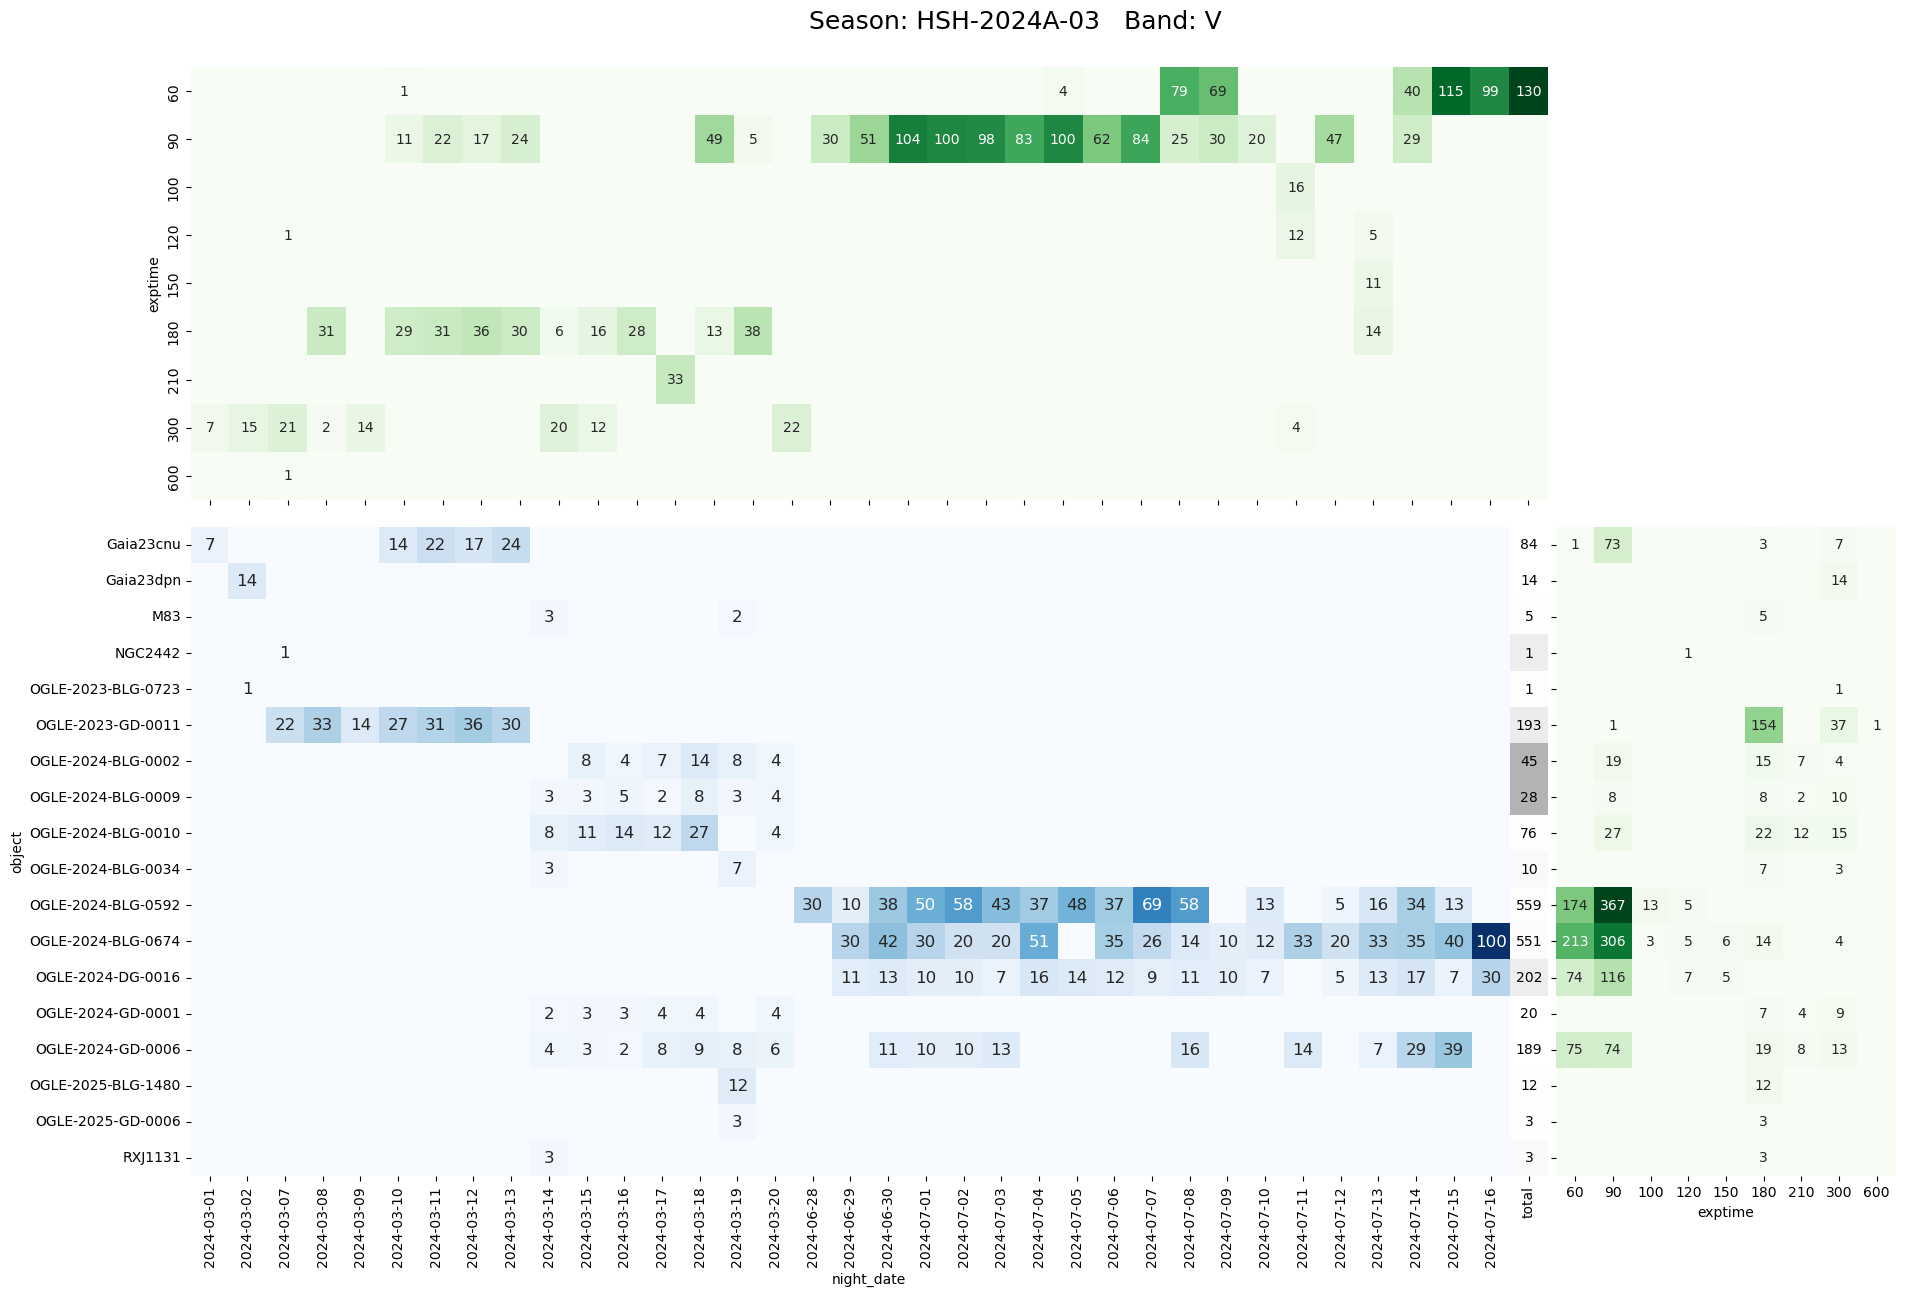

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


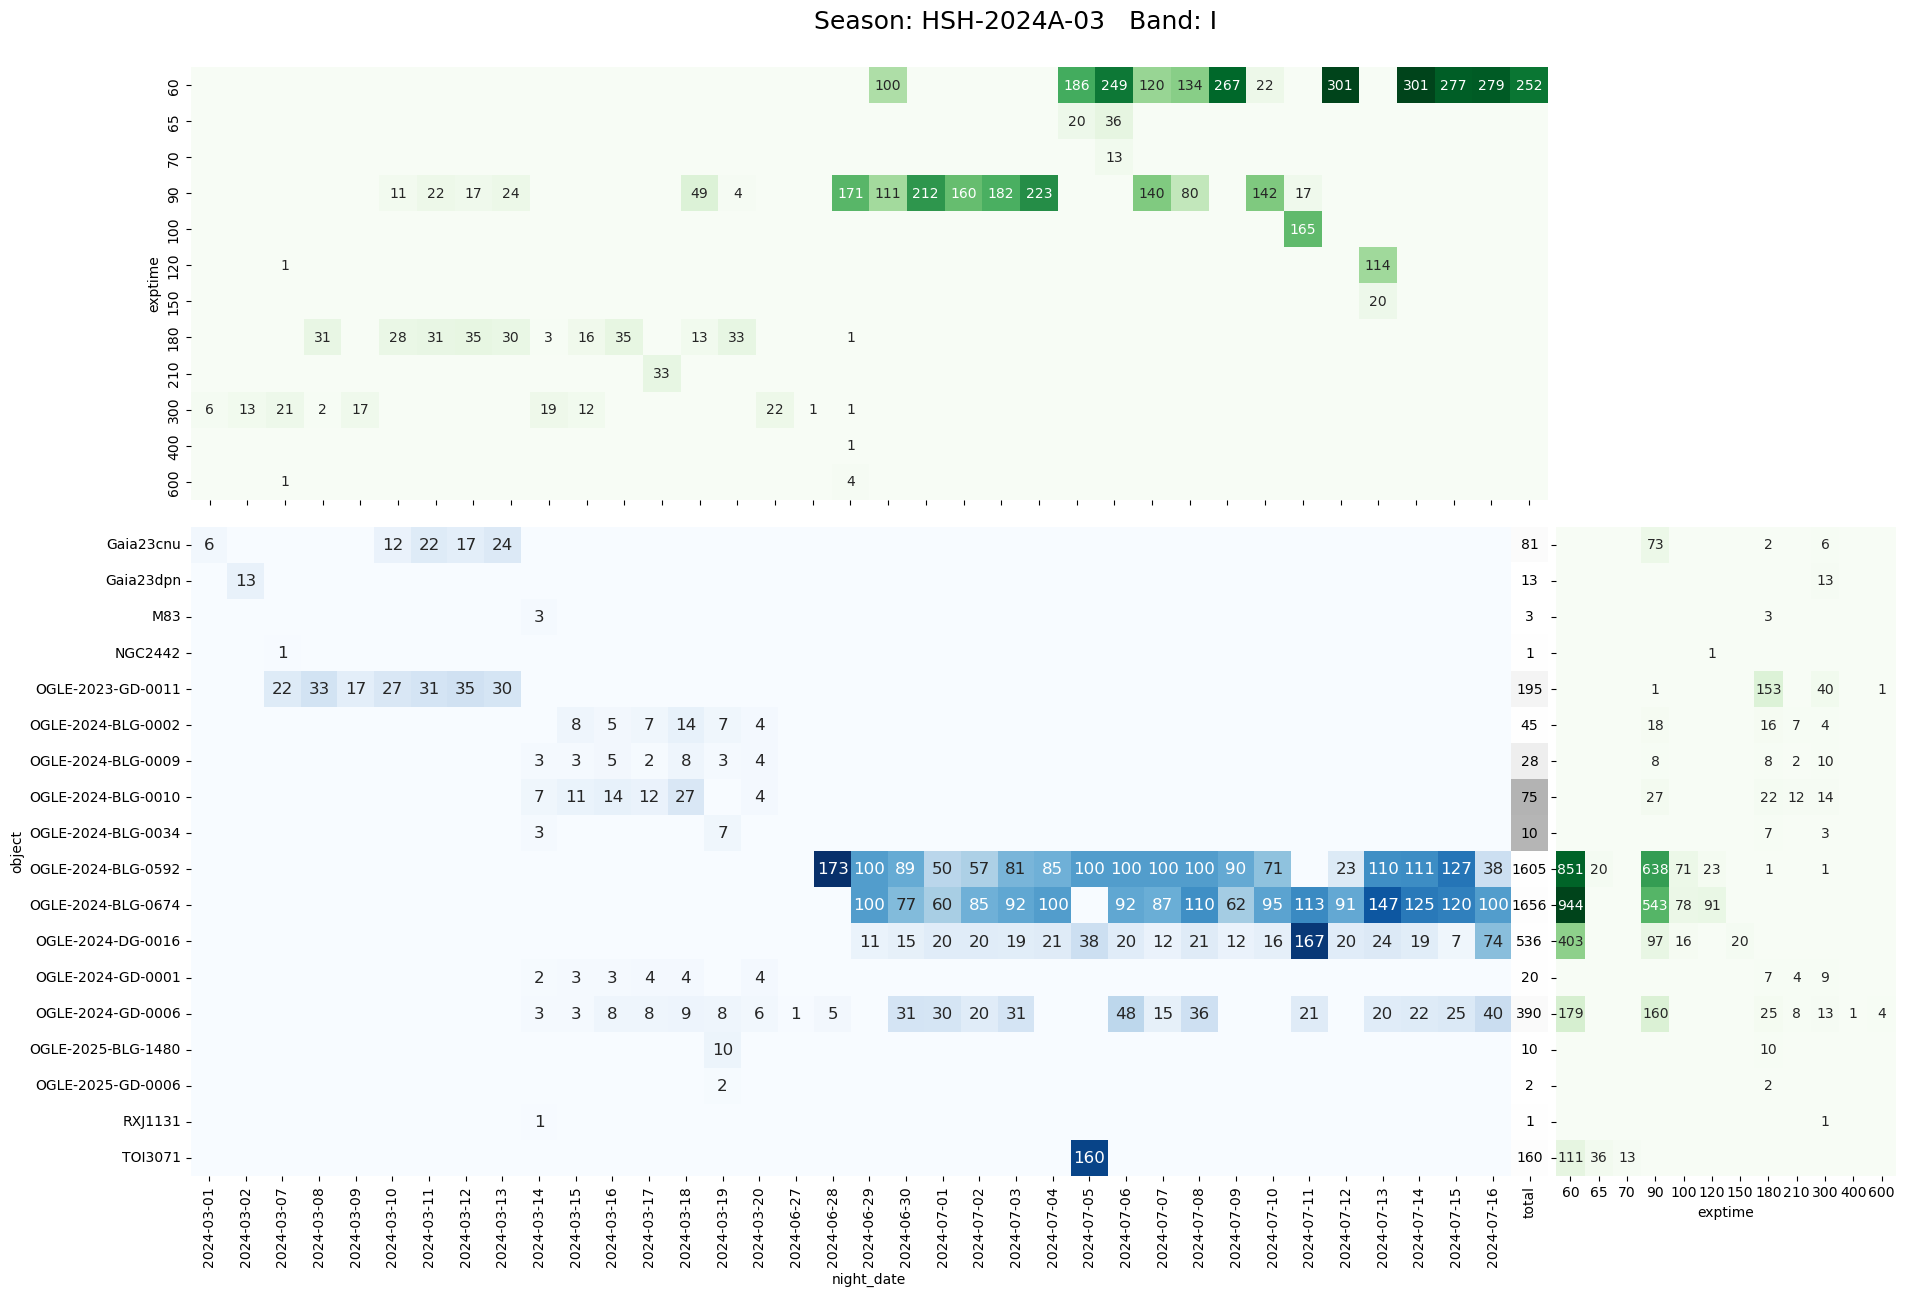

Plotting season: HSH-2024B-05


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


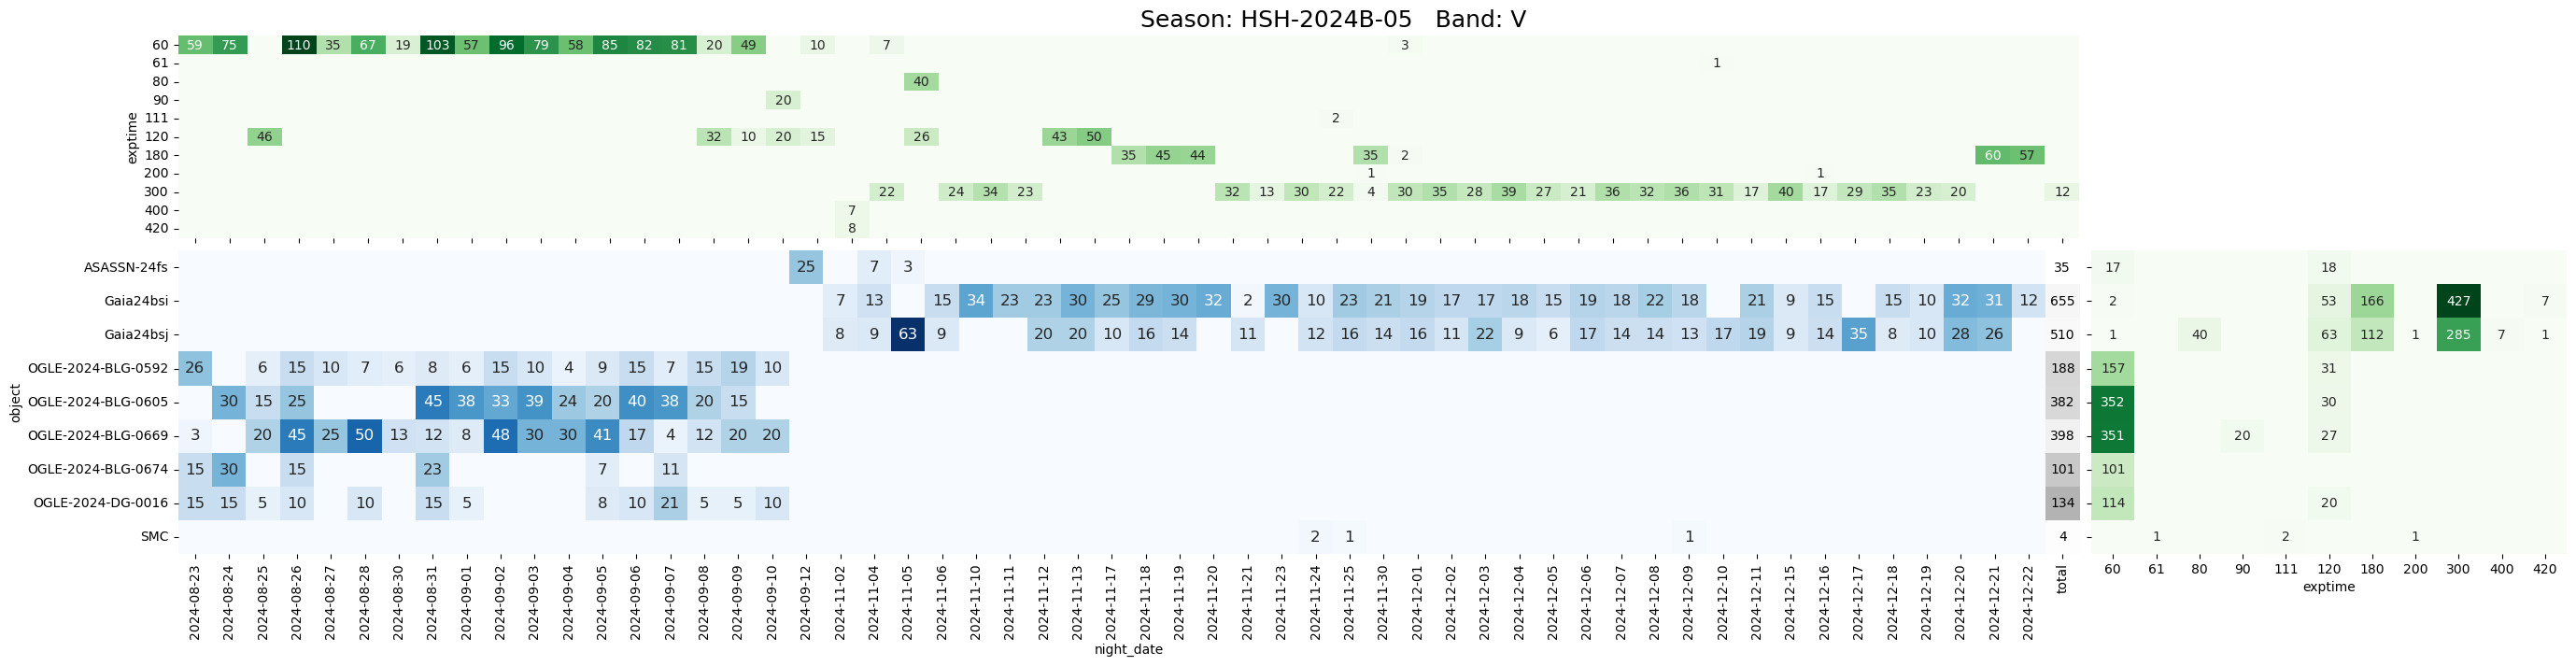

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


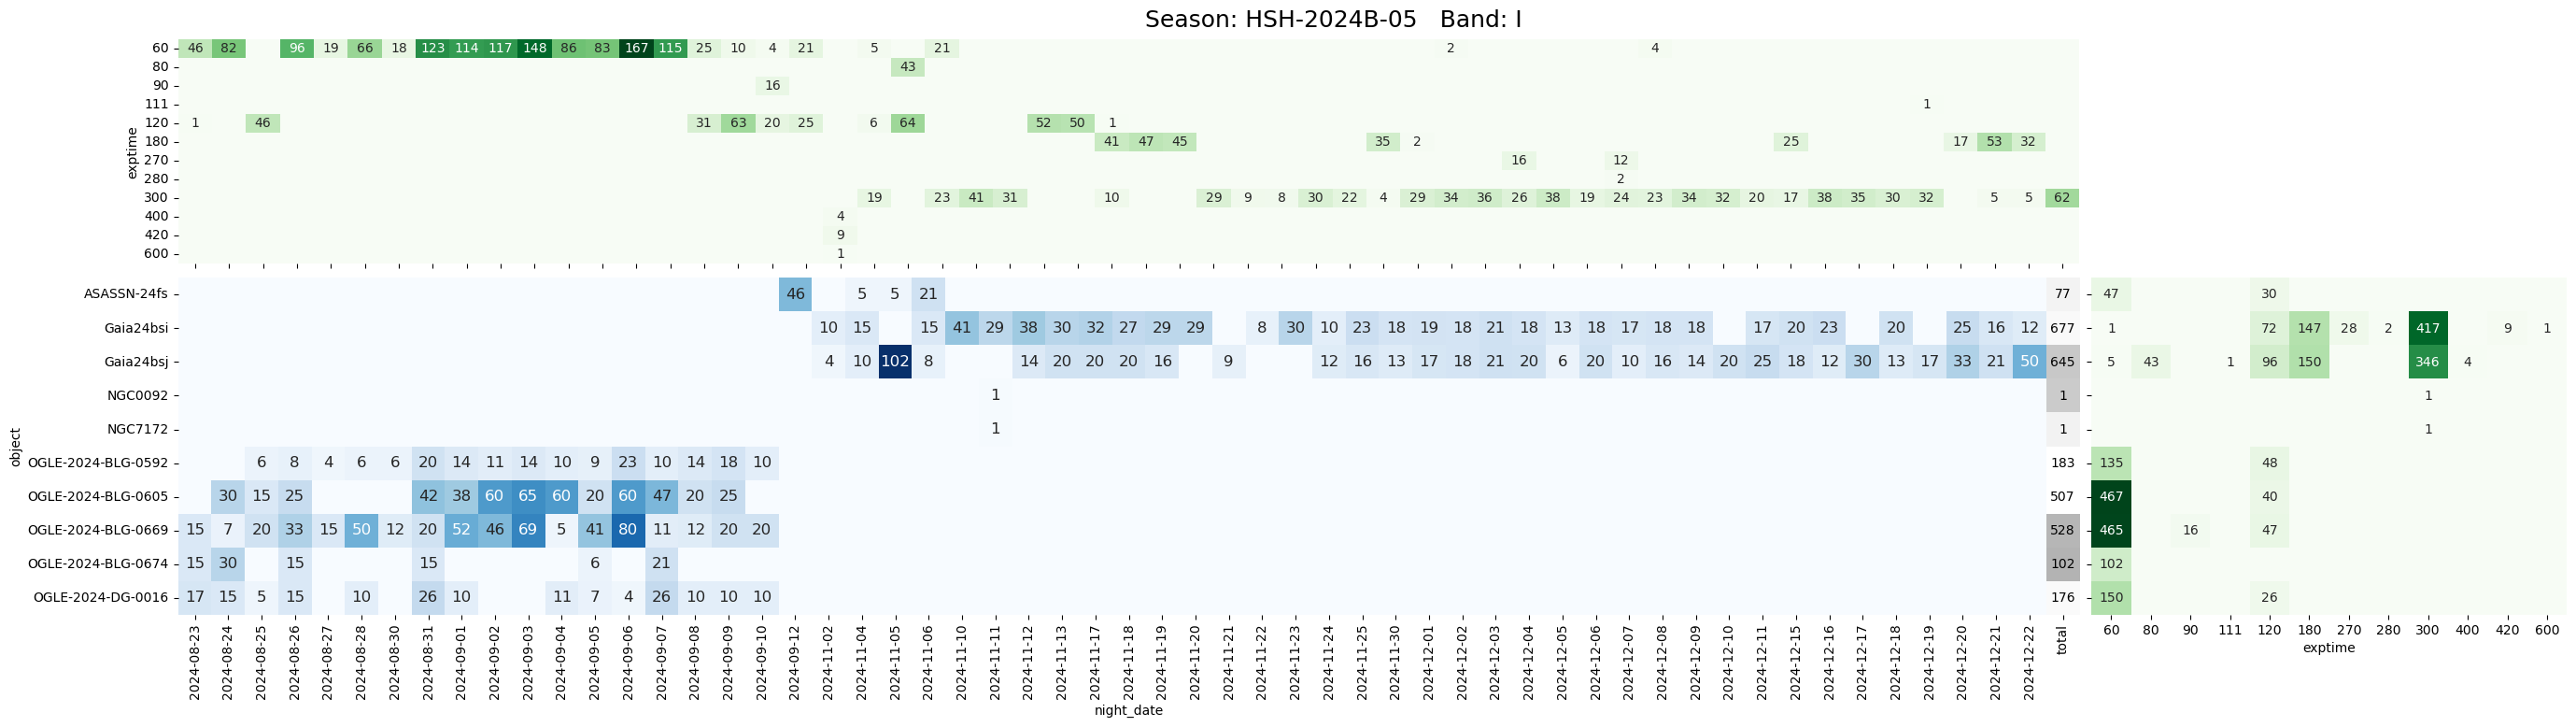

Plotting season: HSH-2025A-05


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


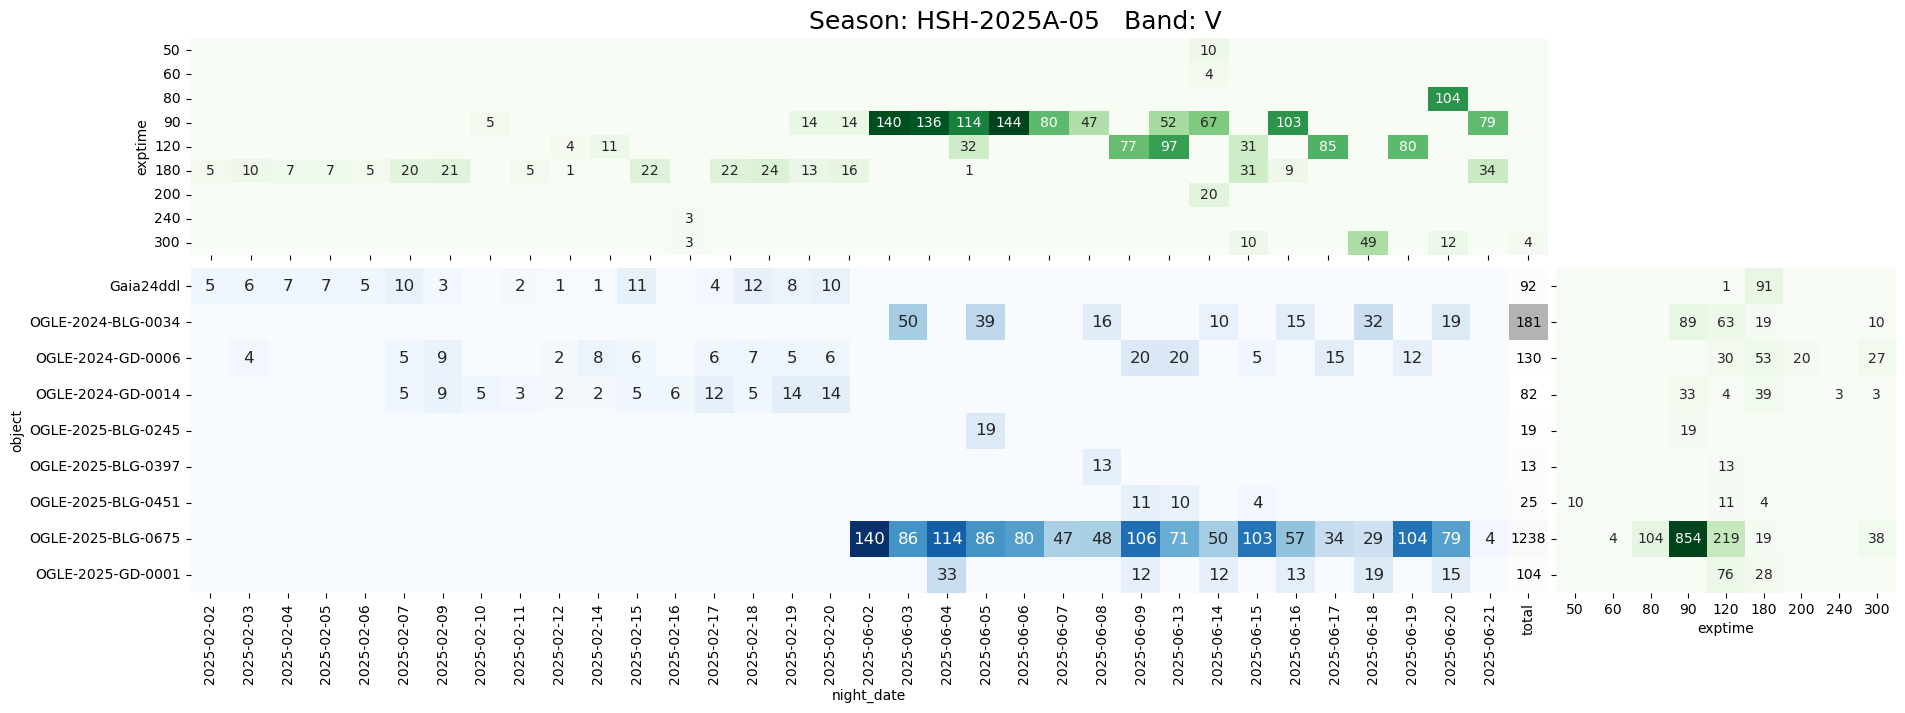

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


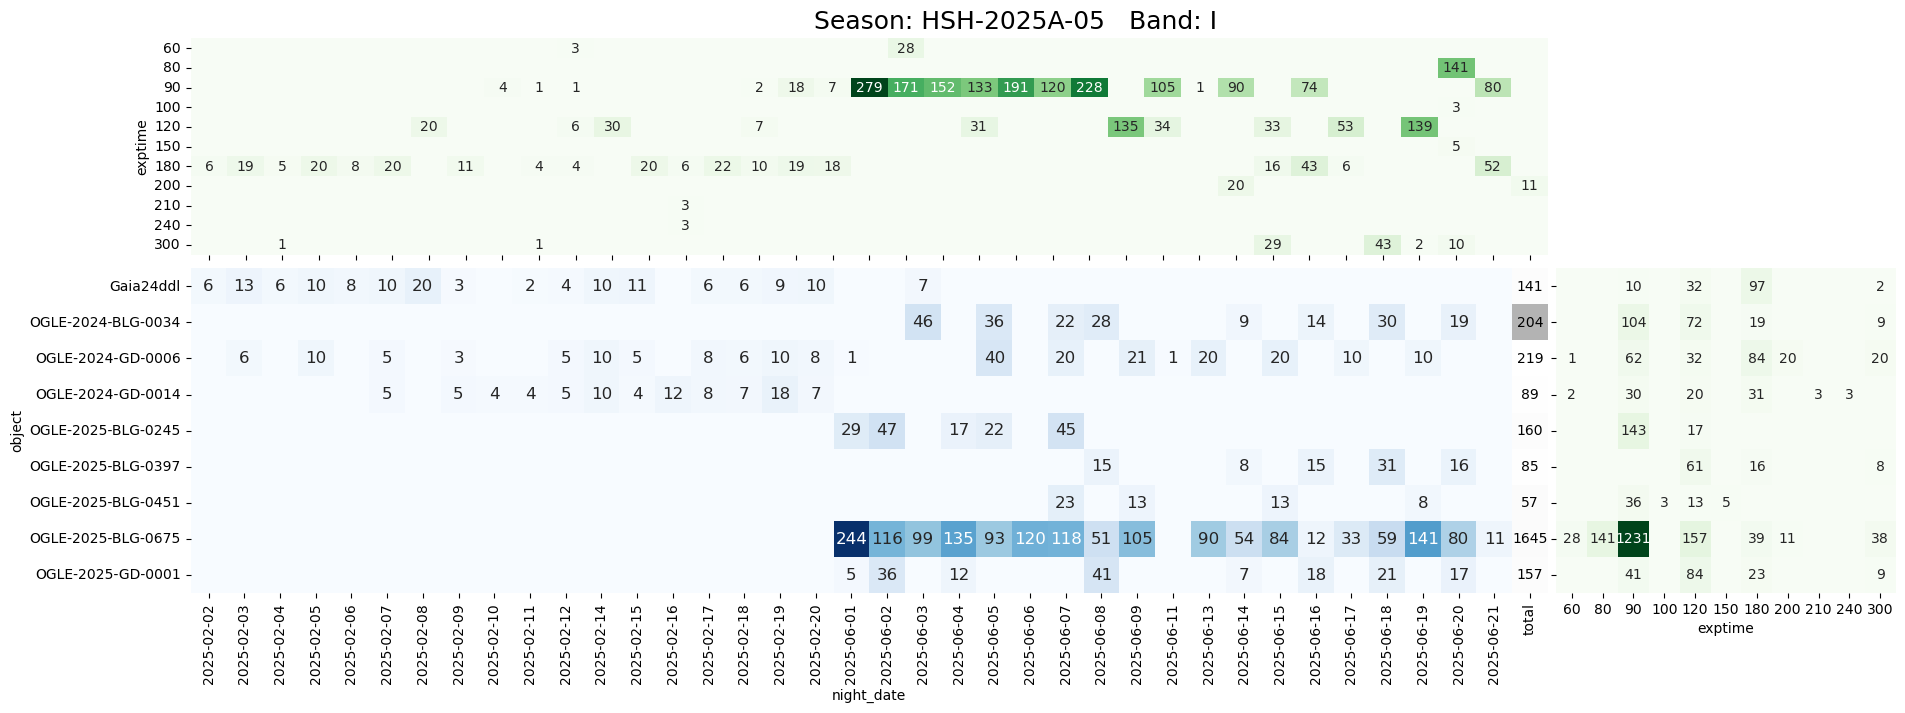

Plotting season: HSH-2025B-03


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


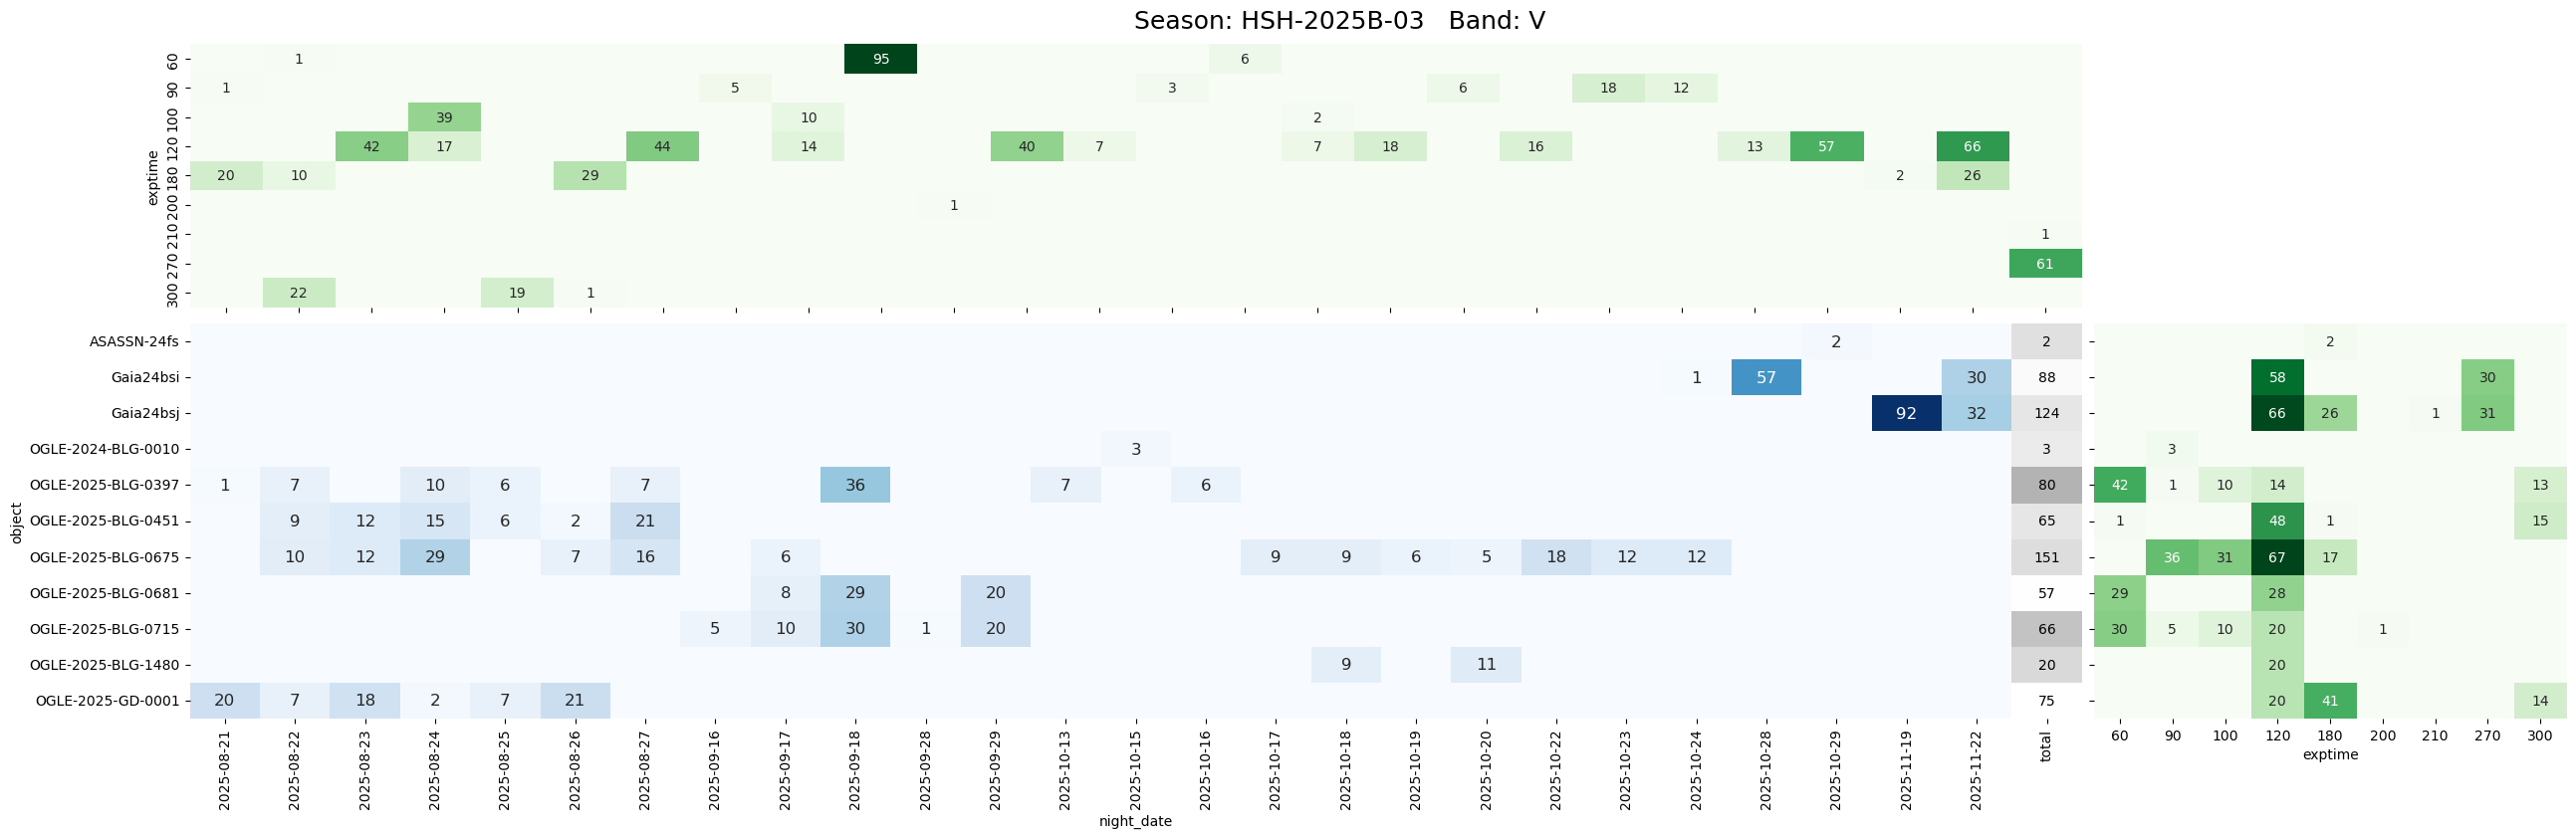

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


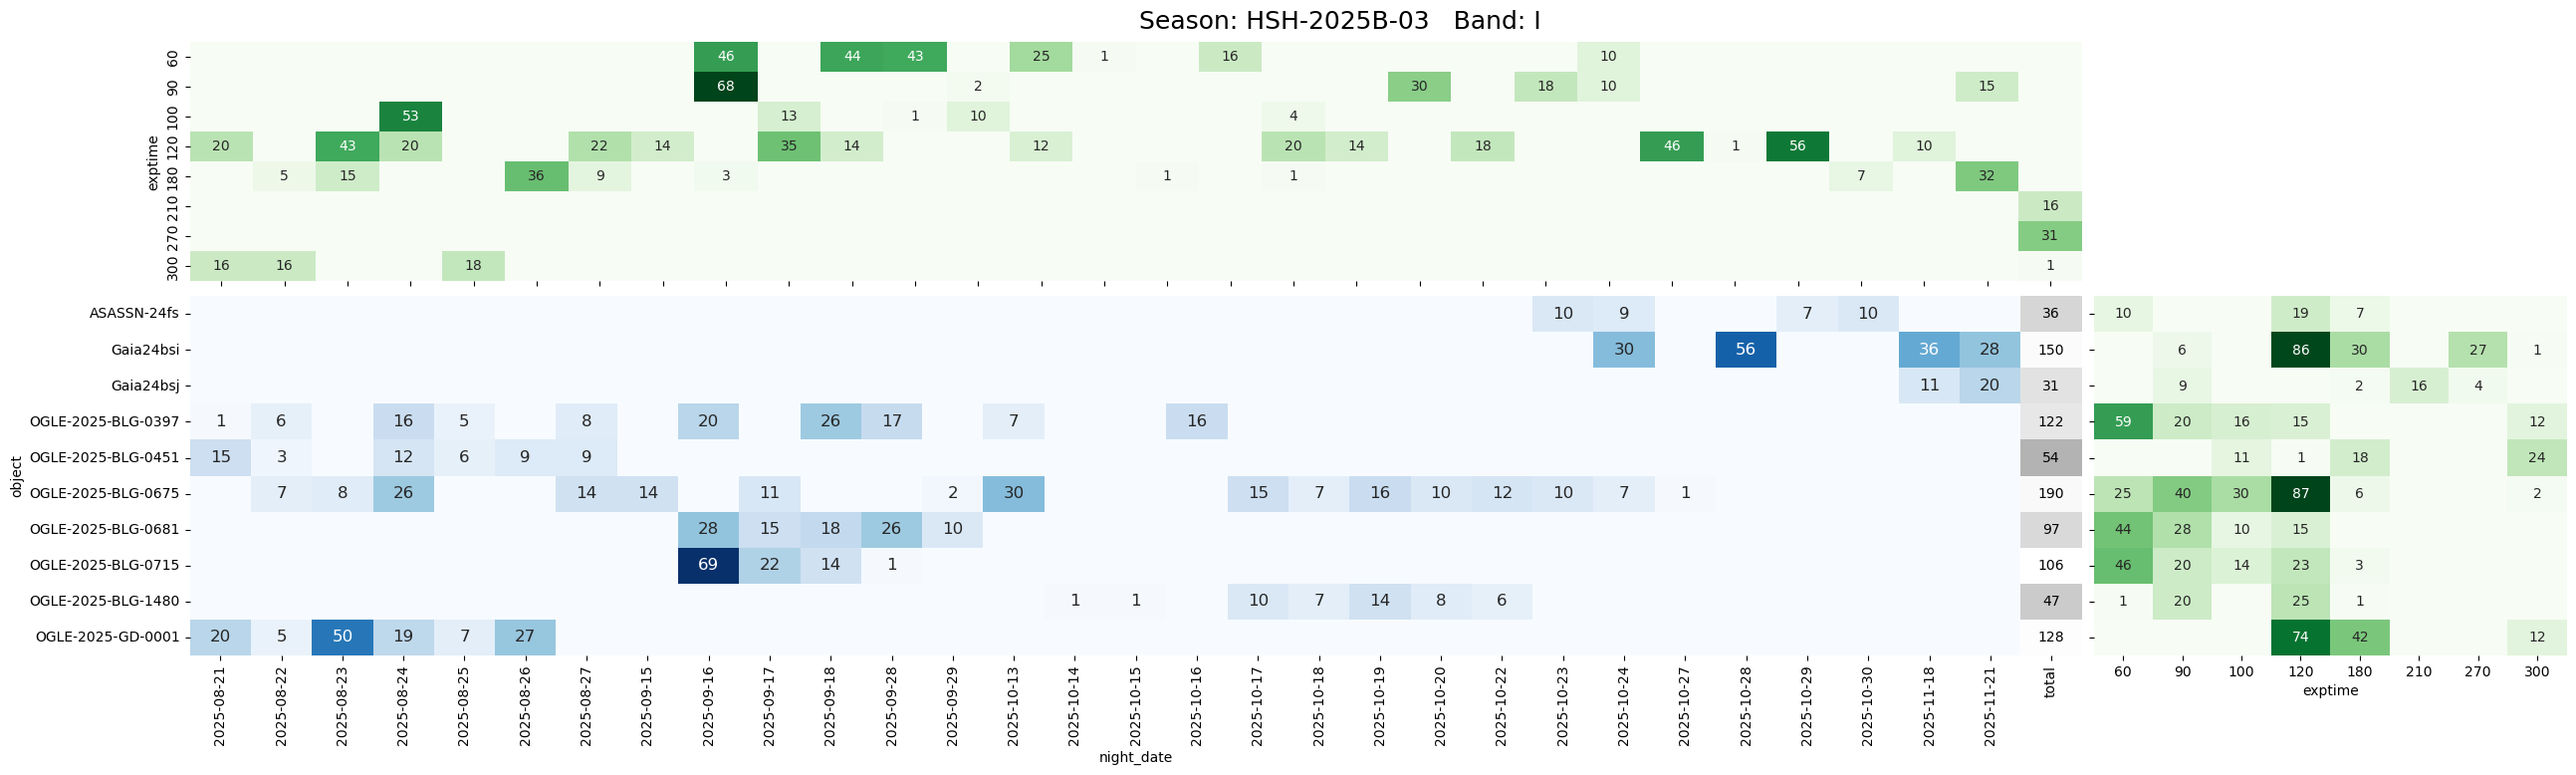

Plotting season: 2026A


/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


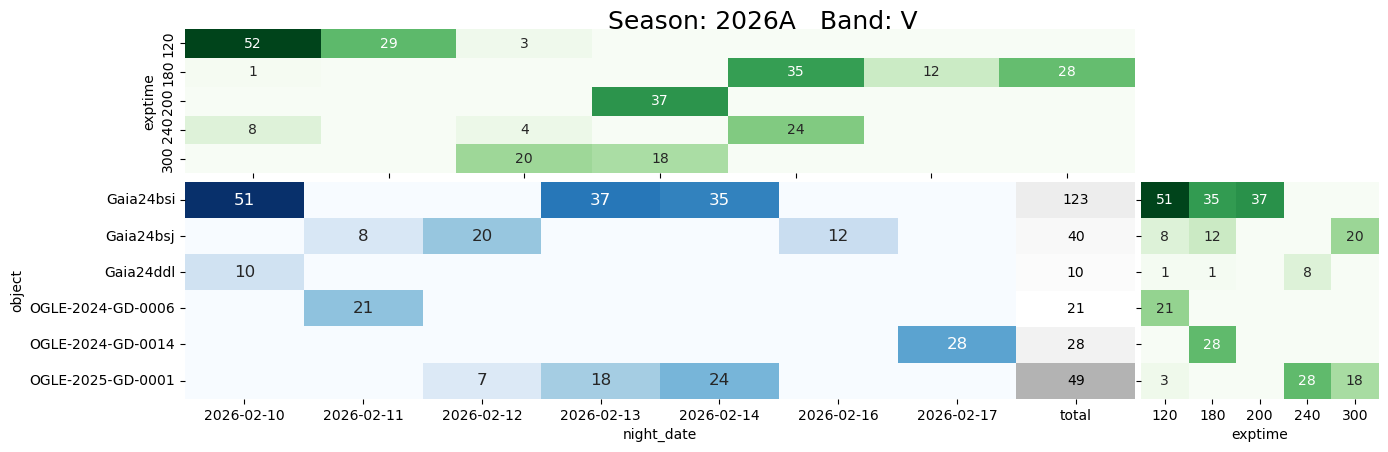

/tmp/ipykernel_12173/833180820.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_12173/833180820.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_12173/833180820.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


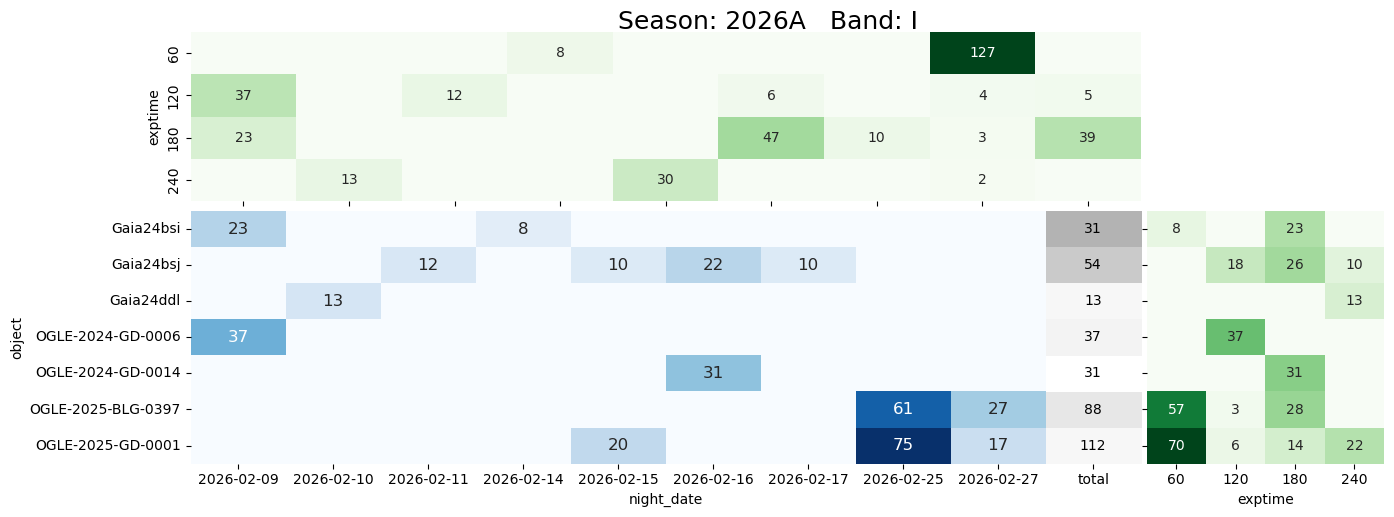

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar calendario de seasons
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons = seasons_df["season"].unique()

# Aseguramos tipos correctos
df["night"] = pd.to_datetime(df["night"])


df["exptime"] = pd.to_numeric(df["exptime"], errors='coerce').astype(int)

# Filtrar solo objetos válidos
df_objects = df[(df["imagetyp"]=="object") & (df["object"]!="NO_OBJECT")].copy()
# Convertir night a solo fecha
df_objects["night_date"] = df_objects["night"].dt.date

# Iterar por cada season
for season in seasons:
    print(f"Plotting season: {season}")
    
    # Fechas de la season
    season_dates = seasons_df.loc[seasons_df["season"]==season, "date"]
    n_nights = len(season_dates)
    
    for band in ["(3) V","(5) I"]:
    
        # Filtrar df_objects para esa season
        df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
        n_obj = len(df_season["object"].value_counts())
        
        
        if df_season.empty:
            print(f"No hay datos para la season {season}")
            continue
        
        # Matriz objeto × noche
        blue_matrix = (
            df_season.groupby(["object", "night_date"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index(axis=1)
        )
        blue_matrix["total"] = blue_matrix.sum(axis=1)
        
        top_green = (
            df_season.groupby(["exptime", "night_date"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index()
        )
        
        right_green = (
            df_season.groupby(["object", "exptime"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index(axis=1)
        )
        # Máscara para que "total" no reciba color de Blues
        mask_total = blue_matrix.columns.to_series().eq("total").to_numpy()  # 1D
        mask_total = np.tile(mask_total, (blue_matrix.shape[0], 1))           # 2D: filas x columnas
        annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
        annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
        annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")


        
        # Plot
        fig = plt.figure(figsize=(n_nights*0.55, n_obj*0.8))
        gs = fig.add_gridspec(
            2, 2,
            width_ratios=[4, 1],
            height_ratios=[2, 3],
            wspace=0.01,
            hspace=0.05
        )
        ax_top = fig.add_subplot(gs[0, 0])
        ax_main = fig.add_subplot(gs[1, 0])
        ax_right = fig.add_subplot(gs[1, 1])

        # Heatmap azul con columna "total" excluida de la escala
        sns.heatmap(
            blue_matrix,
            ax=ax_main,
            cmap="Blues",
            annot=annot_blue,
            fmt="",
            annot_kws={"size":12},
            cbar=False,
            mask=mask_total,   # Esta máscara deja "total" sin color
        )
        ax_main.imshow(
            blue_matrix[["total"]],
            cmap="Greys",
            alpha=0.3,
            aspect='auto',
            extent=[blue_matrix.shape[1]-1, blue_matrix.shape[1], 0, blue_matrix.shape[0]]
        )

        # Añadir los números manualmente
        for i, val in enumerate(blue_matrix["total"]):
            ax_main.text(
                blue_matrix.shape[1]-0.5,  # centro de la última columna
                i + 0.5,                    # centro de la fila
                int(val),
                ha='center',
                va='center'
            )


        # Heatmaps verdes
        sns.heatmap(top_green, ax=ax_top, cmap="Greens", annot=annot_top, fmt="", annot_kws={"size":10}, cbar=False)
        sns.heatmap(right_green, ax=ax_right, cmap="Greens", annot=annot_right, fmt="", annot_kws={"size":10}, cbar=False)

        band_str = band[-1]
        ax_top.set_xticklabels([])
        ax_top.set_xlabel("")
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
        plt.suptitle(f"Season: {season}   Band: {band_str}", fontsize=18, y=0.92)
        plt.tight_layout()  # Ajusta márgenes
        plt.savefig(f"season_{season}_band_{band_str}.png", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()  # cerrar la figura para liberar memoria



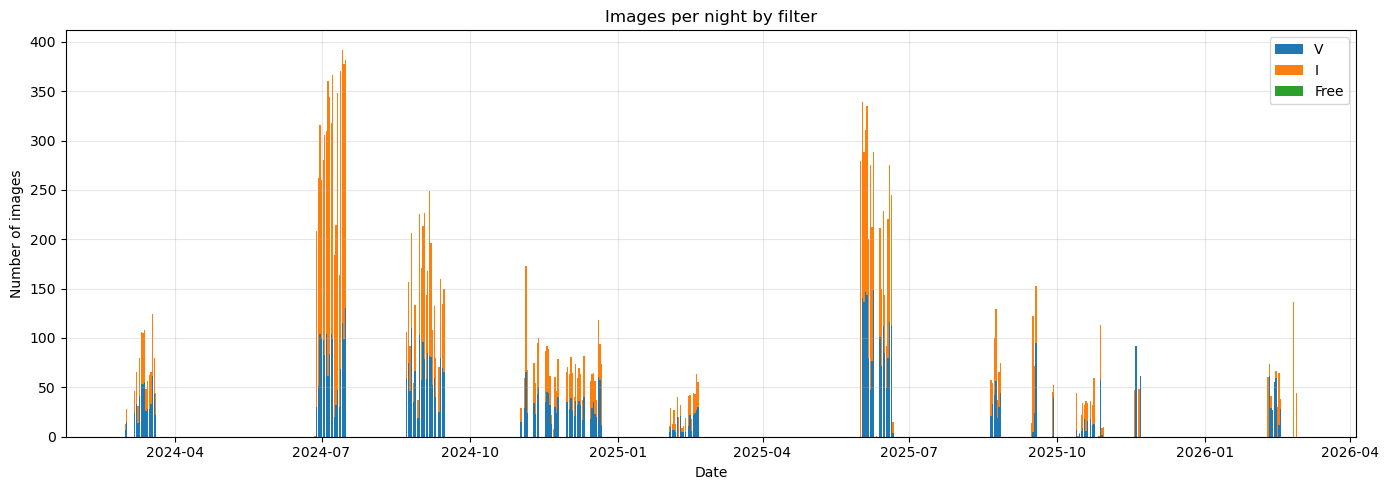

In [9]:

df_obj = df[df["imagetyp"]=="object"]
daily_counts = (
    df_obj.groupby(["night", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
daily_counts1 = (
    df_obj.groupby(["night", "wheel_aux"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(14,5))

x = daily_counts.index
v = daily_counts["(3) V"]
i = daily_counts["(5) I"]
f = daily_counts["(1) Free"]
#b = daily_counts["(2) B"]
#r = daily_counts["(4) R"]


plt.bar(x, v, label="V")
plt.bar(x, i, bottom=v, label="I") 
plt.bar(x, f, bottom=i, label="Free") 
#plt.bar(x, b, bottom=f, label="B") 
#plt.bar(x, r, bottom=b, label="R") 


plt.xlabel("Date")
plt.ylabel("Number of images")
plt.title("Images per night by filter")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



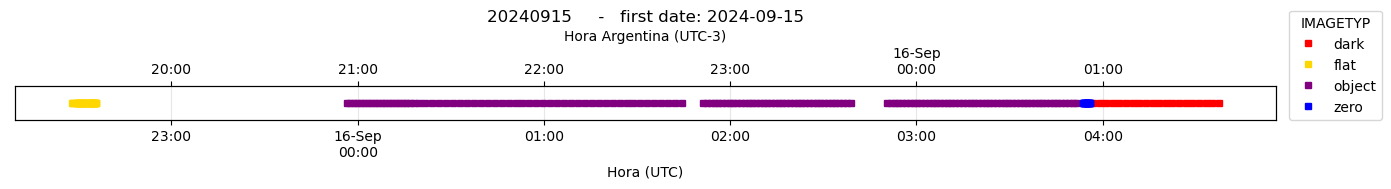

object
ASASSN-24fs          113
OGLE-2024-DG-0016     40
Name: count, dtype: int64


15302    Makler
15317    Makler
15297    Makler
15292    Makler
15301    Makler
          ...  
15224    Makler
15222    Makler
15223    Makler
15225    Makler
15220    Makler
Name: observer, Length: 232, dtype: object

In [42]:
df_obj = check_night(df, "20240915")
df_obj["observer"]

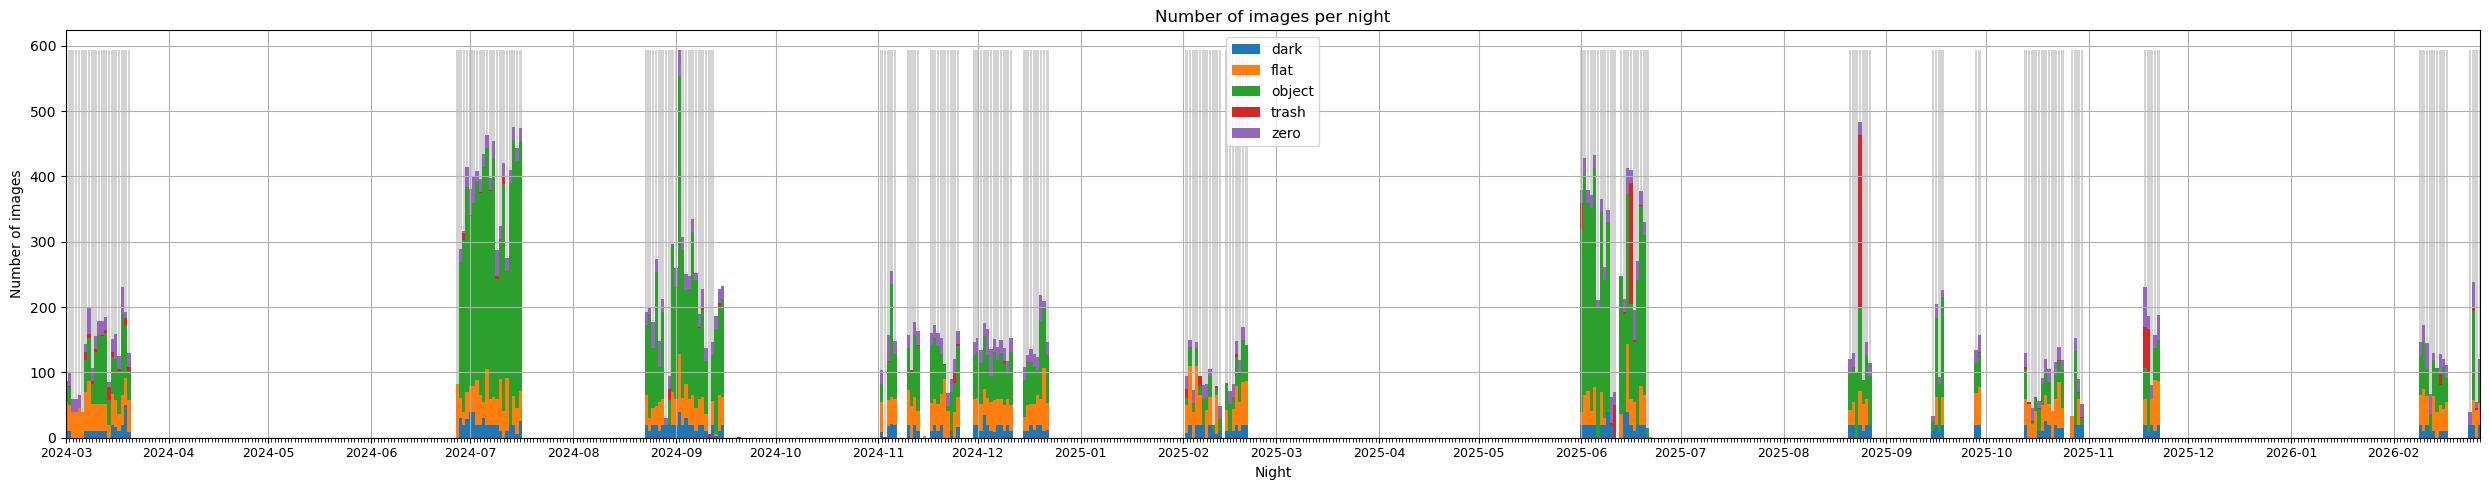

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['night'] = pd.to_datetime(df['night'])

imgs_per_night = (
    df.groupby('night')
      .size()
      .rename('n_images')
      .sort_index()
)
imgs_per_night.index = pd.to_datetime(imgs_per_night.index)

#imgs_per_night.index.to_numpy() = pd.to_datetime(imgs_per_night.index).to_numpy()
imgs_per_night = imgs_per_night.sort_index()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')


season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:red",
    "HSH-2026A-03": "tab:purple"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)


x = merged['date'].to_numpy()
y = merged['n_images'].to_numpy()
c = colors.to_numpy()



df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")

# 2️⃣ Tabla de conteos
counts = (
    df.groupby(["night", "imagetyp"])
       .size()
       .unstack(fill_value=0)
       .sort_index()
)

fig, ax = plt.subplots(figsize=(25,5))

y_max=max(y)
for xi in x:
    if xi in seasons_df["date"].values:
        plt.bar(xi, y_max, color="lightgray")
plt.bar(x, y, width=1.0, color=c)

bottom = None
for col in counts.columns:
    ax.bar(counts.index, counts[col], bottom=bottom, width=1, label=col)
    bottom = counts[col] if bottom is None else bottom + counts[col]

# Ahora SÍ es eje datetime real
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

ax.tick_params(axis='x', which='major', rotation=0, labelsize=9)
ax.tick_params(axis='x', which='minor', length=3)

ax.set_xlabel("Night")
ax.set_ylabel("Number of images")

plt.xlim(df["night"].min(), df["night"].max())

plt.title("Number of images per night")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



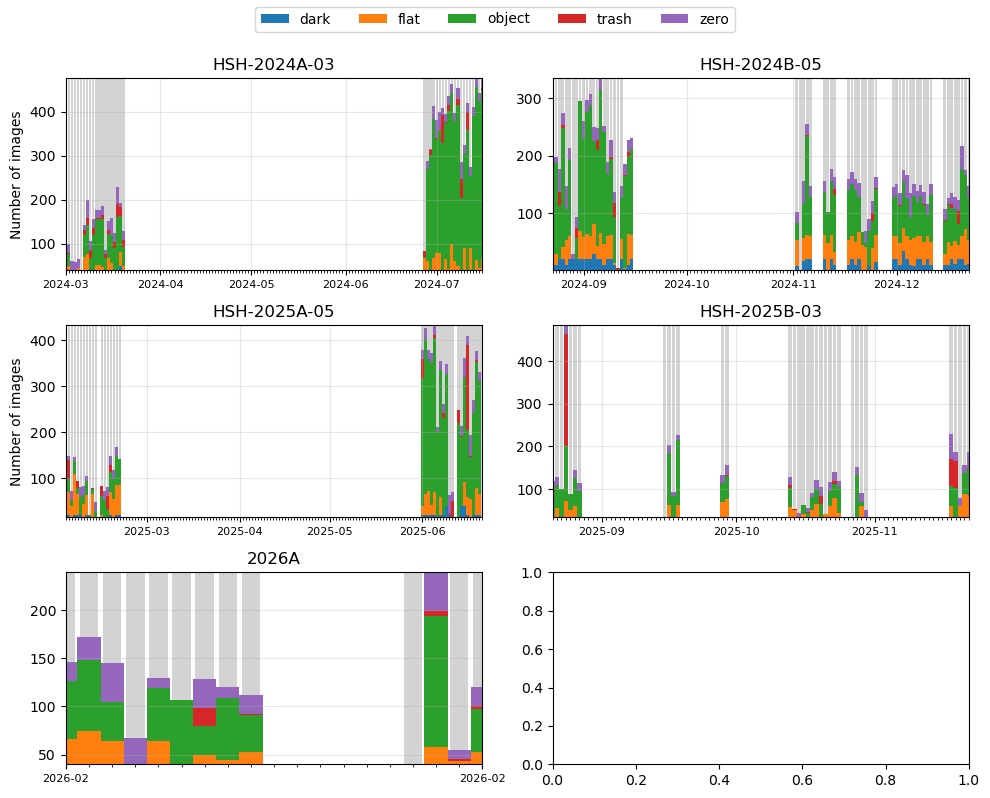

In [515]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates




# Asegúrate de que la fecha sea datetime
df['night'] = pd.to_datetime(df['night'])

# Conteo de imágenes por noche
imgs_per_night = (
    df.groupby('night')
      .size()
      .rename('n_images')
      .sort_index()
)
imgs_per_night.index = pd.to_datetime(imgs_per_night.index)

#imgs_per_night.index.to_numpy() = pd.to_datetime(imgs_per_night.index).to_numpy()
imgs_per_night = imgs_per_night.sort_index()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')


season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:red",
    "HSH-2026A-03": "tab:purple"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)



c = colors.to_numpy()



df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")

# 2️⃣ Tabla de conteos
counts = (
    df.groupby(["night", "imagetyp"])
       .size()
       .unstack(fill_value=0)
       .sort_index()
)


seasons = seasons_df.season.unique()
fig, axes = plt.subplots(3, 2, figsize=(10, 8))#, sharey=True)
axes = axes.flatten()

for ax, season in zip(axes, seasons):
    season_df= seasons_df[seasons_df["season"]==season]
    merged_season = merged[merged["season"]==season]
    if merged_season.empty:
        ax.set_title(f"{season} (no data)")
        continue
    x = merged_season['date'].to_numpy()
    y = merged_season['n_images'].to_numpy()
    y_max = max(y)
    for xi in x:
        if xi in season_df["date"].values:
            ax.bar(xi, y_max, color="lightgray")
    ax.bar(x, y, width=1.0, color=c)


    bottom = None
    for col in counts.columns:
        ax.bar(counts.index, counts[col], bottom=bottom, width=1, label=col)
        bottom = counts[col] if bottom is None else bottom + counts[col]
 
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.set_ylim(y.min(), y.max())
    ax.set_xlim(x.min(), x.max())

    ax.set_title(season)
    ax.grid(alpha=0.3)

# Etiquetas y leyenda
axes[0].set_ylabel("Number of images")
axes[2].set_ylabel("Number of images")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels))

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [147]:
df[(df["date-obs"]>"2025-12-01")]["date-obs"]

32334   2026-02-10
32335   2026-02-10
32336   2026-02-10
32337   2026-02-10
32338   2026-02-10
           ...    
33731   2026-02-28
33730   2026-02-28
33729   2026-02-28
33758   2026-02-28
33819   2026-02-28
Name: date-obs, Length: 1580, dtype: datetime64[ns]

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
def check_night(df, day):
    if not "-" in str(day):
        df_day = df[df["night"] == day].copy()
    else:
        df_day = df[df["date-obs"].dt.date == pd.to_datetime(day).date()].copy()
    dt_utc = pd.to_datetime(
        df_day["date-obs"].dt.strftime("%Y-%m-%d") + " " + df_day["time-obs"].astype(str),
        errors="coerce"
    )

    df_day["datetime"] = dt_utc  # guardar para poder plotear
    df_day["datetime_ar"] = df_day["datetime"] - pd.Timedelta(hours=3)
    def ar_hour_formatter(x, pos=None):
        dt_utc = mdates.num2date(x)              # valor original en UTC
        dt_ar = dt_utc - pd.Timedelta(hours=3)  # convertir a AR manualmente
        
        if dt_ar.hour == 0 and dt_ar.minute == 0:
            return dt_ar.strftime('%d-%b\n%H:%M')
        return dt_ar.strftime('%H:%M')



    df_day["imagetyp"] = df_day["imagetyp"].str.lower().str.strip()

    color_map = {
        "flat": "gold",
        "dark": "red",
        "zero": "blue",
        "object": "purple"
    }

    plt.figure(figsize=(14, 2))

    for typ, group in df_day.groupby("imagetyp"):   #  usar df_day
        plt.plot(
            group["datetime"].to_numpy(),   #  convertir a numpy
            np.ones(len(group)),            #  también numpy
            "s",
            label=typ,
            color=color_map.get(typ, "gray"),
            markersize=5
        )


    plt.gca().yaxis.set_visible(False)
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.xlabel("Hora (UTC)")
    first_day = df_day["datetime"].min().date()
    plt.title(f"{day}     -   first date: {first_day}")
    plt.grid(True, axis='x', alpha=0.3)

    plt.legend(title="IMAGETYP", loc=(1.01,0))

    import matplotlib.ticker as mticker

    def day_hour_formatter(x, pos=None):
        dt = mdates.num2date(x)
        
        # Si es medianoche, mostramos fecha + hora
        if dt.hour == 0 and dt.minute == 0:
            return dt.strftime('%d-%b\n%H:%M')  # salto de línea
        else:
            return dt.strftime('%H:%M')

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(day_hour_formatter))
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(ar_hour_formatter))
    ax2.set_xlabel("Hora Argentina (UTC-3)")


    plt.tight_layout()
    plt.show()
    print(df_day.object.value_counts())
    return df_day

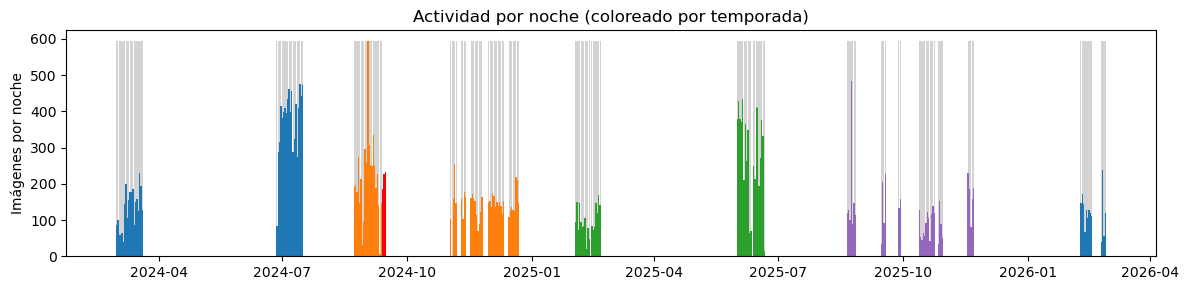

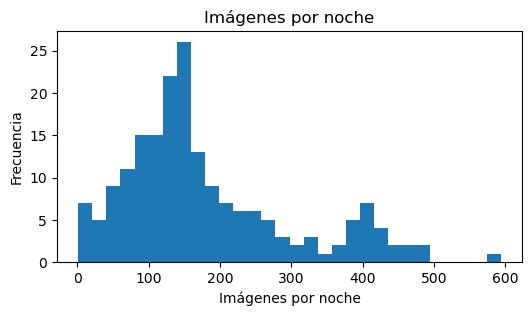

In [32]:
import matplotlib.pyplot as plt

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')

import matplotlib.pyplot as plt

season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:purple",
    "2026A": "tab:blue"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)


x = merged['date'].to_numpy()
y = merged['n_images'].to_numpy()
c = colors.to_numpy()

plt.figure(figsize=(12,3))
y_max=max(y)
for xi in x:
    if xi in seasons_df["date"].values:
        plt.bar(xi, y_max, color="lightgray")
plt.bar(x, y, width=1.0, color=c)


plt.ylabel('Imágenes por noche')
plt.title('Actividad por noche (coloreado por temporada)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(imgs_per_night.values, bins=30)
plt.xlabel('Imágenes por noche')
plt.ylabel('Frecuencia')
plt.title('Imágenes por noche')
plt.show()



In [93]:
red_nights = merged[merged["season"].isna()].copy()

print(len(red_nights))
red_nights

20


,date,n_images,season
20,2024-03-21,129,NaN
41,2024-07-17,351,NaN
62,2024-09-13,114,NaN
63,2024-09-14,212,NaN
64,2024-09-15,244,NaN
65,2024-09-16,186,NaN
66,2024-09-21,1,NaN
71,2024-11-07,108,NaN
76,2024-11-14,132,NaN
77,2024-11-15,2,NaN


In [ ]:
seasons_df[seasons_df["date"]=="2024-03-21"]

,season,date,program
19,HSH-2024A-03,2024-03-20,HSH


### Análisis por objeto

In [ ]:
# Plots de curvas de luz con días observados sombreados.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from datetime import timedelta
import os
for obj in [folder for folder in os.listdir("../data/objetos") if not ".csv" in folder] :
    target_folder = "../data/objetos/"+obj
    photo_file = [file for file in os.listdir(target_folder) if "photometry" in file][0]
    mop_lc = pd.read_csv(target_folder+ "/"+ photo_file)
    mop_lc=mop_lc[mop_lc["Filter"].isin(["OGLE_I", "G", "i(GaiaSP)", "V(GaiaSP)"])]
    mop_lc['Timestamp'] = pd.to_datetime(mop_lc['Timestamp'])
    mop_lc['Magnitude'] = pd.to_numeric(mop_lc['Magnitude'], errors='coerce')
    mop_lc['Error'] = pd.to_numeric(mop_lc['Error'], errors='coerce')


    counts_series = (
        df[df["object"] == obj]
        .groupby(df["date-obs"].dt.date)
        .size()
        .sort_index()
    )

    dates = counts_series.index
    counts = counts_series.values
    if len(counts)==0:
        print(f"No images for object {obj}")
        continue


    fig, ax = plt.subplots(figsize=(10,4))

    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    cmap = plt.get_cmap("viridis_r")

    for date, value in zip(dates, counts):
        ax.axvspan(
            date,
            date + timedelta(days=1),
            color=cmap(norm(value)),
            alpha=0.6
        )
    filters = mop_lc["Filter"].unique()
    for filt in filters:
        lc_filt = mop_lc[mop_lc["Filter"]==filt]
        ax.plot(lc_filt["Timestamp"], lc_filt["Magnitude"], "o", ms=2, label = filt)
    #print(mop_lc["Filter"].value_counts())

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Number of images")

    ax.set_xlim(df["date-obs"].min() - timedelta(days=60),
                df["date-obs"].max() + timedelta(days=5))
    #ax.set_ylim(0, 1)

    ax.set_title(f"{obj} light curve (Total images = {sum(counts)})")
    

    #print(mop_lc["Filter"].value_counts())
    plt.gca().invert_yaxis()
    plt.legend()
    # Fecha en formato AAAAMMDD (uso la fecha mínima de observación del objeto)
    date_str = df[df["object"] == obj]["date-obs"].max().strftime("%Y%m%d")

    filename = f"{obj}_lc_{date_str}.png"
    filepath = os.path.join("../plots", filename)

    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)
 
#plt.legend(loc=(1.01,0), ncols=4)

No images for object OGLE-2025-DG-0010
No images for object OGLE-2024-BLG-0675
No images for object OGLE-2024-DG-0006
No images for object OGLE-2025-BLG-0303
No images for object OGLE-2025-BLG-0901
No images for object OGLE-2025-BLG-0075
No images for object OGLE-2025-DG-0019
No images for object OGLE-2024-GD-0009
No images for object OGLE-2025-BLG-1457


In [26]:
import pandas as pd


df["night"] = pd.to_datetime(df["night"]).dt.normalize()
#seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
#seasons_df["date"] = seasons_df["date"].dt.normalize()

table_images = (
    df
    .groupby(["season", "object"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Total por objeto (fila)
table_images["Images"] = table_images.sum(axis=1)

# Total por temporada (fila final)
total_row = table_images.sum(axis=0)
total_row.name = "Images"

table_images = pd.concat([table_images, total_row.to_frame().T]).T
table_images

,2026A,HSH-2024A-03,HSH-2024B-05,HSH-2025A-05,HSH-2025B-03,Images
object,,,,,,
ASASSN-24fs,0,0,112,0,54,166
Altair,0,0,0,0,3,3
Gaia23cnu,0,188,0,0,0,188
Gaia23dpn,0,28,0,0,0,28
Gaia24bsi,154,0,1451,0,242,1847
Gaia24bsj,97,0,1156,0,220,1473
Gaia24ddl,23,0,0,233,0,256
M83,0,12,0,0,0,12
NGC0092,0,0,1,0,0,1


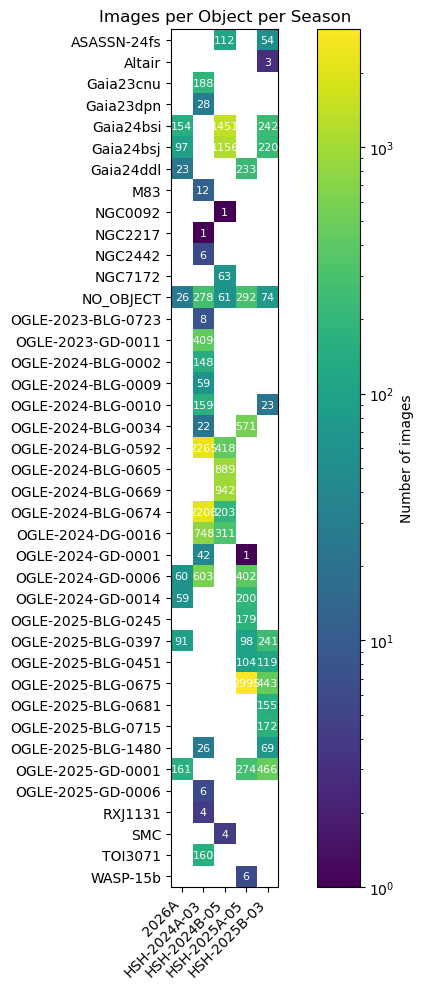

In [27]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Separar totales
heatmap_data = table_images.drop(index="Images").drop(columns="Images")

fig, ax = plt.subplots(figsize=(8,10))

#im = ax.imshow(heatmap_data.values, cmap="viridis")
norm = mcolors.LogNorm(
    vmin=max(1, heatmap_data.values.min()),
    vmax=heatmap_data.values.max()
)

im = ax.imshow(heatmap_data.values, cmap="viridis", norm=norm)

# Etiquetas
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_data.index)

# Anotar valores
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j, i,
            heatmap_data.iloc[i, j],
            ha="center", va="center",
            fontsize=8,
            color="white"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of images")

ax.set_title("Images per Object per Season")
plt.tight_layout()
plt.show()

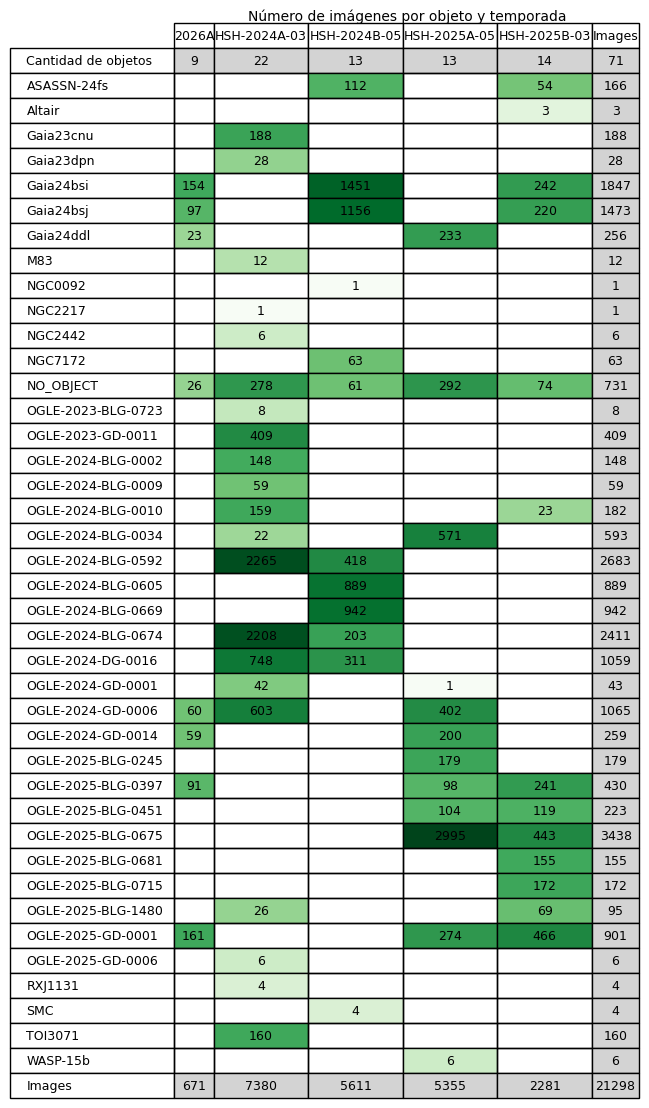

In [ ]:
import pandas as pd

# 1️⃣ Calcular cantidad de objetos por temporada
# Solo consideramos las columnas de temporadas, no Images
season_cols = [c for c in table_images.columns if c != "Images"]

obj_count_row = (table_images[season_cols] > 0).sum(axis=0)  # número de objetos con al menos 1 imagen por temporada
obj_count_row["Images"] = sum(obj_count_row)  # podemos dejar vacío o poner el total general de objetos

# Convertir en DataFrame de 1 fila con mismo índice
obj_count_row_df = pd.DataFrame([obj_count_row], index=["Cantidad de objetos"])
# 2️⃣ Concatenar fila arriba de la tabla original
table_with_count = pd.concat([obj_count_row_df, table])
# Asumimos que 'table' es la tabla final con TOTAl fila y columna
data = table_with_count.values
rows = table_with_count.index.astype(str).tolist()
cols = table_with_count.columns.astype(str).tolist()

fig, ax = plt.subplots(figsize=(6, max(4, len(rows)*0.25+1)))
ax.axis('off')  # ocultar ejes
from matplotlib.colors import LogNorm

# Evitar ceros porque log(0) no existe
image_data = table_with_count.drop("Images", axis=1).drop("Images", axis=0)
image_data_nonzero = image_data.replace(0, np.nan)  # ceros se pintarán blancos

norm = LogNorm(vmin=image_data_nonzero.min().min(), vmax=image_data_nonzero.max().max())
cmap = plt.get_cmap("Greens")

# Dibujar celdas coloreadas
cell_text = []
cell_colors = []
for r_idx, row in enumerate(data):
    row_text = []
    row_colors = []
    for c_idx, val in enumerate(row):
        if str(val)!="0":
            row_text.append(str(val))
        else:
            row_text.append("")
        # Colorear solo celdas que no sean totales
        if (rows[r_idx] != "Images") and (cols[c_idx] != "Images") and ((rows[r_idx] != "Cantidad de objetos") ):
            color = cmap(norm(val))
        else:
            color = "lightgray"  # gris claro para totales
        row_colors.append(color)
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Crear tabla
the_table = ax.table(
    cellText=cell_text,
    rowLabels=rows,
    colLabels=cols,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center'
)

all_cols_text = []
for col_idx in range(len(cols)):
    col_text = [cols[col_idx]]  # header
    for row_idx in range(len(rows)):
        col_text.append(cell_text[row_idx][col_idx])
    all_cols_text.append(col_text)
# Calcular ancho proporcional
col_widths = []
for col in all_cols_text:
    max_len = max(len(str(x)) for x in col)
    col_widths.append(max_len)
# Normalizar (ajustá el factor si querés más espacio)
total = sum(col_widths)
col_widths = [w / total for w in col_widths]
# Aplicar a la tabla
for col_idx, width in enumerate(col_widths):
    for row_idx in range(len(rows)+1):  # +1 incluye header
        the_table[(row_idx, col_idx)].set_width(width)
the_table.auto_set_font_size(False)
the_table.set_fontsize(9)
the_table.scale(1, 1.5)  # ancho x alto de las celdas
plt.title("Número de imágenes por objeto y temporada", fontsize=10, y=1.1)
plt.show()

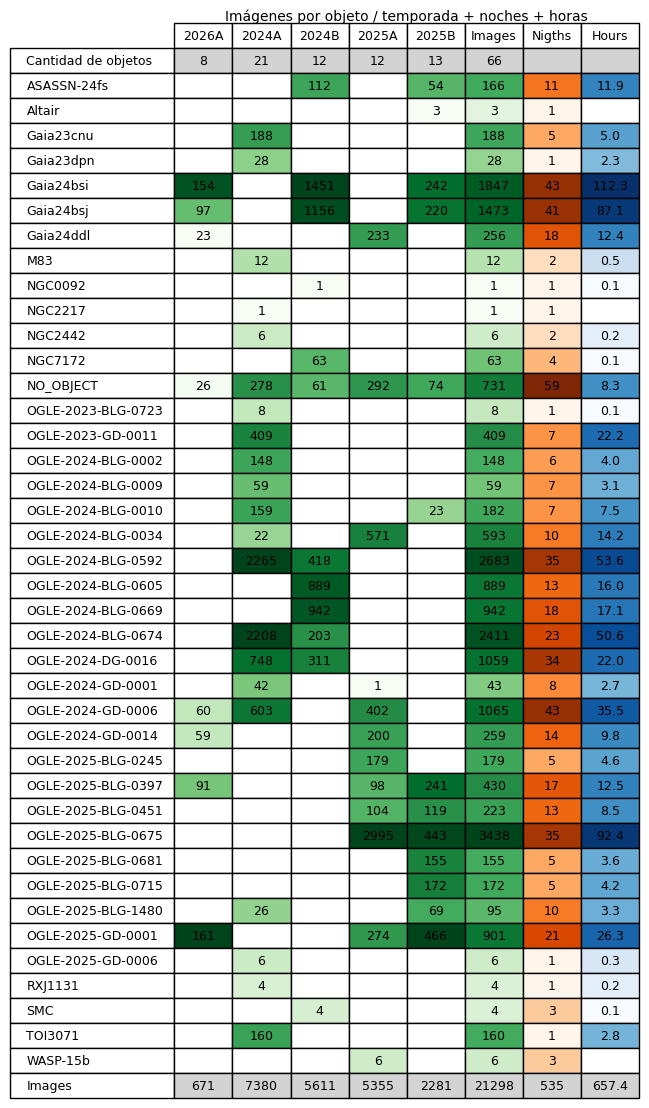

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df["night"] = pd.to_datetime(df["night"]).dt.normalize()
tab = pd.crosstab(df["object"], df["season"])


# métricas extra
tab["Images"]  = tab.sum(1)
tab["Nigths"] = df.groupby("object")["night"].nunique()
tab["Hours"]  = (df.groupby("object")["exptime"].sum()/3600).round(1)

# fila Images
tot = tab.sum(0); tot.name = "Images"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nigths","Hours"]]
cnt = (tab.loc[tab.index!="Images", sc]>0).sum(0)
cnt["Images"] = cnt.sum(); cnt["Nigths"]=np.nan; cnt["Hours"]=np.nan
tab = pd.concat([pd.DataFrame([cnt], index=["Cantidad de objetos"]), tab])
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
    "2026A": "2026A",   
}
tab = tab.rename(columns=rename_map)
# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (v==0 or pd.isna(v)) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        if r not in ["Images","Cantidad de objetos"] and pd.notna(v):
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Images","Cantidad de objetos"]))]
            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)
                cmap = plt.get_cmap("Blues" if c=="Hours" else "Oranges" if c=="Nigths" else "Greens")
                rc.append(cmap(norm(v)) if v>0 else (1,1,1,1))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append("lightgray")

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1,1.5)

plt.title("Imágenes por objeto / temporada + noches + horas", fontsize=10, y=1.1)
plt.show()

/tmp/ipykernel_12173/3448642651.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tab = pd.concat([tab, extra])


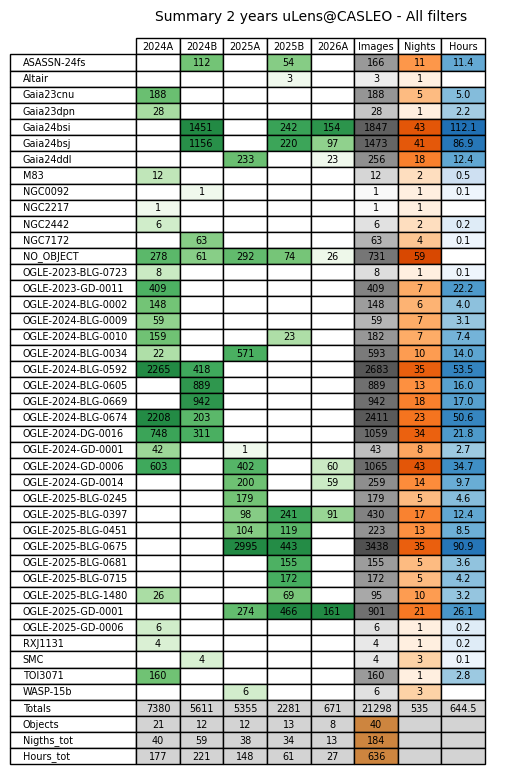

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df.copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - All filters", fontsize=10, y=1.0)
plt.show()

/tmp/ipykernel_12173/3448642651.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tab = pd.concat([tab, extra])


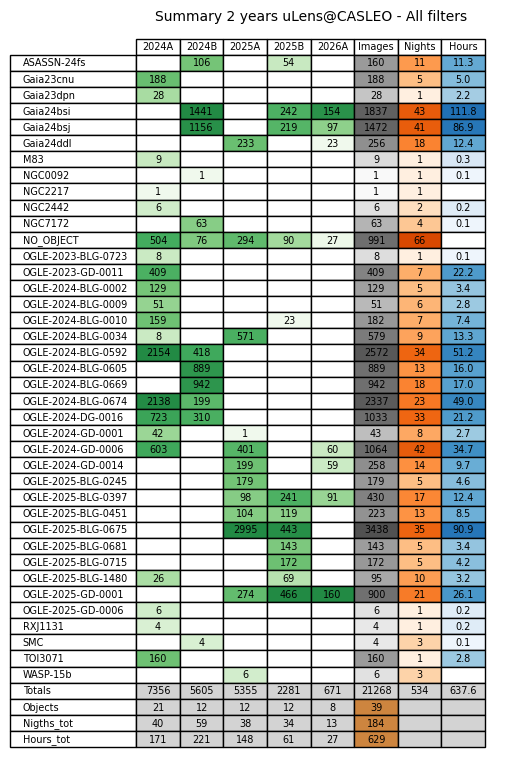

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df.copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - All filters", fontsize=10, y=1.0)
plt.show()

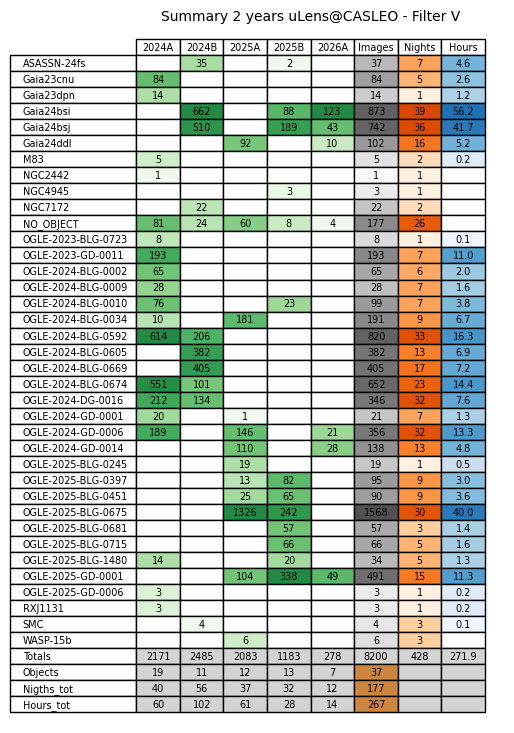

In [597]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[df["WHEEL"]=="(3) V"].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter V", fontsize=10, y=1.0)
plt.show()

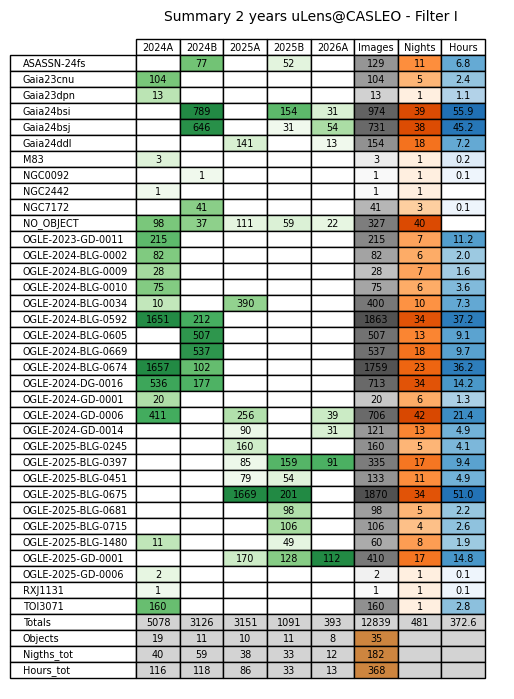

In [596]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[df["WHEEL"]=="(5) I"].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter I", fontsize=10, y=1.0)
plt.show()

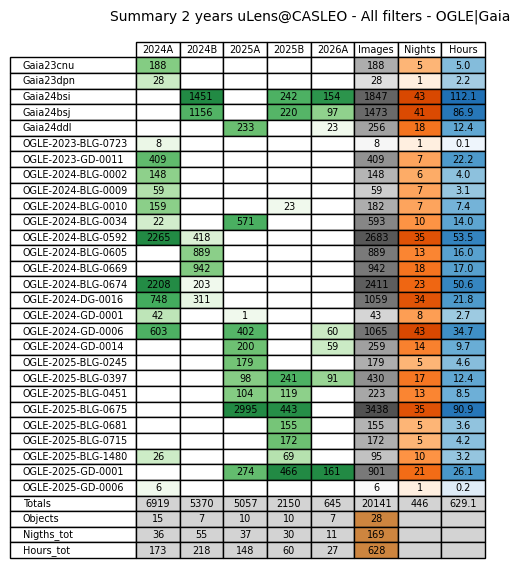

In [600]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[df["object"].str.startswith("Gaia") | df["object"].str.startswith("OGLE") ].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - All filters - OGLE|Gaia", fontsize=10, y=1.0)
plt.show()

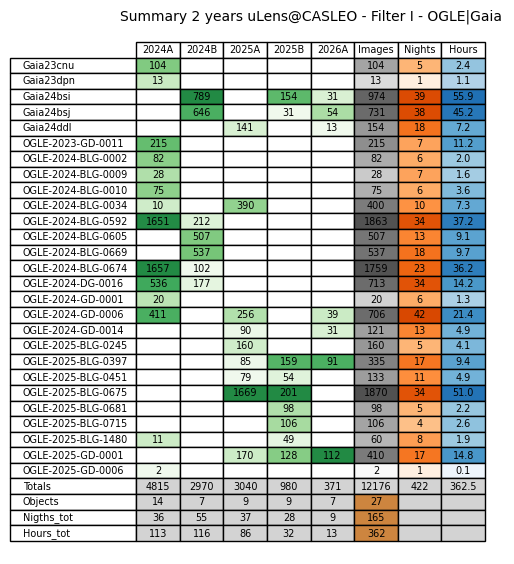

In [601]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[(df["object"].str.startswith("Gaia") | df["object"].str.startswith("OGLE"))& (df["WHEEL"]=="(5) I")].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter I - OGLE|Gaia", fontsize=10, y=1.0)
plt.show()

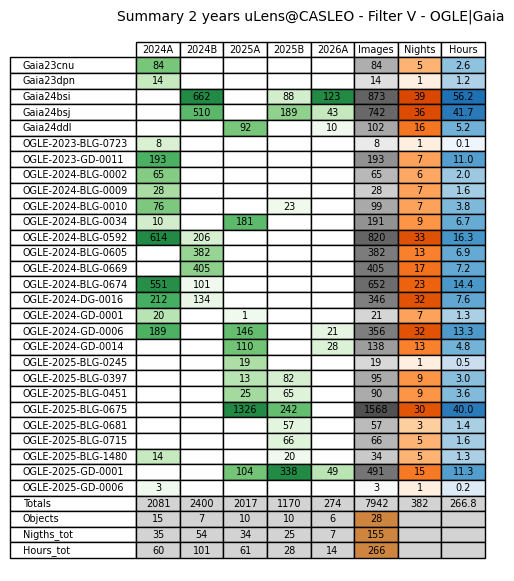

In [602]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize


df_season = df[(df["object"].str.startswith("Gaia") | df["object"].str.startswith("OGLE"))& (df["WHEEL"]=="(3) V")].copy()

tab = pd.crosstab(df_season["object"], df_season["season"])

tab["Images"] = tab.sum(1)
tab["Nights"] = df_season.groupby("object")["night"].nunique()
tab["Hours"]  = (df_season[df_season["imagetyp"]=="object"]
                 .groupby("object")["exptime"].sum()/3600).round(1)

# fila totals
tot = tab.sum(0); tot.name = "Totals"
tab = pd.concat([tab, tot.to_frame().T])

# fila cantidad objetos
sc = [c for c in tab.columns if c not in ["Images","Nights","Hours"]]
cnt = (tab.loc[tab.index!="Totals", sc]>0).sum(0)
cnt["Images"] = len(tab.index)-1
cnt["Nights"] = np.nan
cnt["Hours"]  = np.nan
tab = pd.concat([tab, pd.DataFrame([cnt], index=["Objects"])])

# --- filas extra por temporada ---
season_cols = sc

extra = pd.DataFrame(index=["Nigths_tot","Hours_tot"], columns=tab.columns)

extra.loc["Nigths_tot", season_cols] = df_season.groupby("season")["night"].nunique()
extra.loc["Hours_tot", season_cols]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600)
extra.loc["Nigths_tot", "Images"] = df_season.groupby("season")["night"].nunique().sum()
extra.loc["Hours_tot", "Images"]  = (df_season[df_season["imagetyp"]=="object"]
                                       .groupby("season")["exptime"].sum()/3600).sum()

tab = pd.concat([tab, extra])

# rename columnas
rename_map = {
    "HSH-2024A-03": "2024A",
    "HSH-2024B-05": "2024B",
    "HSH-2025A-05": "2025A",
    "HSH-2025B-03": "2025B",
}
tab = tab.rename(columns=lambda c: rename_map.get(c, c))
import re

def season_key(c):
    m = re.match(r"(\d{4})([AB])", str(c))
    if m:
        year = int(m.group(1))
        sem  = 0 if m.group(2)=="A" else 1
        return (year, sem)
    return (9999, 9)  # para TOTAL, Images, etc.

season_cols = sorted(
    [c for c in tab.columns if re.match(r"\d{4}[AB]", str(c))],
    key=season_key
)

other_cols = [c for c in tab.columns if c not in season_cols]

tab = tab[season_cols + other_cols]

# --- PLOT ---
rows, cols = tab.index.astype(str), tab.columns.astype(str)
fig, ax = plt.subplots(figsize=(6, max(4,len(rows)*0.25+1)))
ax.axis("off")

cell_text, cell_colors = [], []

for i,r in enumerate(rows):
    rt, rc = [], []
    for j,c in enumerate(cols):
        v = tab.iloc[i,j]

        rt.append("" if (pd.isna(v) or v==0) else (f"{v:.1f}" if c=="Hours" else str(int(v))))

        # celda especial
        if r in ["Objects","Nigths_tot", "Hours_tot"] and c=="Images":
            rc.append("peru")
            continue

        # totales y filas extra
        if r in ["Totals","Objects","Nigths_tot","Hours_tot"]:
            rc.append("lightgray")
            continue

        # coloreo normal
        if pd.notna(v) and v>0:
            colv = tab[c]
            valid = colv[(colv>0)&(~tab.index.isin(["Totals","Objects","Nigths_tot","Hours_tot"]))]

            if len(valid):
                vmin,vmax = valid.min(), valid.max()
                norm = LogNorm(vmin=vmin, vmax=vmax) if vmax/max(vmin,1e-6)>20 else Normalize(vmin=vmin,vmax=vmax)

                if c=="Images":
                    cmap = plt.get_cmap("Greys")
                elif c=="Hours":
                    cmap = plt.get_cmap("Blues")
                elif c=="Nights":
                    cmap = plt.get_cmap("Oranges")
                else:
                    cmap = plt.get_cmap("Greens")

                t = norm(v)
                t =  0.05+0.7 * t   # comprime rango → evita blancos y negros extremos
                rc.append(cmap(t))
            else:
                rc.append((1,1,1,1))
        else:
            rc.append((1,1,1,1))

    cell_text.append(rt); cell_colors.append(rc)

tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
               cellColours=cell_colors, loc="center", cellLoc="center")

tbl.auto_set_font_size(False)
tbl.set_fontsize(7)   # antes 9
tbl.scale(0.9, 1.2)  # achica ancho y alto de celdas
fig.set_size_inches(5, max(3, len(rows)*0.22))

plt.title("Summary 2 years uLens@CASLEO - Filter V - OGLE|Gaia", fontsize=10, y=1.0)
plt.show()

### Noches otorgadas y no otorgadas

In [111]:
obs_nights = set(df["night"].unique())
season_nights = set(seasons_df["date"].unique())

extra_nights = sorted(obs_nights - season_nights)

non_ot = pd.DataFrame({"night_outside_season": extra_nights})
non_ot.to_csv("non_season_nights_with_science.csv", index=False)
non_ot

,night_outside_season
0,2024-09-13
1,2024-09-14
2,2024-09-15
3,2024-09-20
4,2024-11-15
5,2025-06-22


In [117]:
for n in non_ot["night_outside_season"].values:
    print(n)
    print(df[df["night"]==n].object.value_counts())
    print()

2024-09-13T00:00:00.000000000
object
ASASSN-24fs    162
Name: count, dtype: int64

2024-09-14T00:00:00.000000000
object
ASASSN-24fs          126
OGLE-2024-DG-0016      9
NO_OBJECT              8
Name: count, dtype: int64

2024-09-15T00:00:00.000000000
object
ASASSN-24fs          113
OGLE-2024-DG-0016     40
Name: count, dtype: int64

2024-09-20T00:00:00.000000000
object
NO_OBJECT    1
Name: count, dtype: int64

2024-11-15T00:00:00.000000000
object
NO_OBJECT    2
Name: count, dtype: int64

2025-06-22T00:00:00.000000000
object
NO_OBJECT    1
Name: count, dtype: int64



In [40]:
seasons_df
df.season.value_counts()

season
HSH-2024A-03    10173
HSH-2024B-05     9624
HSH-2025A-05     7513
HSH-2025B-03     4281
2026A            1580
Name: count, dtype: int64

In [257]:
science_nights = set(
    pd.to_datetime(
        df[df["imagetyp"] == "object"]["night"]
    ).dt.date
)

season_nights = set(
    pd.to_datetime(seasons_df["date"]).dt.date
)
missing_science = sorted(season_nights - science_nights)
season_map = dict(
    zip(
        pd.to_datetime(seasons_df["date"]).dt.date,
        seasons_df["season"]
    )
)

missing_science_seasons = [season_map.get(night) for night in missing_science]
reason = [None] * len(missing_science)
labels = ["aprendiendo", "aprendiendo", "aprendiendo", "aprendiendo", "mal tiempo", "problemas técnicos", 
          "corte de luz en Burek", "se observó según el log", "qué pasó? (init season)", "problemas técnicos", "mal tiempo",
          "qué pasó? (init season)"]+["incendio en Burek"]*9 + ["mal tiempo",
        "mal tiempo", "problemas técnicos", "mal tiempo", "se observó según el log",
        "se observó según el log", "se observó según el log", 
        "sin targets"]+["sin targets"]*6+["mal tiempo", "no se observó", "se observó según el log"]

for i in range(min(len(labels), len(reason))):
    reason[i] = labels[i]
    
non_obs = {"season":missing_science_seasons, "date": missing_science, "reason": reason}
# 25/12/17 ; 25/12/18 ; 2025-12-20
non_obs = pd.DataFrame(non_obs)   
non_obs.to_csv("season_nights_without_science.csv", index=False)
non_obs

,season,date,reason
0,HSH-2024A-03,2024-03-03,aprendiendo
1,HSH-2024A-03,2024-03-04,aprendiendo
2,HSH-2024A-03,2024-03-05,aprendiendo
3,HSH-2024A-03,2024-03-06,aprendiendo
4,HSH-2024B-05,2024-08-29,mal tiempo
5,HSH-2024B-05,2024-09-11,problemas técnicos
6,HSH-2024B-05,2024-11-03,corte de luz en Burek
7,HSH-2024B-05,2024-12-23,se observó según el log
8,HSH-2025A-05,2025-02-01,qué pasó? (init season)
9,HSH-2025A-05,2025-06-10,problemas técnicos


In [258]:
non_obs.groupby(["reason"]).size()

reason
aprendiendo                4
corte de luz en Burek      1
incendio en Burek          9
mal tiempo                 6
no se observó              1
problemas técnicos         3
qué pasó? (init season)    2
se observó según el log    5
sin targets                7
dtype: int64

In [100]:
df[df["night"].isin(missing_science)].drop_duplicates("night")["season"].values

/tmp/ipykernel_12173/1172538409.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df[df["night"].isin(missing_science)].drop_duplicates("night")["season"].values


array(['HSH-2024A-03', 'HSH-2024A-03', 'HSH-2024A-03', 'HSH-2024A-03',
       'HSH-2024B-05', 'HSH-2024B-05', 'HSH-2024B-05', 'HSH-2025A-05',
       'HSH-2025B-03', 'HSH-2025B-03', '2026A', '2026A'], dtype=object)

In [92]:
non_obs[non_obs["reason"]=="se observó según el log"]

,season_without_science,reason
7,2024-12-23,se observó según el log
25,2025-12-17,se observó según el log
26,2025-12-18,se observó según el log
27,2025-12-19,se observó según el log
37,2026-02-28,se observó según el log


In [89]:
df[df["night"]=="20251216"][["file", "file_old", "night", "imagetyp"]].imagetyp.value_counts()

Series([], Name: count, dtype: int64)

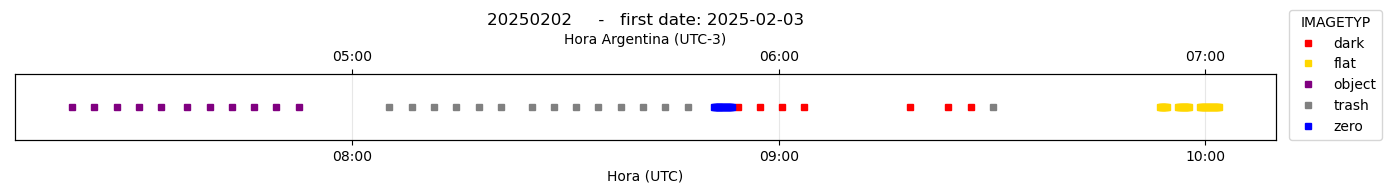

object
NO_OBJECT    14
Gaia24ddl    11
Name: count, dtype: int64


In [132]:
dfobj = check_night(df, "20250202")